<a href="https://colab.research.google.com/github/ravithreni02/AI-ML-INTERNSHIP/blob/main/agrigenie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive')

rm: cannot remove '/content/drive/Shareddrives': Operation canceled
rm: cannot remove '/content/drive/.shortcut-targets-by-id': Operation canceled
rm: cannot remove '/content/drive/MyDrive': Operation canceled
rm: cannot remove '/content/drive/.Trash-0': Directory not empty
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Cell 1 of every session — always run this FIRST, before anything else
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
PROJECT_DIR = "/content/drive/MyDrive/AgriGenie"
os.makedirs(f"{PROJECT_DIR}/data", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/models", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/outputs", exist_ok=True)
print("Ready:", PROJECT_DIR)

Mounted at /content/drive
Ready: /content/drive/MyDrive/AgriGenie


### Create and Save `crop_benchmarks_MASTER.csv`

This cell ensures that the `crop_benchmarks_MASTER.csv` file, which aggregates various crop-specific benchmarks like yield, water requirements, prices, and costs, is created and saved to your Google Drive. This file is crucial for the `multi_objective_recommend` function.

If the file already exists, it will be loaded; otherwise, it will be generated from raw data sources.

In [9]:
import pandas as pd
import numpy as np
import os

benchmarks_master_path = f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv"

if not os.path.exists(benchmarks_master_path):
    print(f"'{benchmarks_master_path}' not found. Creating it...")

    # 1. Initial crop benchmarks (from Gs2eSu5mJDVN)
    crop_benchmarks = {
        "rice":        [4.0, 1200, 20, 45000, 25, 200],
        "maize":       [3.0, 500,  18, 30000, 24, 90],
        "chickpea":    [1.2, 350,  55, 25000, 22, 65],
        "kidneybeans": [1.5, 400,  60, 28000, 20, 90],
        "pigeonpeas":  [1.0, 450,  70, 26000, 26, 150],
        "mothbeans":   [0.7, 300,  55, 18000, 28, 55],
        "mungbean":    [0.8, 350,  70, 20000, 27, 60],
        "blackgram":   [0.8, 350,  65, 20000, 27, 65],
        "lentil":      [1.0, 300,  60, 22000, 20, 45],
        "pomegranate": [10.0, 800, 80, 150000, 22, 60],
        "banana":      [35.0, 1800, 15, 180000, 26, 110],
        "mango":       [8.0, 900,  40, 90000, 27, 90],
        "grapes":      [18.0, 700, 45, 200000, 20, 70],
        "watermelon":  [25.0, 500, 8,  60000, 25, 45],
        "muskmelon":   [15.0, 450, 12, 55000, 26, 30],
        "apple":       [15.0, 1000, 60, 120000, 12, 110],
        "orange":      [12.0, 900, 25, 85000, 22, 110],
        "papaya":      [40.0, 1000, 12, 70000, 26, 140],
        "coconut":     [8.0,  1300, 20, 60000, 27, 150],
        "cotton":      [1.8, 700,  60, 40000, 26, 80],
        "jute":        [2.5, 1200, 40, 35000, 25, 170],
        "coffee":      [1.0, 1500, 250, 100000, 24, 180],
    }

    bench_df = pd.DataFrame.from_dict(
        crop_benchmarks, orient="index",
        columns=["avg_yield_t_ha", "water_req_mm", "price_per_kg_inr",
                 "cost_cultivation_inr_ha", "ideal_temp_c", "ideal_rainfall_mm"]
    ).reset_index().rename(columns={"index": "label"})

    # 2. Merge with Agmarknet historical prices (from CBSUJSrsF1EB, aN3WRxuqHlkd, Zax88A1VIWLk, 3_Kl3AdJIaOo)
    price_df = pd.read_csv("/content/agmarknet_india_historical_prices_2024_2025.csv")
    price_summary = price_df.groupby("Commodity")["Modal Price (Rs./Quintal)"].mean().reset_index()
    price_summary["price_per_kg_inr"] = (price_summary["Modal Price (Rs./Quintal)"] / 100).round(2)
    name_mapping = {
        "Maize": "maize", "Arhar (Tur/Red Gram)(Whole)": "pigeonpeas", "Banana": "banana",
        "Mango": "mango", "Cotton": "cotton", "Green Gram (Moong)(Whole)": "mungbean",
        "Lentil (Masur)(Whole)": "lentil", "Apple": "apple",
    }
    price_summary["label"] = price_summary["Commodity"].map(name_mapping)
    matched_df = price_summary.dropna(subset=["label"])[["label", "price_per_kg_inr"]]
    matched_df["price_data_year"] = "2024-2025 avg"
    matched_df["price_source"] = "Agmarknet historical dataset (Oct 2024 - Aug 2025), CC BY-SA 4.0"

    bench_df = bench_df.drop(columns=["price_per_kg_inr"], errors="ignore")
    bench_df = bench_df.merge(matched_df, on="label", how="left")
    bench_df["price_source"] = bench_df["price_source"].fillna("estimated_placeholder")

    # 3. Merge with India Agriculture Crop Production yield data (from Bj58ej89JwA-, 2M-8SHrzXJS_)
    yield_df = pd.read_csv(f"/content/India Agriculture Crop Production.csv")
    yield_df = yield_df.dropna(subset=["Crop", "Yield"])
    yield_name_mapping = {
        "Rice": "rice", "Maize": "maize", "Arhar/Tur": "pigeonpeas",
        "Banana": "banana", "Coconut": "coconut", "Cotton(lint)": "cotton",
        "Gram": "chickpea", "Jute": "jute", "Moong(Green Gram)": "mungbean",
        "Urad": "blackgram", "Masoor": "lentil",
    }
    yield_df["label"] = yield_df["Crop"].map(yield_name_mapping)
    matched_yield = yield_df.dropna(subset=["label"])
    yield_summary = matched_yield.groupby("label")["Yield"].mean().reset_index()
    yield_summary.columns = ["label", "avg_yield_t_ha_real"]
    yield_summary["yield_source"] = "India Agriculture Crop Production dataset (1997-2020 avg)"

    yield_df2 = pd.read_csv(f"/content/crop_yield.csv") # from elQajxGnW0Ia
    moth_row = yield_df2[yield_df2["Crop"].str.strip() == "Moth"]
    moth_avg_yield = moth_row["Yield"].mean() if not moth_row.empty else 0.7 # Default if not found

    bench_df = bench_df.merge(yield_summary, on="label", how="left")
    bench_df["avg_yield_t_ha"] = bench_df["avg_yield_t_ha_real"].fillna(bench_df["avg_yield_t_ha"])
    bench_df["yield_source"] = bench_df["yield_source"].fillna("estimated_placeholder")

    # Quick fix: don't trust the real value for coconut, keep the placeholder instead (from TxFNEHA4Z8oy)
    bench_df.loc[bench_df["label"] == "coconut", "avg_yield_t_ha"] = 8.0  # revert to placeholder
    bench_df.loc[bench_df["label"] == "coconut", "yield_source"] = "estimated_placeholder (unit mismatch in source: nuts/ha, not tonnes/ha)"

    bench_df.loc[bench_df["label"] == "mothbeans", "avg_yield_t_ha"] = round(moth_avg_yield, 3)
    bench_df.loc[bench_df["label"] == "mothbeans", "yield_source"] = "crop_yield.csv dataset (real, 1997-2020 avg)"

    # 4. Merge with water footprint data (from OSW4KKqKYz0A, ixEUttolZ1mU)
    wf_df = pd.read_csv(f"/content/national_wf_all_crops_1990_2019.csv")
    india_wf = wf_df[wf_df["country_name"] == "India"]
    recent_wf = india_wf[india_wf["year"] >= 2015]  # use recent years only
    wf_name_mapping = {
        "Maize (corn)": "maize", "Rice": "rice", "Seed cotton, unginned": "cotton",
        "Chick peas, dry": "chickpea", "Pigeon peas, dry": "pigeonpeas",
        "Lentils, dry": "lentil", "Grapes": "grapes", "Coffee, green": "coffee",
        "Coconuts, in shell": "coconut", "Bananas": "banana", "Apples": "apple",
        "Oranges": "orange", "Watermelons": "watermelon", "Papayas": "papaya",
        "Mangoes, guavas and mangosteens": "mango", "Jute, raw or retted": "jute",
        "Beans, dry": "kidneybeans",
    }
    recent_wf["label"] = recent_wf["crop_name"].map(wf_name_mapping)
    matched_wf = recent_wf.dropna(subset=["label"])
    wf_summary = matched_wf.groupby("label").agg(
        wf_m3_per_t=("wf_tot_m3_t", "mean"),
        yield_t_ha=("crop_yield_t_ha", "mean")
    ).reset_index()
    wf_summary["water_req_mm_real"] = (wf_summary["wf_m3_per_t"] * wf_summary["yield_t_ha"] / 10).round(1)
    wf_summary["water_source"] = "FAO/WaterFootprint national dataset (India, 2015-2019 avg)"

    bench_df = bench_df.merge(wf_summary[["label","water_req_mm_real","water_source"]], on="label", how="left")
    bench_df["water_req_mm"] = bench_df["water_req_mm_real"].fillna(bench_df["water_req_mm"])
    bench_df["water_source"] = bench_df["water_source"].fillna("estimated_placeholder")

    # 5. Merge with cultivation cost data (from IuG5mXOEZCaj, ixEUttolZ1mU)
    cost1 = pd.read_csv(f"/content/culti_cost.csv")
    cost1_avg = cost1.filter(like="C2 - 2013-14").mean(axis=1)
    cost1_clean = pd.DataFrame({"Crop": cost1["Crop"], "cost_inr_ha": cost1_avg}).groupby("Crop").mean().reset_index()
    cost_name_mapping = {"Paddy": "rice", "Maize": "maize", "Gram": "chickpea",
                          "Arhar": "pigeonpeas", "Cotton": "cotton", "Moong": "mungbean"}
    cost1_clean["label"] = cost1_clean["Crop"].map(cost_name_mapping)
    matched_cost = cost1_clean.dropna(subset=["label"])[["label", "cost_inr_ha"]]
    matched_cost["cost_source"] = "CACP cultivation cost data (2013-14)"

    bench_df = bench_df.merge(matched_cost.rename(columns={"cost_inr_ha":"cost_inr_ha_real"}), on="label", how="left")
    bench_df["cost_cultivation_inr_ha"] = bench_df["cost_inr_ha_real"].fillna(bench_df["cost_cultivation_inr_ha"])
    bench_df["cost_source"] = bench_df["cost_source"].fillna("estimated_placeholder")

    # 6. Fill remaining NaN prices with placeholders (from Q5tyyvHAarLz)
    placeholder_prices = {
        "rice": 20, "chickpea": 55, "kidneybeans": 60, "mothbeans": 55,
        "blackgram": 65, "pomegranate": 80, "grapes": 45, "watermelon": 8,
        "muskmelon": 12, "orange": 25, "papaya": 12, "coconut": 20,
        "jute": 40, "coffee": 250,
    }
    for crop, price in placeholder_prices.items():
        mask = (bench_df["label"] == crop) & (bench_df["price_per_kg_inr"].isna())
        bench_df.loc[mask, "price_per_kg_inr"] = price

    # 7. Update fruit yields (from 6pArnVlDa8fq)
    fruit_yield_updates = {
        "apple": 6.01, "orange": 12.72, "grapes": 26.28,
        "mango": 8.49, "papaya": 38.46, "pomegranate": 10.79,
    }
    for crop, real_yield in fruit_yield_updates.items():
        mask = bench_df["label"] == crop
        bench_df.loc[mask, "avg_yield_t_ha"] = real_yield
        bench_df.loc[mask, "yield_source"] = "Indian Horticulture Database / National Horticulture Board (2014-15)"

    # 8. Update prices from new crop price data (from qiNhB5ngF4-f, c96a2774, VyMfPKKNM8U6)
    price_df_new = pd.read_csv(f"/content/crop price data.csv")
    price_new_name_mapping = {
        "Apple": "apple", "Banana": "banana", "Black Gram(Urd Beans)(Whole)": "blackgram",
        "Bengal Gram Dal(Chana Dal)": "chickpea", "Tender Coconut": "coconut",
        "Coffee": "coffee", "Cotton": "cotton", "Grapes": "grapes", "Jute": "jute",
        "Lentil(Masur)(Whole)": "lentil", "Maize": "maize", "Mango": "mango",
        "Mataki": "mothbeans", "Green Gram Dal(Moong Dal)": "mungbean",
        "Karbuja(Musk Melon)": "muskmelon", "Orange": "orange", "Papaya": "papaya",
        "Red gram/Arhar/Tur(whole)": "pigeonpeas", "Pomegranate": "pomegranate",
        "Rice": "rice", "Water Melon": "watermelon",
    }
    price_df_new["label"] = price_df_new["Commodity"].map(price_new_name_mapping)
    matched_new_prices = price_df_new.dropna(subset=["label"])
    price_summary_new = matched_new_prices.groupby("label")["Modal Price 01-07-2025 to 01-07-2026"].mean().reset_index()
    price_summary_new["price_per_kg_inr"] = (price_summary_new["Modal Price 01-07-2025 to 01-07-2026"] / 100).round(2)
    price_summary_new["price_source"] = "data.gov.in Commodity Price/Arrival Report (Jul 2025 - Jul 2026)"
    price_summary_new = price_summary_new[["label", "price_per_kg_inr", "price_source"]]

    bench_df = bench_df.merge(price_summary_new, on="label", how="left", suffixes=("_old", ""))
    bench_df["price_per_kg_inr"] = bench_df["price_per_kg_inr"].fillna(bench_df["price_per_kg_inr_old"])
    bench_df["price_source"] = bench_df["price_source"].fillna(bench_df["price_source_old"])
    bench_df = bench_df.drop(columns=["price_per_kg_inr_old", "price_source_old"], errors='ignore')

    # 9. Update costs from new CACP data (from Seirz4ooQwN8, 04f3b67e, gGbZjObpRbFo, IPIjom5yRgg3)
    cacp_df = pd.read_csv(f"/content/Cost of Cultivation_Sample_Data.csv")
    cacp_name_mapping = {
        "Paddy": "rice", "Maize": "maize", "Gram": "chickpea",
        "Tur (Arhar)": "pigeonpeas", "Urad": "blackgram", "Moong": "mungbean",
        "Lentil": "lentil", "Masur": "lentil",
        "Cotton": "cotton", "Jute": "jute",
    }
    cacp_df["label"] = cacp_df["Crop Name (crop_name)"].map(cacp_name_mapping)
    matched_cacp = cacp_df.dropna(subset=["label"])
    cacp_summary = matched_cacp.groupby("label")["Cultivation Cost A1 (cul_cost_a1)"].mean().reset_index()
    cacp_summary.columns = ["label", "cost_inr_ha_cacp"]
    cacp_summary["cost_source_cacp"] = "CACP unit-level cost of cultivation microdata (multi-year avg)"

    hort_costs = {"watermelon": 50000, "muskmelon": 56000, "banana": 56000,}
    hort_df = pd.DataFrame([{"label": k, "cost_inr_ha_cacp": v, "cost_source_cacp": "Horticultural crops cost table (field prep+nursery+weeding+plant protection+fertilizer+wages)"} for k, v in hort_costs.items()])
    cacp_summary = pd.concat([cacp_summary, hort_df], ignore_index=True)

    bench_df = bench_df.merge(cacp_summary, on="label", how="left")
    bench_df["cost_cultivation_inr_ha"] = bench_df["cost_inr_ha_cacp"].fillna(bench_df["cost_cultivation_inr_ha"])
    bench_df["cost_source"] = bench_df["cost_source_cacp"].fillna(bench_df["cost_source"])
    bench_df = bench_df.drop(columns=["cost_inr_ha_cacp", "cost_source_cacp"], errors='ignore')

    # 10. Final adjustments for jute and coconut (from 7Eq9sGwVrmr4)
    bench_df.loc[bench_df["label"] == "jute", "avg_yield_t_ha"] *= 0.27
    bench_df.loc[bench_df["label"] == "jute", "yield_source"] += " (adjusted: raw stalk yield -> fiber-equivalent, 27% extraction ratio)"
    bench_df.loc[bench_df["label"] == "coconut", "price_per_kg_inr"] = 20
    bench_df.loc[bench_df["label"] == "coconut", "price_source"] = "estimated_placeholder (real source was Tender Coconut - priced per piece, incompatible with tonnage yield)"

    bench_df.to_csv(benchmarks_master_path, index=False)
    print(f"'{benchmarks_master_path}' created successfully.")
else:
    print(f"'{benchmarks_master_path}' already exists. Loading existing file.")

# Load the bench_df (guaranteed to exist now)
bench_df = pd.read_csv(benchmarks_master_path)


'/content/drive/MyDrive/AgriGenie/data/crop_benchmarks_MASTER.csv' not found. Creating it...
'/content/drive/MyDrive/AgriGenie/data/crop_benchmarks_MASTER.csv' created successfully.


/tmp/ipykernel_2844/2727380357.py:103: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recent_wf["label"] = recent_wf["crop_name"].map(wf_name_mapping)


### Re-initialize `multi_objective_recommend` dependencies

The `crop_benchmarks_MASTER.csv` file has now been successfully created. The `TypeError` previously encountered indicates that the `multi_objective_recommend` function was defined in a state where this file (or other assets) could not be loaded. This cell will re-execute the comprehensive setup cell (`d1bca0d1`) to ensure that all models, scalers, label encoders, and the `bench_df` (which includes data from `crop_benchmarks_MASTER.csv`) are correctly loaded and the `multi_objective_recommend` function is properly initialized for subsequent use.

### Saving raw datasets to Google Drive for persistence

This step ensures that all the raw dataframes loaded or fetched during this notebook run are saved to your Google Drive. This way, you won't need to re-download or re-fetch them in future sessions, saving time and API calls.

In [6]:
import pandas as pd

# Load dataframes if they are not already defined
# (Assuming PROJECT_DIR is already defined from a previous cell)

# For df (from cell fMpHyaHi-YDu)
url = "https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Recommendation%20dataset.csv"
df = pd.read_csv(url)

# For price_df (from cell CBSUJSrsF1EB)
price_df = pd.read_csv("/content/agmarknet_india_historical_prices_2024_2025.csv")

# For nasa_df (from cell j23lgI2bYaTP) - initializing to None to avoid complex dependency duplication
nasa_df = None

# For wf_df (from cell OSW4KKqKYz0A)
wf_df = pd.read_csv(f"/content/national_wf_all_crops_1990_2019.csv")

# For yield_df (from cell Bj58ej89JwA-)
yield_df = pd.read_csv(f"/content/India Agriculture Crop Production.csv")

# For yield_df2 (from cell elQajxGnW0Ia)
yield_df2 = pd.read_csv(f"/content/crop_yield.csv")

# For cost1 (from cell IuG5mXOEZCaj)
cost1 = pd.read_csv(f"/content/culti_cost.csv")

# Original code to save dataframes
df.to_csv(f"{PROJECT_DIR}/data/crop_recommendation_raw.csv", index=False)
print("Saved crop_recommendation_raw.csv")

price_df.to_csv(f"{PROJECT_DIR}/data/agmarknet_historical_prices_raw.csv", index=False)
print("Saved agmarknet_historical_prices_raw.csv")

if nasa_df is not None:
    nasa_df.to_csv(f"{PROJECT_DIR}/data/nasa_power_data_raw.csv", index=False)
    print("Saved nasa_power_data_raw.csv")

wf_df.to_csv(f"{PROJECT_DIR}/data/national_wf_all_crops_raw.csv", index=False)
print("Saved national_wf_all_crops_raw.csv")

yield_df.to_csv(f"{PROJECT_DIR}/data/india_agriculture_crop_production_raw.csv", index=False)
print("Saved india_agriculture_crop_production_raw.csv")

yield_df2.to_csv(f"{PROJECT_DIR}/data/crop_yield_raw.csv", index=False)
print("Saved crop_yield_raw.csv")

cost1.to_csv(f"{PROJECT_DIR}/data/culti_cost_raw.csv", index=False)
print("Saved culti_cost_raw.csv")

Saved crop_recommendation_raw.csv
Saved agmarknet_historical_prices_raw.csv
Saved national_wf_all_crops_raw.csv
Saved india_agriculture_crop_production_raw.csv
Saved crop_yield_raw.csv
Saved culti_cost_raw.csv


In [10]:
import os
path = f"{PROJECT_DIR}/data/crop_benchmarks.csv"
print("Exists:", os.path.exists(path))

Exists: False


In [11]:
!pip install xgboost lightgbm shap -q

In [12]:
import pandas as pd

url = "https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Recommendation%20dataset.csv"
df = pd.read_csv(url)
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [13]:
print(df.shape)                 # should print (2200, 8)
print(df.isnull().sum())        # should be all 0
print(df['label'].value_counts())  # should show 22 crops, 100 rows each
df.describe()

(2200, 8)
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [14]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
TARGET = "label"

X = df[FEATURES]
y_raw = df[TARGET].values

le = LabelEncoder()
y = le.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(X_train_s.shape, X_test_s.shape)

(1760, 7) (440, 7)


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_s, y_train)
preds = rf.predict(X_test_s)

print("Accuracy:", accuracy_score(y_test, preds))
print("F1 macro:", f1_score(y_test, preds, average="macro"))

Accuracy: 0.9954545454545455
F1 macro: 0.9954517027687758


In [16]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
TARGET = "label"

X = df[FEATURES]
y_raw = df[TARGET].values

le = LabelEncoder()
y = le.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(X_train_s.shape, X_test_s.shape)

(1760, 7) (440, 7)


In [17]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier # Added this import
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, eval_metric="mlogloss", random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=300, random_state=42, verbose=-1),
}

results = []
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    results.append({"model": name, "accuracy": round(acc*100, 2), "f1_macro": round(f1*100, 2)})
    print(f"{name:20s} | Acc: {acc*100:.2f}% | F1: {f1*100:.2f}%")

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
results_df

LogisticRegression   | Acc: 97.27% | F1: 97.25%
KNN                  | Acc: 97.95% | F1: 97.93%
DecisionTree         | Acc: 97.95% | F1: 97.94%
RandomForest         | Acc: 99.55% | F1: 99.55%
SVM                  | Acc: 98.41% | F1: 98.40%
XGBoost              | Acc: 98.86% | F1: 98.86%
LightGBM             | Acc: 98.86% | F1: 98.86%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,f1_macro
3,RandomForest,99.55,99.55
5,XGBoost,98.86,98.86
6,LightGBM,98.86,98.86
4,SVM,98.41,98.40
2,DecisionTree,97.95,97.94
1,KNN,97.95,97.93
0,LogisticRegression,97.27,97.25


In [18]:
import joblib
import os

# Ensure the models directory exists
os.makedirs(f"{PROJECT_DIR}/models", exist_ok=True)

best_model = models["RandomForest"]
joblib.dump(best_model, f"{PROJECT_DIR}/models/best_model_RandomForest.joblib")
joblib.dump(scaler, f"{PROJECT_DIR}/models/scaler.joblib")
joblib.dump(le, f"{PROJECT_DIR}/models/label_encoder.joblib")

print("Saved models to PROJECT_DIR/models/")

Saved models to PROJECT_DIR/models/


In [19]:
import shap
import numpy as np
import pandas as pd
import requests
import os
import joblib

# Ensure PROJECT_DIR is defined
PROJECT_DIR = "/content/drive/MyDrive/AgriGenie"

# Ensure the data directory exists
os.makedirs(f"{PROJECT_DIR}/data", exist_ok=True)

# Define district_name_mapping (copy from app.py / waYJYZhJ7_ul)
district_name_mapping = {
    'ahilyanagar': 'ahmednagar',
    'ahmedabad': 'ahmadabad',
    'alluri sitharama raju': 'visakhapatnam',
    'ananthapuramu': 'anantapur',
    'annamayya': 'chittoor',
    'arvalli': 'aravallis',
    'bandipora': 'bandipore',
    'dangs': 'the dangs',
    'east singhbum': 'east singhbhum',
    'hanumangarh': 'hanumangarh',
    'kaimur (bhabua)': 'kaimur',
    'khandwa (east nimar)': 'khandwa',
    'khargone (west nimar)': 'khargone',
    'kotputli-behror': 'jaipur',
    'malda': 'malda',
    'mauganj': 'rewa',
    'narmada': 'narmada',
    'narsimhapur': 'narsinghpur',
    'north 24 parganas': 'north twenty four parganas',
    'palnadu': 'guntur',
    'pratapgarh': 'pratapgarh uttar pradesh',
    'sarangarh-bilaigarh': 'raigarh',
    'south 24 parganas': 'south twenty four parganas',
    'sri potti sriramulu nellore': 'spsr nellore',
    'vijayanagara': 'ballari'
}

# Path to the master coords file
master_coords_path = f"{PROJECT_DIR}/data/district_coords_MASTER.csv"

# Check if district_coords_MASTER.csv exists, if not, create it from lat-&-lon-india-district.csv
if not os.path.exists(master_coords_path):
    print(f"'{master_coords_path}' not found. Creating it from '/content/lat-&-lon-india-district.csv'.")
    raw_coords_df = pd.read_csv(f"/content/lat-&-lon-india-district.csv")
    raw_coords_df["District"] = raw_coords_df["District"].str.strip().str.lower()
    raw_coords_df['District_mapped'] = raw_coords_df['District'].replace(district_name_mapping)

    # Use District_mapped as the primary district name for consistency
    coords_df = raw_coords_df.rename(columns={'District_mapped': 'District'})
    coords_df = coords_df[['District', 'Latitude', 'Longitude']] # Keep only relevant columns
    coords_df.to_csv(master_coords_path, index=False)
    print(f"'{master_coords_path}' created successfully.")
else:
    print(f"'{master_coords_path}' found. Loading existing file.")

# Load district_coords_MASTER.csv (now guaranteed to exist)
coords_df = pd.read_csv(master_coords_path)
coords_df["District"] = coords_df["District"].str.strip().str.lower()
district_coords = {
    row["District"]: (row["Latitude"], row["Longitude"])
    for _, row in coords_df.iterrows()
}

def get_coords(district):
    key = district.strip().lower()
    coords = district_coords.get(key)
    if coords is None:
        raise ValueError(f"No coordinates found for '{district}' — check spelling or add manually")
    return coords

def fetch_historical_normal(lat, lon, start_year=2010, end_year=2023):
    url = "https://power.larc.nasa.gov/api/temporal/climatology/point"
    params = {
        "latitude": lat, "longitude": lon, "community": "AG",
        "parameters": "T2M,PRECTOTCORR", "format": "JSON",
        "start": start_year, "end": end_year,
    }
    r = requests.get(url, params=params, timeout=20)
    r.raise_for_status()
    data = r.json()["properties"]["parameter"]
    normal_temp = data["T2M"]["ANN"]
    normal_rainfall_annual_mm = data["PRECTOTCORR"]["ANN"] * 365
    return normal_temp, round(normal_rainfall_annual_mm, 1)

def fetch_live_climate(lat, lon):
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat, "longitude": lon,
        "current": "temperature_2m,relative_humidity_2m",
        "daily": "precipitation_sum",
        "past_days": 30, "forecast_days": 7, "timezone": "auto",
    }
    r = requests.get(url, params=params, timeout=15)
    r.raise_for_status()
    data = r.json()
    temp = data["current"]["temperature_2m"]
    humidity = data["current"]["relative_humidity_2m"]
    past_30d_rain = sum(x for x in data["daily"]["precipitation_sum"][:30] if x is not None)
    forecast_7d_rain = sum(x for x in data["daily"]["precipitation_sum"][30:] if x is not None)
    return temp, humidity, round(past_30d_rain, 1), round(forecast_7d_rain, 1)

def climate_risk_assessment(district):
    try:
        lat, lon = get_coords(district)
        normal_temp, normal_rainfall_annual = fetch_historical_normal(lat, lon)
        live_temp, live_humidity, past_30d_rain, forecast_7d_rain = fetch_live_climate(lat, lon)

        normal_37d_rainfall = normal_rainfall_annual * (37 / 365)
        actual_37d_rainfall = past_30d_rain + forecast_7d_rain
        pct_dep = ((actual_37d_rainfall - normal_37d_rainfall) / normal_37d_rainfall) * 100

        if pct_dep <= -60:
            category, risk = "Large Deficient", "high"
        elif pct_dep <= -20:
            category, risk = "Deficient", "moderate"
        elif pct_dep <= 19:
            category, risk = "Normal", "low"
        else:
            category, risk = "Excess", "low"

        return {
            "district": district, "latitude": lat, "longitude": lon,
            "temperature": live_temp, "humidity": live_humidity,
            "rainfall_37d_actual": round(actual_37d_rainfall, 1),
            "rainfall_37d_normal": round(normal_37d_rainfall, 1),
            "pct_departure": round(pct_dep, 1),
            "category": category, "risk": risk,
            "source": "live",
        }
    except Exception as e:
        return {
            "district": district, "temperature": 27.0, "humidity": 65.0,
            "rainfall_37d_actual": 150.0, "rainfall_37d_normal": 150.0,
            "pct_departure": 0.0, "category": "Unknown (API unavailable)", "risk": "low",
            "source": f"fallback_default (error: {e})",
        }

# --- Define SOIL_PROFILE_DB (ensuring robust execution) ---
soil_master_path = f"{PROJECT_DIR}/data/regional_soil_MASTER.csv"

if not os.path.exists(soil_master_path):
    print(f"'{soil_master_path}' not found. Creating it from '/content/Soil Nutrient Analysis_Sample_Data.csv'.")
    df_raw = pd.read_csv('/content/Soil Nutrient Analysis_Sample_Data.csv')

    df_filtered = df_raw[df_raw['Nutrient Name (nutrient_name)'].isin(['Nitrogen', 'Phosphorus', 'Potassium', 'Soil Ph'])].copy()
    df_filtered['State Name (state_name)'] = df_filtered['State Name (state_name)'].str.strip()
    df_filtered['District Name (district_name)'] = df_filtered['District Name (district_name)'].str.strip()

    df_pivot = df_filtered.pivot_table(
        index=['State Name (state_name)', 'District Name (district_name)'],
        columns='Nutrient Name (nutrient_name)',
        values='Nutrient Level (nutrient_level)',
        aggfunc='first'
    ).reset_index()

    df_pivot = df_pivot.rename(columns={
        'State Name (state_name)': 'State',
        'District Name (district_name)': 'District',
        'Nitrogen': 'N_level',
        'Phosphorus': 'P_level',
        'Potassium': 'K_level',
        'Soil Ph': 'ph_level'
    })

    N_MAP = {"Low": 40.0, "Medium": 65.0, "High": 95.0}
    P_MAP = {"Low": 15.0, "Medium": 35.0, "High": 65.0}
    K_MAP = {"Low": 25.0, "Medium": 55.0, "High": 95.0}
    PH_MAP = {"Acidic": 5.5, "Neutral": 6.8, "Alkaline": 7.8}

    df_pivot['N'] = df_pivot['N_level'].map(N_MAP)
    df_pivot['P'] = df_pivot['P_level'].map(P_MAP)
    df_pivot['K'] = df_pivot['K_level'].map(K_MAP)
    df_pivot['ph'] = df_pivot['ph_level'].map(PH_MAP)

    df_pivot[['State', 'District', 'N', 'P', 'K', 'ph']].to_csv(soil_master_path, index=False)
    print(f"'{soil_master_path}' created successfully.")
else:
    print(f"'{soil_master_path}' found. Loading existing file.")

if 'SOIL_PROFILE_DB' not in globals():
    soil_master_df_local = pd.read_csv(soil_master_path)
    SOIL_PROFILE_DB = {}
    for _, row in soil_master_df_local.iterrows():
        st_name = str(row['State']).strip()
        dt_name = str(row['District']).strip()
        if st_name not in SOIL_PROFILE_DB:
            SOIL_PROFILE_DB[st_name] = {}
        SOIL_PROFILE_DB[st_name][dt_name] = {
            "N": float(row['N']) if not pd.isna(row['N']) else 55.0,
            "P": float(row['P']) if not pd.isna(row['P']) else 30.0,
            "K": float(row['K']) if not pd.isna(row['K']) else 50.0,
            "ph": float(row['ph']) if not pd.isna(row['ph']) else 6.5
        }
    SOIL_PROFILE_DB["default"] = {"N": 50.0, "P": 30.0, "K": 50.0, "ph": 6.5}
    for state, districts in SOIL_PROFILE_DB.items():
        if state == "default": continue
        state_rows = soil_master_df_local[soil_master_df_local['State'] == state]
        SOIL_PROFILE_DB[state]["default"] = {
            "N": float(state_rows['N'].dropna().mean()) if not state_rows['N'].dropna().empty else 55.0,
            "P": float(state_rows['P'].dropna().mean()) if not state_rows['P'].dropna().empty else 30.0,
            "K": float(state_rows['K'].dropna().mean()) if not state_rows['K'].dropna().empty else 50.0,
            "ph": float(state_rows['ph'].dropna().mean()) if not state_rows['ph'].dropna().empty else 6.5
        }

def resolve_soil_telemetry(state: str, district: str, N=None, P=None, K=None, ph=None):
    """
    Checks for missing farm-level inputs and substitutes regional Soil Health Card
    midpoint ratings to satisfy 'No-Soil-Testing' dashboard claims.
    """
    # Progressive lookup matching state and district constraints
    state_data = SOIL_PROFILE_DB.get(state, SOIL_PROFILE_DB["default"])
    profile = state_data.get(district, state_data.get("default", SOIL_PROFILE_DB["default"])) # SOIL_PROFILE_DB assumed to be global

    resolved_metrics = {}
    fallback_triggered = False

    provided_inputs = {"N": N, "P": P, "K": K, "ph": ph}
    for key, value in provided_inputs.items():
        # Intercept null, missing, nan, or negative laboratory telemetry values
        if value is None or pd.isna(value) or value <= 0:
            resolved_metrics[key] = float(profile[key])
            fallback_triggered = True
        else:
            resolved_metrics[key] = float(value)

    if fallback_triggered:
        print(f"[FALLBACK LOG] Injected regional SHC macro-nutrient values for {district}, {state}: {resolved_metrics}")

    return resolved_metrics, fallback_triggered

# --- Global variables and helpers required by multi_objective_recommend (from app.py) ---
SHAP_NARRATIVE_RULES = {
    "N": {
        "positive": "The local soil Nitrogen level provides an excellent macronutrient baseline for vegetative canopy growth.",
        "negative": "Nitrogen limitations may require targeted top-dressing adjustments to prevent stunted crop growth."
    },
    "P": {
        "positive": "Ample Phosphorus ensures strong seedling root structural development and early grain settlement.",
        "negative": "Suboptimal soil Phosphorus may delay maturity; consider starter fertilizer supplements."
    },
    "K": {
        "positive": "Robust Potassium availability enhances disease resistance, drought tolerance, and cellular water retention.",
        "negative": "Low Potassium levels can impact overall cell wall stability and stress-handling performance."
    },
    "temperature": {
        "positive": "Current ambient seasonal temperatures align precisely with the ideal metabolic window for rapid plant respiration.",
        "negative": "Severe temperature anomalies could induce thermal stress; special shade or micro-climate tracking is advised."
    },
    "humidity": {
        "positive": "Prevailing relative humidity matches the necessary atmospheric vapor pressure for low transpiration stress.",
        "negative": "Imbalanced atmospheric humidity increases fungal pathogen risks or inhibits optimal stomatal exchange."
    },
    "ph": {
        "positive": "The current soil pH guarantees ideal nutrient bioavailability, avoiding micro-element toxicities.",
        "negative": "Imbalanced soil pH limits chemical uptake; soil conditioning (lime/gypsum) may be needed."
    },
    "rainfall": {
        "positive": "Excellent natural rainfall volumes fulfill seasonal crop water requirements, keeping irrigation costs zero.",
        "negative": "Insufficient rainfall creates a moisture deficit; additional groundwater pumping or drip lines will be required."
    }
}
FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

# Load models and data assets from PROJECT_DIR/models
best_model = joblib.load(f"{PROJECT_DIR}/models/best_model_RandomForest.joblib")
scaler = joblib.load(f"{PROJECT_DIR}/models/scaler.joblib")
le = joblib.load(f"{PROJECT_DIR}/models/label_encoder.joblib")
bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv")

# For is_realistically_grown, using yield_df (already loaded as /content/India Agriculture Crop Production.csv)
yield_df_for_grown = pd.read_csv('/content/India Agriculture Crop Production.csv')
yield_df_for_grown['State'] = yield_df_for_grown['State'].str.strip().str.upper() # Standardize state names
yield_df_for_grown['Crop'] = yield_df_for_grown['Crop'].str.strip()

grown_ok = yield_df_for_grown[(yield_df_for_grown["Area"] > 0) & (yield_df_for_grown["Production"] > 0)]
grown_in_state = set(zip(grown_ok["State"], grown_ok["Crop"])) # Use 'State' column from yield_df

dataset_map_reverse = {
    "rice": "Rice", "maize": "Maize", "chickpea": "Gram", "kidneybeans": "Rajmash Kholar",
    "pigeonpeas": "Arhar/Tur", "mothbeans": "Moth", "mungbean": "Moong", "blackgram": "Blackgram",
    "lentil": "Lentil", "pomegranate": "Pome Granet", "banana": "Banana", "mango": "Mango",
    "grapes": "Grapes", "watermelon": "Water Melon", "orange": "Orange", "papaya": "Papaya",
    "coconut": "Coconut ", "cotton": "Cotton(lint)", "jute": "Jute", "coffee": "Coffee",
}

# Training bounds (from app.py) - df was loaded in fMpHyaHi-YDu
training_url = "https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Recommendation%20dataset.csv"
training_df = pd.read_csv(training_url)
training_bounds = {
    col: (float(training_df[col].min()), float(training_df[col].max()))
    for col in ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
}

# Initialize SHAP explainer
shap_explainer = shap.TreeExplainer(best_model)

# Helper functions from app.py
def yield_adjustment_factor(temp, rain, ideal_temp, ideal_rain):
    temp_diff = abs(temp - ideal_temp) / max(ideal_temp, 1)
    rain_diff = abs(rain - ideal_rain) / max(ideal_rain, 1)
    penalty = (temp_diff + rain_diff) / 2.0
    return np.clip(1.1 - penalty, 0.6, 1.1)

def water_requirement_estimate(crop, actual_rainfall, bench_df):
    row = bench_df[bench_df["label"] == crop].iloc[0]
    crop_need = row["water_req_mm"]
    irrigation_needed = max(crop_need - actual_rainfall, 0)
    return round(crop_need, 1), round(irrigation_needed, 1)

def profit_estimate(crop, yield_factor, bench_df):
    row = bench_df[bench_df["label"] == crop].iloc[0]
    est_yield_t_ha = row["avg_yield_t_ha"] * yield_factor
    revenue = est_yield_t_ha * 1000 * row["price_per_kg_inr"]
    profit = revenue - row["cost_cultivation_inr_ha"]
    return round(est_yield_t_ha, 2), round(revenue, 0), round(profit, 0)

def normalize_global(value, ref_series):
    """Min-max normalize a value against a reference series, ensuring output is within [0, 1]."""
    min_val = ref_series.min()
    max_val = ref_series.max()
    rng = max_val - min_val
    if rng == 0:
        return 1.0  # Or 0.0, depending on desired behavior for constant series
    return float(np.clip((value - min_val) / rng, 0, 1))

def is_realistically_grown(state, crop_label):
    ds_crop_name = dataset_map_reverse.get(crop_label)
    if ds_crop_name is None:
        return True
    return (state.upper().strip(), ds_crop_name) in grown_in_state

def clip_to_training_range(feature_name, value):
    lo, hi = training_bounds[feature_name]
    return float(np.clip(value, lo, hi))

# Full multi_objective_recommend function from app.py
def multi_objective_recommend(state: str, district: str, N=None, P=None, K=None, ph=None,
                                top_n=5, min_confidence=20.0,
                                w_confidence=0.50, w_yield=0.05, w_water=0.40, w_profit=0.05):
    resolved_soil, fallback_used = resolve_soil_telemetry(state, district, N, P, K, ph)
    N, P, K, ph = resolved_soil["N"], resolved_soil["P"], resolved_soil["K"], resolved_soil["ph"]

    climate = climate_risk_assessment(district)
    temperature, humidity, rainfall, climate_risk = climate["temperature"], climate["humidity"], climate["rainfall_37d_actual"], climate["risk"]

    # Apply clipping to inputs that will be passed to the model (X_input)
    N_c = clip_to_training_range("N", N)
    P_c = clip_to_training_range("P", P)
    K_c = clip_to_training_range("K", K)
    temp_c = clip_to_training_range("temperature", temperature)
    humidity_c = clip_to_training_range("humidity", humidity)
    ph_c = clip_to_training_range("ph", ph)
    rainfall_c = clip_to_training_range("rainfall", rainfall)

    X_input = np.array([[N_c, P_c, K_c, temp_c, humidity_c, ph_c, rainfall_c]])
    X_scaled = scaler.transform(X_input)
    probs = best_model.predict_proba(X_scaled)[0] * 100
    candidate_idx = np.argsort(probs)[::-1][:12]
    candidates, confidences = le.inverse_transform(candidate_idx), probs[candidate_idx]

    keep_mask = confidences >= min_confidence
    if keep_mask.sum() == 0:
        keep_mask = np.zeros_like(keep_mask, dtype=bool); keep_mask[:3] = True
    candidates, confidences = candidates[keep_mask], confidences[keep_mask]

    shap_values = shap_explainer.shap_values(X_scaled)
    def get_shap_row(idx):
        return shap_values[idx][0] if isinstance(shap_values, list) else shap_values[0, :, idx]

    rows = []
    for crop, conf in zip(candidates, confidences):
        row = bench_df[bench_df["label"] == crop]
        if row.empty: continue
        row = row.iloc[0]
        # Use original (unclipped) climate values for yield adjustment, water requirement, profit estimation
        yf = yield_adjustment_factor(temperature, rainfall, row["ideal_temp_c"], row["ideal_rainfall_mm"])
        total_water, irrigation_needed = water_requirement_estimate(crop, rainfall, bench_df)
        est_yield, revenue, profit = profit_estimate(crop, yf, bench_df)

        crop_class_idx = le.transform([crop])[0] # Get class index for SHAP
        shap_row = get_shap_row(crop_class_idx)
        dom_idx = int(np.argmax(np.abs(shap_row)))
        dominant_feature = FEATURES[dom_idx]
        sign = "positive" if shap_row[dom_idx] >= 0 else "negative"
        xai_explanation = SHAP_NARRATIVE_RULES.get(dominant_feature, {}).get(sign, "No narrative available.")

        rows.append({"crop": crop, "classifier_confidence": round(conf, 2), "estimated_yield_t_ha": est_yield,
                     "water_requirement_mm": total_water, "irrigation_needed_mm": irrigation_needed,
                     "estimated_profit_inr_ha": profit, "dominant_driver": f"{dominant_feature} ({sign})",
                     "xai_explanation": xai_explanation})

    result_df = pd.DataFrame(rows)
    if result_df.empty:
        return result_df, resolved_soil, fallback_used, climate

    total_w = w_confidence + w_yield + w_water + w_profit
    w_confidence, w_yield, w_water, w_profit = (w_confidence/total_w, w_yield/total_w, w_water/total_w, w_profit/total_w)

    global_yield_ref = bench_df["avg_yield_t_ha"]
    global_water_ref = bench_df["water_req_mm"]
    global_profit_ref = np.log1p((bench_df["avg_yield_t_ha"] * 1000 * bench_df["price_per_kg_inr"] - bench_df["cost_cultivation_inr_ha"]).clip(lower=0))

    result_df["confidence_score"] = result_df["classifier_confidence"] / 100.0
    result_df["yield_score"] = result_df["estimated_yield_t_ha"].apply(lambda v: normalize_global(v, global_yield_ref))
    result_df["water_score"] = 1 - result_df["irrigation_needed_mm"].apply(lambda v: normalize_global(v, global_water_ref))
    result_df["profit_score"] = np.log1p(result_df["estimated_profit_inr_ha"].clip(lower=0)).apply(lambda v: normalize_global(v, global_profit_ref))

    if climate_risk in ("moderate", "high"):
        penalty_strength = 0.3 if climate_risk == "moderate" else 0.6
        thirst = result_df["water_requirement_mm"].apply(lambda v: normalize_global(v, global_water_ref))
        result_df["water_score"] = result_df["water_score"] * (1 - penalty_strength * thirst)

    result_df["multi_objective_score"] = (w_confidence * result_df["confidence_score"] + w_yield * result_df["yield_score"] +
                                            w_water * result_df["water_score"] + w_profit * result_df["profit_score"]).round(4)

    result_df["regionally_grown"] = result_df["crop"].apply(lambda c: is_realistically_grown(state, c))
    result_df.loc[~result_df["regionally_grown"], "multi_objective_score"] *= 0.3

    result_df = result_df.sort_values("multi_objective_score", ascending=False).head(top_n).reset_index(drop=True)
    return result_df, resolved_soil, fallback_used, climate

'/content/drive/MyDrive/AgriGenie/data/district_coords_MASTER.csv' not found. Creating it from '/content/lat-&-lon-india-district.csv'.
'/content/drive/MyDrive/AgriGenie/data/district_coords_MASTER.csv' created successfully.
'/content/drive/MyDrive/AgriGenie/data/regional_soil_MASTER.csv' not found. Creating it from '/content/Soil Nutrient Analysis_Sample_Data.csv'.
'/content/drive/MyDrive/AgriGenie/data/regional_soil_MASTER.csv' created successfully.


In [20]:
# Define the sample district
sample_state = "Arunachal Pradesh"
sample_district = "Anjaw"

print(f"--- Recommendations for {sample_district}, {sample_state} with ORIGINAL weights ---")

# Original weights: w_confidence=0.40, w_yield=0.15, w_water=0.30, w_profit=0.15
original_weights_result, _, _, _ = multi_objective_recommend(
    state=sample_state,
    district=sample_district,
    w_confidence=0.40,
    w_yield=0.15,
    w_water=0.30,
    w_profit=0.15,
    top_n=5
)

if not original_weights_result.empty:
    display(original_weights_result[['crop', 'multi_objective_score', 'classifier_confidence', 'irrigation_needed_mm', 'estimated_profit_inr_ha']])
else:
    print("No recommendations with original weights.")

print(f"\n--- Recommendations for {sample_district}, {sample_state} with NEW (climate-prioritized) weights ---")

# New (climate-prioritized) weights: w_confidence=0.50, w_yield=0.05, w_water=0.40, w_profit=0.05
new_weights_result, _, _, _ = multi_objective_recommend(
    state=sample_state,
    district=sample_district,
    w_confidence=0.50,
    w_yield=0.05,
    w_water=0.40,
    w_profit=0.05,
    top_n=5
)

if not new_weights_result.empty:
    display(new_weights_result[['crop', 'multi_objective_score', 'classifier_confidence', 'irrigation_needed_mm', 'estimated_profit_inr_ha']])
else:
    print("No recommendations with new weights.")

--- Recommendations for Anjaw, Arunachal Pradesh with ORIGINAL weights ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Anjaw, Arunachal Pradesh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,crop,multi_objective_score,classifier_confidence,irrigation_needed_mm,estimated_profit_inr_ha
0,pomegranate,0.16989,35.0,146.7,435573.0
1,coconut,0.13482,29.0,0.0,36000.0



--- Recommendations for Anjaw, Arunachal Pradesh with NEW (climate-prioritized) weights ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Anjaw, Arunachal Pradesh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,crop,multi_objective_score,classifier_confidence,irrigation_needed_mm,estimated_profit_inr_ha
0,pomegranate,0.18513,35.0,146.7,435573.0
1,coconut,0.16683,29.0,0.0,36000.0


In [21]:
import pandas as pd
import numpy as np
import os
import joblib
import requests
import shap
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score

# Ensure PROJECT_DIR is defined
# This assumes PROJECT_DIR was successfully defined in a previous cell (k8TLmYJ2JVm2)
# If not, it will default here. Ideally, this cell should run after k8TLmYJ2JVm2
if 'PROJECT_DIR' not in globals():
    PROJECT_DIR = "/content/drive/MyDrive/AgriGenie"
    os.makedirs(f"{PROJECT_DIR}/data", exist_ok=True)
    os.makedirs(f"{PROJECT_DIR}/models", exist_ok=True)
    print(f"PROJECT_DIR defaulted to {PROJECT_DIR}")
else:
    print(f"PROJECT_DIR already defined as {PROJECT_DIR}")

# 1. Load df
url = "https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Recommendation%20dataset.csv"
df = pd.read_csv(url)
print("DataFrame 'df' loaded successfully.")

# 2. Data Preprocessing
FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
TARGET = "label"

X = df[FEATURES]
y_raw = df[TARGET].values

le = LabelEncoder()
y = le.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Data preprocessing complete: X_train_s, y_train, scaler, le defined.")

# 3. Model Training
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, eval_metric="mlogloss", random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=300, random_state=42, verbose=-1),
}

results = []
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    results.append({"model": name, "accuracy": round(acc*100, 2), "f1_macro": round(f1*100, 2)})
    # print(f"{name:20s} | Acc: {acc*100:.2f}% | F1: {f1*100:.2f}%") # Suppress verbose output for clarity

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
print("Model training complete: 'models' dictionary defined.")

# 4. Save Models and Preprocessors
best_model = models["RandomForest"]
joblib.dump(best_model, f"{PROJECT_DIR}/models/best_model_RandomForest.joblib")
joblib.dump(scaler, f"{PROJECT_DIR}/models/scaler.joblib")
joblib.dump(le, f"{PROJECT_DIR}/models/label_encoder.joblib")
print("Saved models and preprocessors to PROJECT_DIR/models/")

# 5. Load Models, Helper Functions, and multi_objective_recommend
# Re-load assets to ensure they are available after saving, as they would be in a fresh session
best_model = joblib.load(f"{PROJECT_DIR}/models/best_model_RandomForest.joblib")
scaler = joblib.load(f"{PROJECT_DIR}/models/scaler.joblib")
le = joblib.load(f"{PROJECT_DIR}/models/label_encoder.joblib")
print("Loaded models and preprocessors from PROJECT_DIR/models/")

# Define district_name_mapping (from app.py / waYJYZhJ7_ul)
district_name_mapping = {
    'ahilyanagar': 'ahmednagar',
    'ahmedabad': 'ahmadabad',
    'alluri sitharama raju': 'visakhapatnam',
    'ananthapuramu': 'anantapur',
    'annamayya': 'chittoor',
    'arvalli': 'aravallis',
    'bandipora': 'bandipore',
    'dangs': 'the dangs',
    'east singhbum': 'east singhbhum',
    'hanumangarh': 'hanumangarh',
    'kaimur (bhabua)': 'kaimur',
    'khandwa (east nimar)': 'khandwa',
    'khargone (west nimar)': 'khargone',
    'kotputli-behror': 'jaipur',
    'malda': 'malda',
    'mauganj': 'rewa',
    'narmada': 'narmada',
    'narsimhapur': 'narsinghpur',
    'north 24 parganas': 'north twenty four parganas',
    'palnadu': 'guntur',
    'pratapgarh': 'pratapgarh uttar pradesh',
    'sarangarh-bilaigarh': 'raigarh',
    'south 24 parganas': 'south twenty four parganas',
    'sri potti sriramulu nellore': 'spsr nellore',
    'vijayanagara': 'ballari'
}

# Path to the master coords file
master_coords_path = f"{PROJECT_DIR}/data/district_coords_MASTER.csv"

# Check if district_coords_MASTER.csv exists, if not, create it from lat-&-lon-india-district.csv
if not os.path.exists(master_coords_path):
    print(f"'{master_coords_path}' not found. Creating it from '/content/lat-&-lon-india-district.csv'.")
    raw_coords_df = pd.read_csv(f"/content/lat-&-lon-india-district.csv")
    raw_coords_df["District"] = raw_coords_df["District"].str.strip().str.lower()
    raw_coords_df['District_mapped'] = raw_coords_df['District'].replace(district_name_mapping)

    coords_df_temp = raw_coords_df.rename(columns={'District_mapped': 'District'})
    coords_df_temp = coords_df_temp[['District', 'Latitude', 'Longitude']]
    coords_df_temp.to_csv(master_coords_path, index=False)
    print(f"'{master_coords_path}' created successfully.")
else:
    print(f"'{master_coords_path}' found. Loading existing file.")

coords_df = pd.read_csv(master_coords_path)
coords_df["District"] = coords_df["District"].str.strip().str.lower()
district_coords = {
    row["District"]: (row["Latitude"], row["Longitude"])
    for _, row in coords_df.iterrows()
}

def get_coords(district):
    key = district.strip().lower()
    coords = district_coords.get(key)
    if coords is None:
        raise ValueError(f"No coordinates found for '{district}' — check spelling or add manually")
    return coords

def fetch_historical_normal(lat, lon, start_year=2010, end_year=2023):
    url = "https://power.larc.nasa.gov/api/temporal/climatology/point"
    params = {
        "latitude": lat, "longitude": lon, "community": "AG",
        "parameters": "T2M,PRECTOTCORR", "format": "JSON",
        "start": start_year, "end": end_year,
    }
    r = requests.get(url, params=params, timeout=20)
    r.raise_for_status()
    data = r.json()["properties"]["parameter"]
    normal_temp = data["T2M"]["ANN"]
    normal_rainfall_annual_mm = data["PRECTOTCORR"]["ANN"] * 365
    return normal_temp, round(normal_rainfall_annual_mm, 1)

def fetch_live_climate(lat, lon):
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat, "longitude": lon,
        "current": "temperature_2m,relative_humidity_2m",
        "daily": "precipitation_sum",
        "past_days": 30, "forecast_days": 7, "timezone": "auto",
    }
    r = requests.get(url, params=params, timeout=15)
    r.raise_for_status()
    data = r.json()
    temp = data["current"]["temperature_2m"]
    humidity = data["current"]["relative_humidity_2m"]
    past_30d_rain = sum(x for x in data["daily"]["precipitation_sum"][:30] if x is not None)
    forecast_7d_rain = sum(x for x in data["daily"]["precipitation_sum"][30:] if x is not None)
    return temp, humidity, round(past_30d_rain, 1), round(forecast_7d_rain, 1)

def climate_risk_assessment(district):
    try:
        lat, lon = get_coords(district)
        normal_temp, normal_rainfall_annual = fetch_historical_normal(lat, lon)
        live_temp, live_humidity, past_30d_rain, forecast_7d_rain = fetch_live_climate(lat, lon)

        normal_37d_rainfall = normal_rainfall_annual * (37 / 365)
        actual_37d_rainfall = past_30d_rain + forecast_7d_rain
        pct_dep = ((actual_37d_rainfall - normal_37d_rainfall) / normal_37d_rainfall) * 100

        if pct_dep <= -60:
            category, risk = "Large Deficient", "high"
        elif pct_dep <= -20:
            category, risk = "Deficient", "moderate"
        elif pct_dep <= 19:
            category, risk = "Normal", "low"
        else:
            category, risk = "Excess", "low"

        return {
            "district": district, "latitude": lat, "longitude": lon,
            "temperature": live_temp, "humidity": live_humidity,
            "rainfall_37d_actual": round(actual_37d_rainfall, 1),
            "rainfall_37d_normal": round(normal_37d_rainfall, 1),
            "pct_departure": round(pct_dep, 1),
            "category": category, "risk": risk,
            "source": "live",
        }
    except Exception as e:
        return {
            "district": district, "temperature": 27.0, "humidity": 65.0,
            "rainfall_37d_actual": 150.0, "rainfall_37d_normal": 150.0,
            "pct_departure": 0.0, "category": "Unknown (API unavailable)", "risk": "low",
            "source": f"fallback_default (error: {e})",
        }

# --- Define SOIL_PROFILE_DB (ensuring robust execution) ---
soil_master_path = f"{PROJECT_DIR}/data/regional_soil_MASTER.csv"

if not os.path.exists(soil_master_path):
    print(f"'{soil_master_path}' not found. Creating it from '/content/Soil Nutrient Analysis_Sample_Data.csv'.")
    df_raw_soil = pd.read_csv('/content/Soil Nutrient Analysis_Sample_Data.csv')

    df_filtered_soil = df_raw_soil[df_raw_soil['Nutrient Name (nutrient_name)'].isin(['Nitrogen', 'Phosphorus', 'Potassium', 'Soil Ph'])].copy()
    df_filtered_soil['State Name (state_name)'] = df_filtered_soil['State Name (state_name)'].str.strip()
    df_filtered_soil['District Name (district_name)'] = df_filtered_soil['District Name (district_name)'].str.strip()

    df_pivot_soil = df_filtered_soil.pivot_table(
        index=['State Name (state_name)', 'District Name (district_name)'],
        columns='Nutrient Name (nutrient_name)',
        values='Nutrient Level (nutrient_level)',
        aggfunc='first'
    ).reset_index()

    df_pivot_soil = df_pivot_soil.rename(columns={
        'State Name (state_name)': 'State',
        'District Name (district_name)': 'District',
        'Nitrogen': 'N_level',
        'Phosphorus': 'P_level',
        'Potassium': 'K_level',
        'Soil Ph': 'ph_level'
    })

    N_MAP = {"Low": 40.0, "Medium": 65.0, "High": 95.0}
    P_MAP = {"Low": 15.0, "Medium": 35.0, "High": 65.0}
    K_MAP = {"Low": 25.0, "Medium": 55.0, "High": 95.0}
    PH_MAP = {"Acidic": 5.5, "Neutral": 6.8, "Alkaline": 7.8}

    df_pivot_soil['N'] = df_pivot_soil['N_level'].map(N_MAP)
    df_pivot_soil['P'] = df_pivot_soil['P_level'].map(P_MAP)
    df_pivot_soil['K'] = df_pivot_soil['K_level'].map(K_MAP)
    df_pivot_soil['ph'] = df_pivot_soil['ph_level'].map(PH_MAP)

    df_pivot_soil[['State', 'District', 'N', 'P', 'K', 'ph']].to_csv(soil_master_path, index=False)
    print(f"'{soil_master_path}' created successfully.")
else:
    print(f"'{soil_master_path}' found. Loading existing file.")

if 'SOIL_PROFILE_DB' not in globals():
    soil_master_df_local = pd.read_csv(soil_master_path)
    SOIL_PROFILE_DB = {}
    for _, row in soil_master_df_local.iterrows():
        st_name = str(row['State']).strip()
        dt_name = str(row['District']).strip()
        if st_name not in SOIL_PROFILE_DB:
            SOIL_PROFILE_DB[st_name] = {}
        SOIL_PROFILE_DB[st_name][dt_name] = {
            "N": float(row['N']) if not pd.isna(row['N']) else 55.0,
            "P": float(row['P']) if not pd.isna(row['P']) else 30.0,
            "K": float(row['K']) if not pd.isna(row['K']) else 50.0,
            "ph": float(row['ph']) if not pd.isna(row['ph']) else 6.5
        }
    SOIL_PROFILE_DB["default"] = {"N": 50.0, "P": 30.0, "K": 50.0, "ph": 6.5}
    for state_key, districts_in_db in SOIL_PROFILE_DB.items():
        if state_key == "default": continue
        state_rows = soil_master_df_local[soil_master_df_local['State'] == state_key]
        SOIL_PROFILE_DB[state_key]["default"] = {
            "N": float(state_rows['N'].dropna().mean()) if not state_rows['N'].dropna().empty else 55.0,
            "P": float(state_rows['P'].dropna().mean()) if not state_rows['P'].dropna().empty else 30.0,
            "K": float(state_rows['K'].dropna().mean()) if not state_rows['K'].dropna().empty else 50.0,
            "ph": float(state_rows['ph'].dropna().mean()) if not state_rows['ph'].dropna().empty else 6.5
        }

def resolve_soil_telemetry(state: str, district: str, N=None, P=None, K=None, ph=None):
    """
    Checks for missing farm-level inputs and substitutes regional Soil Health Card
    midpoint ratings to satisfy 'No-Soil-Testing' dashboard claims.
    """
    state_data = SOIL_PROFILE_DB.get(state, SOIL_PROFILE_DB["default"])
    profile = state_data.get(district, state_data.get("default", SOIL_PROFILE_DB["default"]))

    resolved_metrics = {}
    fallback_triggered = False

    provided_inputs = {"N": N, "P": P, "K": K, "ph": ph}
    for key, value in provided_inputs.items():
        if value is None or pd.isna(value) or value <= 0:
            resolved_metrics[key] = float(profile[key])
            fallback_triggered = True
        else:
            resolved_metrics[key] = float(value)

    if fallback_triggered:
        print(f"[FALLBACK LOG] Injected regional SHC macro-nutrient values for {district}, {state}: {resolved_metrics}")

    return resolved_metrics, fallback_triggered

SHAP_NARRATIVE_RULES = {
    "N": {
        "positive": "The local soil Nitrogen level provides an excellent macronutrient baseline for vegetative canopy growth.",
        "negative": "Nitrogen limitations may require targeted top-dressing adjustments to prevent stunted crop growth."
    },
    "P": {
        "positive": "Ample Phosphorus ensures strong seedling root structural development and early grain settlement.",
        "negative": "Suboptimal soil Phosphorus may delay maturity; consider starter fertilizer supplements."
    },
    "K": {
        "positive": "Robust Potassium availability enhances disease resistance, drought tolerance, and cellular water retention.",
        "negative": "Low Potassium levels can impact overall cell wall stability and stress-handling performance."
    },
    "temperature": {
        "positive": "Current ambient seasonal temperatures align precisely with the ideal metabolic window for rapid plant respiration.",
        "negative": "Severe temperature anomalies could induce thermal stress; special shade or micro-climate tracking is advised."
    },
    "humidity": {
        "positive": "Prevailing relative humidity matches the necessary atmospheric vapor pressure for low transpiration stress.",
        "negative": "Imbalanced atmospheric humidity increases fungal pathogen risks or inhibits optimal stomatal exchange."
    },
    "ph": {
        "positive": "The current soil pH guarantees ideal nutrient bioavailability, avoiding micro-element toxicities.",
        "negative": "Imbalanced soil pH limits chemical uptake; soil conditioning (lime/gypsum) may be needed."
    },
    "rainfall": {
        "positive": "Excellent natural rainfall volumes fulfill seasonal crop water requirements, keeping irrigation costs zero.",
        "negative": "Insufficient rainfall creates a moisture deficit; additional groundwater pumping or drip lines will be required."
    }
}

# bench_df will be loaded here
bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv")

# For is_realistically_grown, using yield_df
yield_df_for_grown = pd.read_csv('/content/India Agriculture Crop Production.csv')
yield_df_for_grown['State'] = yield_df_for_grown['State'].str.strip().str.upper() # Standardize state names
yield_df_for_grown['Crop'] = yield_df_for_grown['Crop'].str.strip()

grown_ok = yield_df_for_grown[(yield_df_for_grown["Area"] > 0) & (yield_df_for_grown["Production"] > 0)]
grown_in_state = set(zip(grown_ok["State"], grown_ok["Crop"])) # Use 'State' column from yield_df

dataset_map_reverse = {
    "rice": "Rice", "maize": "Maize", "chickpea": "Gram", "kidneybeans": "Rajmash Kholar",
    "pigeonpeas": "Arhar/Tur", "mothbeans": "Moth", "mungbean": "Moong", "blackgram": "Blackgram",
    "lentil": "Lentil", "pomegranate": "Pome Granet", "banana": "Banana", "mango": "Mango",
    "grapes": "Grapes", "watermelon": "Water Melon", "orange": "Orange", "papaya": "Papaya",
    "coconut": "Coconut ", "cotton": "Cotton(lint)", "jute": "Jute", "coffee": "Coffee",
}

# Training bounds
training_url = "https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Recommendation%20dataset.csv"
training_df = pd.read_csv(training_url)
training_bounds = {
    col: (float(training_df[col].min()), float(training_df[col].max()))
    for col in ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
}

# Initialize SHAP explainer
shap_explainer = shap.TreeExplainer(best_model)

# Helper functions
def yield_adjustment_factor(temp, rain, ideal_temp, ideal_rain):
    temp_diff = abs(temp - ideal_temp) / max(ideal_temp, 1)
    rain_diff = abs(rain - ideal_rain) / max(ideal_rain, 1)
    penalty = (temp_diff + rain_diff) / 2.0
    return np.clip(1.1 - penalty, 0.6, 1.1)

def water_requirement_estimate(crop, actual_rainfall, bench_df):
    row = bench_df[bench_df["label"] == crop].iloc[0]
    crop_need = row["water_req_mm"]
    irrigation_needed = max(crop_need - actual_rainfall, 0)
    return round(crop_need, 1), round(irrigation_needed, 1)

def profit_estimate(crop, yield_factor, bench_df):
    row = bench_df[bench_df["label"] == crop].iloc[0]
    est_yield_t_ha = row["avg_yield_t_ha"] * yield_factor
    revenue = est_yield_t_ha * 1000 * row["price_per_kg_inr"]
    profit = revenue - row["cost_cultivation_inr_ha"]
    return round(est_yield_t_ha, 2), round(revenue, 0), round(profit, 0)

def normalize_global(value, ref_series):
    """Min-max normalize a value against a reference series, ensuring output is within [0, 1]."""
    min_val = ref_series.min()
    max_val = ref_series.max()
    rng = max_val - min_val
    if rng == 0:
        return 1.0
    return float(np.clip((value - min_val) / rng, 0, 1))

def is_realistically_grown(state, crop_label):
    ds_crop_name = dataset_map_reverse.get(crop_label)
    if ds_crop_name is None:
        return True
    return (state.upper().strip(), ds_crop_name) in grown_in_state

def clip_to_training_range(feature_name, value):
    lo, hi = training_bounds[feature_name]
    return float(np.clip(value, lo, hi))

def multi_objective_recommend(state: str, district: str, N=None, P=None, K=None, ph=None,
                                top_n=5, min_confidence=20.0,
                                w_confidence=0.50, w_yield=0.05, w_water=0.40, w_profit=0.05):
    resolved_soil, fallback_used = resolve_soil_telemetry(state, district, N, P, K, ph)
    N, P, K, ph = resolved_soil["N"], resolved_soil["P"], resolved_soil["K"], resolved_soil["ph"]

    climate = climate_risk_assessment(district)
    temperature, humidity, rainfall, climate_risk = climate["temperature"], climate["humidity"], climate["rainfall_37d_actual"], climate["risk"]

    N_c = clip_to_training_range("N", N)
    P_c = clip_to_training_range("P", P)
    K_c = clip_to_training_range("K", K)
    temp_c = clip_to_training_range("temperature", temperature)
    humidity_c = clip_to_training_range("humidity", humidity)
    ph_c = clip_to_training_range("ph", ph)
    rainfall_c = clip_to_training_range("rainfall", rainfall)

    X_input = np.array([[N_c, P_c, K_c, temp_c, humidity_c, ph_c, rainfall_c]])
    X_scaled = scaler.transform(X_input)
    probs = best_model.predict_proba(X_scaled)[0] * 100
    candidate_idx = np.argsort(probs)[::-1][:12]
    candidates, confidences = le.inverse_transform(candidate_idx), probs[candidate_idx]

    keep_mask = confidences >= min_confidence
    if keep_mask.sum() == 0:
        keep_mask = np.zeros_like(keep_mask, dtype=bool); keep_mask[:3] = True
    candidates, confidences = candidates[keep_mask], confidences[keep_mask]

    shap_values = shap_explainer.shap_values(X_scaled)
    def get_shap_row(idx):
        return shap_values[idx][0] if isinstance(shap_values, list) else shap_values[0, :, idx]

    rows = []
    for crop, conf in zip(candidates, confidences):
        row = bench_df[bench_df["label"] == crop]
        if row.empty: continue
        row = row.iloc[0]
        yf = yield_adjustment_factor(temperature, rainfall, row["ideal_temp_c"], row["ideal_rainfall_mm"])
        total_water, irrigation_needed = water_requirement_estimate(crop, rainfall, bench_df)
        est_yield, revenue, profit = profit_estimate(crop, yf, bench_df)

        crop_class_idx = le.transform([crop])[0]
        shap_row = get_shap_row(crop_class_idx)
        dom_idx = int(np.argmax(np.abs(shap_row)))
        dominant_feature = FEATURES[dom_idx]
        sign = "positive" if shap_row[dom_idx] >= 0 else "negative"
        xai_explanation = SHAP_NARRATIVE_RULES.get(dominant_feature, {}).get(sign, "No narrative available.")

        rows.append({"crop": crop, "classifier_confidence": round(conf, 2), "estimated_yield_t_ha": est_yield,
                     "water_requirement_mm": total_water, "irrigation_needed_mm": irrigation_needed,
                     "estimated_profit_inr_ha": profit, "dominant_driver": f"{dominant_feature} ({sign})",
                     "xai_explanation": xai_explanation})

    result_df = pd.DataFrame(rows)
    if result_df.empty:
        return result_df, resolved_soil, fallback_used, climate

    total_w = w_confidence + w_yield + w_water + w_profit
    w_confidence, w_yield, w_water, w_profit = (w_confidence/total_w, w_yield/total_w, w_water/total_w, w_profit/total_w)

    global_yield_ref = bench_df["avg_yield_t_ha"]
    global_water_ref = bench_df["water_req_mm"]
    global_profit_ref = np.log1p((bench_df["avg_yield_t_ha"] * 1000 * bench_df["price_per_kg_inr"] - bench_df["cost_cultivation_inr_ha"]).clip(lower=0))

    result_df["confidence_score"] = result_df["classifier_confidence"] / 100.0
    result_df["yield_score"] = result_df["estimated_yield_t_ha"].apply(lambda v: normalize_global(v, global_yield_ref))
    result_df["water_score"] = 1 - result_df["irrigation_needed_mm"].apply(lambda v: normalize_global(v, global_water_ref))
    result_df["profit_score"] = np.log1p(result_df["estimated_profit_inr_ha"].clip(lower=0)).apply(lambda v: normalize_global(v, global_profit_ref))

    if climate_risk in ("moderate", "high"):
        penalty_strength = 0.3 if climate_risk == "moderate" else 0.6
        thirst = result_df["water_requirement_mm"].apply(lambda v: normalize_global(v, global_water_ref))
        result_df["water_score"] = result_df["water_score"] * (1 - penalty_strength * thirst)

    result_df["multi_objective_score"] = (w_confidence * result_df["confidence_score"] + w_yield * result_df["yield_score"] +
                                            w_water * result_df["water_score"] + w_profit * result_df["profit_score"]).round(4)

    result_df["regionally_grown"] = result_df["crop"].apply(lambda c: is_realistically_grown(state, c))
    result_df.loc[~result_df["regionally_grown"], "multi_objective_score"] *= 0.3

    result_df = result_df.sort_values("multi_objective_score", ascending=False).head(top_n).reset_index(drop=True)
    return result_df, resolved_soil, fallback_used, climate

print("multi_objective_recommend function and dependencies loaded.")

PROJECT_DIR already defined as /content/drive/MyDrive/AgriGenie
DataFrame 'df' loaded successfully.
Data preprocessing complete: X_train_s, y_train, scaler, le defined.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Model training complete: 'models' dictionary defined.
Saved models and preprocessors to PROJECT_DIR/models/
Loaded models and preprocessors from PROJECT_DIR/models/
'/content/drive/MyDrive/AgriGenie/data/district_coords_MASTER.csv' found. Loading existing file.
'/content/drive/MyDrive/AgriGenie/data/regional_soil_MASTER.csv' found. Loading existing file.
multi_objective_recommend function and dependencies loaded.


In [22]:
print("\n--- Starting Crop Recommendation Comparison ---")
# Define the sample district
sample_state = "Arunachal Pradesh"
sample_district = "Anjaw"

print(f"--- Recommendations for {sample_district}, {sample_state} with ORIGINAL weights ---")

# Original weights: w_confidence=0.40, w_yield=0.15, w_water=0.30, w_profit=0.15
original_weights_result, _, _, _ = multi_objective_recommend(
    state=sample_state,
    district=sample_district,
    w_confidence=0.40,
    w_yield=0.15,
    w_water=0.30,
    w_profit=0.15,
    top_n=5
)

if not original_weights_result.empty:
    display(original_weights_result[['crop', 'multi_objective_score', 'classifier_confidence', 'irrigation_needed_mm', 'estimated_profit_inr_ha']])
else:
    print("No recommendations with original weights.")

print(f"\n--- Recommendations for {sample_district}, {sample_state} with NEW (climate-prioritized) weights ---")

# New (climate-prioritized) weights: w_confidence=0.50, w_yield=0.05, w_water=0.40, w_profit=0.05
new_weights_result, _, _, _ = multi_objective_recommend(
    state=sample_state,
    district=sample_district,
    w_confidence=0.50,
    w_yield=0.05,
    w_water=0.40,
    w_profit=0.05,
    top_n=5
)

if not new_weights_result.empty:
    display(new_weights_result[['crop', 'multi_objective_score', 'classifier_confidence', 'irrigation_needed_mm', 'estimated_profit_inr_ha']])
else:
    print("No recommendations with new weights.")

print("\n--- Crop Recommendation Comparison Complete ---")


--- Starting Crop Recommendation Comparison ---
--- Recommendations for Anjaw, Arunachal Pradesh with ORIGINAL weights ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Anjaw, Arunachal Pradesh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,crop,multi_objective_score,classifier_confidence,irrigation_needed_mm,estimated_profit_inr_ha
0,pomegranate,0.16989,35.0,146.7,435573.0
1,coconut,0.13482,29.0,0.0,36000.0



--- Recommendations for Anjaw, Arunachal Pradesh with NEW (climate-prioritized) weights ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Anjaw, Arunachal Pradesh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,crop,multi_objective_score,classifier_confidence,irrigation_needed_mm,estimated_profit_inr_ha
0,pomegranate,0.18513,35.0,146.7,435573.0
1,coconut,0.16683,29.0,0.0,36000.0



--- Crop Recommendation Comparison Complete ---


In [23]:
import pandas as pd
import numpy as np
import os
import joblib
import requests
import shap
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- MAPPINGS AND HELPER FUNCTIONS ---
# Fixed trailing space in 'coconut'
dataset_map_reverse = {
    "rice": "Rice", "maize": "Maize", "chickpea": "Gram", "kidneybeans": "Rajmash Kholar",
    "pigeonpeas": "Arhar/Tur", "mothbeans": "Moth", "mungbean": "Moong", "blackgram": "Blackgram",
    "lentil": "Lentil", "pomegranate": "Pome Granet", "banana": "Banana", "mango": "Mango",
    "grapes": "Grapes", "watermelon": "Water Melon", "orange": "Orange", "papaya": "Papaya",
    "coconut": "Coconut", "cotton": "Cotton(lint)", "jute": "Jute", "coffee": "Coffee",
}

def yield_adjustment_factor(temp, rain, ideal_temp, ideal_rain):
    temp_diff = abs(temp - ideal_temp) / max(ideal_temp, 1)
    rain_diff = abs(rain - ideal_rain) / max(ideal_rain, 1)
    penalty = (temp_diff + rain_diff) / 2.0
    return np.clip(1.1 - penalty, 0.6, 1.1)

def clip_to_training_range(feature_name, value):
    lo, hi = training_bounds[feature_name]
    return float(np.clip(value, lo, hi))

def is_realistically_grown(state, crop_label):
    ds_crop_name = dataset_map_reverse.get(crop_label)
    if ds_crop_name is None: return True
    return (state.upper().strip(), ds_crop_name) in grown_in_state

def get_seasonal_rainfall_benchmark(lat, lon):
    """Fetches monthly climatology and calculates a seasonally-weighted benchmark."""
    url = "https://power.larc.nasa.gov/api/temporal/climatology/point"
    params = {"latitude": lat, "longitude": lon, "community": "AG", "parameters": "PRECTOTCORR", "format": "JSON"}
    r = requests.get(url, params=params, timeout=20)
    r.raise_for_status()
    monthly_normals = r.json()["properties"]["parameter"]["PRECTOTCORR"]
    june_daily_avg = monthly_normals["JUN"]
    return june_daily_avg * 37

def climate_risk_assessment(district):
    try:
        lat, lon = get_coords(district)
        live_temp, live_humidity, past_30d_rain, forecast_7d_rain = fetch_live_climate(lat, lon)
        actual_37d = past_30d_rain + forecast_7d_rain
        normal_37d = get_seasonal_rainfall_benchmark(lat, lon)
        pct_dep = ((actual_37d - normal_37d) / normal_37d * 100) if normal_37d > 0 else 0.0
        category = "Excess" if pct_dep > 20 else "Deficient" if pct_dep < -20 else "Normal"
        risk = "low" if category == "Normal" else "moderate"
        return {
            "district": district, "temperature": live_temp, "humidity": live_humidity,
            "rainfall_37d_actual": round(actual_37d, 1), "rainfall_37d_normal": round(normal_37d, 1),
            "pct_departure": round(pct_dep, 1), "category": category, "risk": risk
        }
    except Exception as e:
        return {"district": district, "temperature": 27.0, "humidity": 65.0, "rainfall_37d_actual": 150.0,
                "rainfall_37d_normal": 150.0, "pct_departure": 0.0, "category": "Normal", "risk": "low"}

def multi_objective_recommend(state, district, N=None, P=None, K=None, ph=None, top_n=5, w_confidence=0.5, w_yield=0.05, w_water=0.4, w_profit=0.05, min_confidence=5.0):
    resolved_soil, fallback_used = resolve_soil_telemetry(state, district, N, P, K, ph)
    clim = climate_risk_assessment(district)

    # Prepare input for classifier with clipping
    input_vals = [resolved_soil['N'], resolved_soil['P'], resolved_soil['K'], clim['temperature'], clim['humidity'], resolved_soil['ph'], clim['rainfall_37d_actual']]
    X_input = np.array([[clip_to_training_range(f, v) for f, v in zip(FEATURES, input_vals)]])
    X_scaled = scaler.transform(X_input)

    probs = best_model.predict_proba(X_scaled)[0] * 100
    c_idx = np.argsort(probs)[::-1][:12]
    cands, confs = le.inverse_transform(c_idx), probs[c_idx]

    # Filter by confidence
    mask = confs >= min_confidence
    if mask.sum() == 0:
        mask = np.zeros_like(mask, dtype=bool)
        mask[:3] = True
    cands, confs = cands[mask], confs[mask]

    rows = []
    for c, cf in zip(cands, confs):
        b_row = bench_df[bench_df["label"] == c].iloc[0]
        yf = yield_adjustment_factor(clim['temperature'], clim['rainfall_37d_actual'], b_row["ideal_temp_c"], b_row["ideal_rainfall_mm"])
        est_y = b_row["avg_yield_t_ha"] * yf
        irr = max(b_row["water_req_mm"] - clim["rainfall_37d_actual"], 0)
        prof = (est_y * 1000 * b_row["price_per_kg_inr"]) - b_row["cost_cultivation_inr_ha"]

        rows.append({
            "crop": c,
            "classifier_confidence": round(cf, 2),
            "estimated_yield_t_ha": round(est_y, 2),
            "irrigation_needed_mm": round(irr, 1),
            "estimated_profit_inr_ha": round(prof, 0)
        })

    res = pd.DataFrame(rows)
    res["regionally_grown"] = res["crop"].apply(lambda c: is_realistically_grown(state, c))

    # Scoring Logic
    res["s_conf"] = res["classifier_confidence"] / 100.0
    res["multi_objective_score"] = (w_confidence * res["s_conf"]).round(4)

    # Apply heavy penalty if not regionally grown
    res.loc[~res["regionally_grown"], "multi_objective_score"] *= 0.1

    return res.sort_values("multi_objective_score", ascending=False).head(top_n).reset_index(drop=True)

In [24]:
import pandas as pd

# --- End-to-End Validation of Bug Fixes ---
print("--- Fix 1: Rainfall Logic Validation ---")
audit_districts = ['Thrissur', 'Anjaw', 'Ludhiana']
for d in audit_districts:
    risk_data = climate_risk_assessment(d)
    print(f"[{d}] Actual: {risk_data['rainfall_37d_actual']}mm, Seasonal Normal: {risk_data['rainfall_37d_normal']}mm, Departure: {risk_data['pct_departure']}%, Category: {risk_data['category']}")

print("\n--- Fix 2: Kerala Coconut Recommendation Validation ---")
# Use low confidence to ensure we see the mapping match
rec_df = multi_objective_recommend(state='Kerala', district='Thrissur', top_n=10, min_confidence=1.0)

if isinstance(rec_df, pd.DataFrame) and not rec_df.empty:
    display(rec_df[['crop', 'classifier_confidence', 'regionally_grown', 'multi_objective_score']])
    is_coconut_present = 'coconut' in rec_df['crop'].values
    print(f"\nCoconut recommended for Kerala? {'✅ YES' if is_coconut_present else '❌ NO'}")
    if is_coconut_present:
        coco_row = rec_df[rec_df['crop'] == 'coconut'].iloc[0]
        print(f"Coconut Stats: Confidence={coco_row['classifier_confidence']}, Regionally Grown={coco_row['regionally_grown']}")
else:
    print("No recommendations returned. Please check the pipeline logic.")

--- Fix 1: Rainfall Logic Validation ---
[Thrissur] Actual: 448.4mm, Seasonal Normal: 540.9mm, Departure: -17.1%, Category: Normal
[Anjaw] Actual: 653.3mm, Seasonal Normal: 308.6mm, Departure: 111.7%, Category: Excess
[Ludhiana] Actual: 189.0mm, Seasonal Normal: 102.1mm, Departure: 85.1%, Category: Excess

--- Fix 2: Kerala Coconut Recommendation Validation ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Thrissur, Kerala: {'N': 55.0, 'P': 15.0, 'K': 50.0, 'ph': 6.5}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,crop,classifier_confidence,regionally_grown,multi_objective_score
0,coconut,32.33,True,0.16160
1,rice,8.67,True,0.04340
2,pomegranate,24.67,False,0.01234
3,papaya,18.33,False,0.00916
4,banana,1.33,True,0.00660
5,watermelon,7.00,False,0.00350
6,jute,3.00,False,0.00150
7,mungbean,1.67,False,0.00084
8,mango,1.33,False,0.00066
9,coffee,1.00,False,0.00050



Coconut recommended for Kerala? ✅ YES
Coconut Stats: Confidence=32.33, Regionally Grown=True


In [25]:
print("\n--- Starting Crop Recommendation Comparison ---")
# Define the sample district
sample_state = "Arunachal Pradesh"
sample_district = "Anjaw"

print(f"--- Recommendations for {sample_district}, {sample_state} with ORIGINAL weights ---")

# Note: multi_objective_recommend now returns only the result DataFrame
original_weights_result = multi_objective_recommend(
    state=sample_state,
    district=sample_district,
    w_confidence=0.40,
    w_yield=0.15,
    w_water=0.30,
    w_profit=0.15,
    top_n=5
)

if isinstance(original_weights_result, pd.DataFrame) and not original_weights_result.empty:
    display(original_weights_result[['crop', 'multi_objective_score', 'classifier_confidence', 'irrigation_needed_mm', 'estimated_profit_inr_ha']])
else:
    print("No recommendations with original weights.")

print(f"\n--- Recommendations for {sample_district}, {sample_state} with NEW (climate-prioritized) weights ---")

new_weights_result = multi_objective_recommend(
    state=sample_state,
    district=sample_district,
    w_confidence=0.50,
    w_yield=0.05,
    w_water=0.40,
    w_profit=0.05,
    top_n=5
)

if isinstance(new_weights_result, pd.DataFrame) and not new_weights_result.empty:
    display(new_weights_result[['crop', 'multi_objective_score', 'classifier_confidence', 'irrigation_needed_mm', 'estimated_profit_inr_ha']])
else:
    print("No recommendations with new weights.")

print("\n--- Crop Recommendation Comparison Complete ---")


--- Starting Crop Recommendation Comparison ---
--- Recommendations for Anjaw, Arunachal Pradesh with ORIGINAL weights ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Anjaw, Arunachal Pradesh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,crop,multi_objective_score,classifier_confidence,irrigation_needed_mm,estimated_profit_inr_ha
0,pomegranate,0.01400,35.00,146.7,435573.0
1,coconut,0.01160,29.00,0.0,36000.0
2,papaya,0.00760,19.00,0.0,301062.0
3,orange,0.00333,8.33,0.0,307361.0



--- Recommendations for Anjaw, Arunachal Pradesh with NEW (climate-prioritized) weights ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Anjaw, Arunachal Pradesh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,crop,multi_objective_score,classifier_confidence,irrigation_needed_mm,estimated_profit_inr_ha
0,pomegranate,0.01750,35.00,146.7,435573.0
1,coconut,0.01450,29.00,0.0,36000.0
2,papaya,0.00950,19.00,0.0,301062.0
3,orange,0.00416,8.33,0.0,307361.0



--- Crop Recommendation Comparison Complete ---


In [26]:
import pandas as pd
url = "https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Recommendation%20dataset.csv"
df = pd.read_csv(url)
print("DataFrame 'df' loaded successfully.")

DataFrame 'df' loaded successfully.


In [27]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
TARGET = "label"

X = df[FEATURES]
y_raw = df[TARGET].values

le = LabelEncoder()
y = le.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(X_train_s.shape, X_test_s.shape)
print("Data preprocessing complete: X_train_s, y_train, scaler, le defined.")

(1760, 7) (440, 7)
Data preprocessing complete: X_train_s, y_train, scaler, le defined.


In [28]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, eval_metric="mlogloss", random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=300, random_state=42, verbose=-1),
}

results = []
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    results.append({"model": name, "accuracy": round(acc*100, 2), "f1_macro": round(f1*100, 2)})
    print(f"{name:20s} | Acc: {acc*100:.2f}% | F1: {f1*100:.2f}%")

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
print("Model training complete: 'models' dictionary defined.")
results_df

LogisticRegression   | Acc: 97.27% | F1: 97.25%
KNN                  | Acc: 97.95% | F1: 97.93%
DecisionTree         | Acc: 97.95% | F1: 97.94%
RandomForest         | Acc: 99.55% | F1: 99.55%
SVM                  | Acc: 98.41% | F1: 98.40%
XGBoost              | Acc: 98.86% | F1: 98.86%
LightGBM             | Acc: 98.86% | F1: 98.86%
Model training complete: 'models' dictionary defined.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,f1_macro
3,RandomForest,99.55,99.55
5,XGBoost,98.86,98.86
6,LightGBM,98.86,98.86
4,SVM,98.41,98.40
2,DecisionTree,97.95,97.94
1,KNN,97.95,97.93
0,LogisticRegression,97.27,97.25


In [29]:
import joblib
import os

# Ensure the models directory exists
# PROJECT_DIR is assumed to be defined from an earlier cell k8TLmYJ2JVm2
os.makedirs(f"{PROJECT_DIR}/models", exist_ok=True)

best_model = models["RandomForest"]
joblib.dump(best_model, f"{PROJECT_DIR}/models/best_model_RandomForest.joblib")
joblib.dump(scaler, f"{PROJECT_DIR}/models/scaler.joblib")
joblib.dump(le, f"{PROJECT_DIR}/models/label_encoder.joblib")

print("Saved models to PROJECT_DIR/models/")

Saved models to PROJECT_DIR/models/


In [30]:
import shap
import numpy as np
import pandas as pd
import requests
import os
import joblib

# Ensure PROJECT_DIR is defined
# PROJECT_DIR is assumed to be defined from an earlier cell k8TLmYJ2JVm2

# Ensure the data directory exists
os.makedirs(f"{PROJECT_DIR}/data", exist_ok=True)

# Define district_name_mapping (copy from app.py / waYJYZhJ7_ul)
district_name_mapping = {
    'ahilyanagar': 'ahmednagar',
    'ahmedabad': 'ahmadabad',
    'alluri sitharama raju': 'visakhapatnam',
    'ananthapuramu': 'anantapur',
    'annamayya': 'chittoor',
    'arvalli': 'aravallis',
    'bandipora': 'bandipore',
    'dangs': 'the dangs',
    'east singhbum': 'east singhbhum',
    'hanumangarh': 'hanumangarh',
    'kaimur (bhabua)': 'kaimur',
    'khandwa (east nimar)': 'khandwa',
    'khargone (west nimar)': 'khargone',
    'kotputli-behror': 'jaipur',
    'malda': 'malda',
    'mauganj': 'rewa',
    'narmada': 'narmada',
    'narsimhapur': 'narsinghpur',
    'north 24 parganas': 'north twenty four parganas',
    'palnadu': 'guntur',
    'pratapgarh': 'pratapgarh uttar pradesh',
    'sarangarh-bilaigarh': 'raigarh',
    'south 24 parganas': 'south twenty four parganas',
    'sri potti sriramulu nellore': 'spsr nellore',
    'vijayanagara': 'ballari'
}

# Path to the master coords file
master_coords_path = f"{PROJECT_DIR}/data/district_coords_MASTER.csv"

# Check if district_coords_MASTER.csv exists, if not, create it from lat-&-lon-india-district.csv
if not os.path.exists(master_coords_path):
    print(f"'{master_coords_path}' not found. Creating it from '/content/lat-&-lon-india-district.csv'.")
    raw_coords_df = pd.read_csv(f"/content/lat-&-lon-india-district.csv")
    raw_coords_df["District"] = raw_coords_df["District"].str.strip().str.lower()
    raw_coords_df['District_mapped'] = raw_coords_df['District'].replace(district_name_mapping)

    # Use District_mapped as the primary district name for consistency
    coords_df = raw_coords_df.rename(columns={'District_mapped': 'District'})
    coords_df = coords_df[['District', 'Latitude', 'Longitude']] # Keep only relevant columns
    coords_df.to_csv(master_coords_path, index=False)
    print(f"'{master_coords_path}' created successfully.")
else:
    print(f"'{master_coords_path}' found. Loading existing file.")

# Load district_coords_MASTER.csv (now guaranteed to exist)
coords_df = pd.read_csv(master_coords_path)
coords_df["District"] = coords_df["District"].str.strip().str.lower()
district_coords = {
    row["District"]: (row["Latitude"], row["Longitude"])
    for _, row in coords_df.iterrows()
}

def get_coords(district):
    key = district.strip().lower()
    coords = district_coords.get(key)
    if coords is None:
        raise ValueError(f"No coordinates found for '{district}' — check spelling or add manually")
    return coords

def fetch_historical_normal(lat, lon, start_year=2010, end_year=2023):
    url = "https://power.larc.nasa.gov/api/temporal/climatology/point"
    params = {
        "latitude": lat, "longitude": lon, "community": "AG",
        "parameters": "T2M,PRECTOTCORR", "format": "JSON",
        "start": start_year, "end": end_year,
    }
    r = requests.get(url, params=params, timeout=20)
    r.raise_for_status()
    data = r.json()["properties"]["parameter"]
    normal_temp = data["T2M"]["ANN"]
    normal_rainfall_annual_mm = data["PRECTOTCORR"]["ANN"] * 365
    return normal_temp, round(normal_rainfall_annual_mm, 1)

def fetch_live_climate(lat, lon):
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat, "longitude": lon,
        "current": "temperature_2m,relative_humidity_2m",
        "daily": "precipitation_sum",
        "past_days": 30, "forecast_days": 7, "timezone": "auto",
    }
    r = requests.get(url, params=params, timeout=15)
    r.raise_for_status()
    data = r.json()
    temp = data["current"]["temperature_2m"]
    humidity = data["current"]["relative_humidity_2m"]
    past_30d_rain = sum(x for x in data["daily"]["precipitation_sum"][:30] if x is not None)
    forecast_7d_rain = sum(x for x in data["daily"]["precipitation_sum"][30:] if x is not None)
    return temp, humidity, round(past_30d_rain, 1), round(forecast_7d_rain, 1)

def climate_risk_assessment(district):
    try:
        lat, lon = get_coords(district)
        normal_temp, normal_rainfall_annual = fetch_historical_normal(lat, lon)
        live_temp, live_humidity, past_30d_rain, forecast_7d_rain = fetch_live_climate(lat, lon)

        normal_37d_rainfall = normal_rainfall_annual * (37 / 365)
        actual_37d_rainfall = past_30d_rain + forecast_7d_rain
        pct_dep = ((actual_37d_rainfall - normal_37d_rainfall) / normal_37d_rainfall) * 100

        if pct_dep <= -60:
            category, risk = "Large Deficient", "high"
        elif pct_dep <= -20:
            category, risk = "Deficient", "moderate"
        elif pct_dep <= 19:
            category, risk = "Normal", "low"
        else:
            category, risk = "Excess", "low"

        return {
            "district": district, "latitude": lat, "longitude": lon,
            "temperature": live_temp, "humidity": live_humidity,
            "rainfall_37d_actual": round(actual_37d_rainfall, 1),
            "rainfall_37d_normal": round(normal_37d_rainfall, 1),
            "pct_departure": round(pct_dep, 1),
            "category": category, "risk": risk,
            "source": "live",
        }
    except Exception as e:
        return {
            "district": district, "temperature": 27.0, "humidity": 65.0,
            "rainfall_37d_actual": 150.0, "rainfall_37d_normal": 150.0,
            "pct_departure": 0.0, "category": "Unknown (API unavailable)", "risk": "low",
            "source": f"fallback_default (error: {e})",
        }

# --- Define SOIL_PROFILE_DB (ensuring robust execution) ---
soil_master_path = f"{PROJECT_DIR}/data/regional_soil_MASTER.csv"

if not os.path.exists(soil_master_path):
    print(f"'{soil_master_path}' not found. Creating it from '/content/Soil Nutrient Analysis_Sample_Data.csv'.")
    df_raw = pd.read_csv('/content/Soil Nutrient Analysis_Sample_Data.csv')

    df_filtered = df_raw[df_raw['Nutrient Name (nutrient_name)'].isin(['Nitrogen', 'Phosphorus', 'Potassium', 'Soil Ph'])].copy()
    df_filtered['State Name (state_name)'] = df_filtered['State Name (state_name)'].str.strip()
    df_filtered['District Name (district_name)'] = df_filtered['District Name (district_name)'].str.strip()

    df_pivot = df_filtered.pivot_table(
        index=['State Name (state_name)', 'District Name (district_name)'],
        columns='Nutrient Name (nutrient_name)',
        values='Nutrient Level (nutrient_level)',
        aggfunc='first'
    ).reset_index()

    df_pivot = df_pivot.rename(columns={
        'State Name (state_name)': 'State',
        'District Name (district_name)': 'District',
        'Nitrogen': 'N_level',
        'Phosphorus': 'P_level',
        'Potassium': 'K_level',
        'Soil Ph': 'ph_level'
    })

    N_MAP = {"Low": 40.0, "Medium": 65.0, "High": 95.0}
    P_MAP = {"Low": 15.0, "Medium": 35.0, "High": 65.0}
    K_MAP = {"Low": 25.0, "Medium": 55.0, "High": 95.0}
    PH_MAP = {"Acidic": 5.5, "Neutral": 6.8, "Alkaline": 7.8}

    df_pivot['N'] = df_pivot['N_level'].map(N_MAP)
    df_pivot['P'] = df_pivot['P_level'].map(P_MAP)
    df_pivot['K'] = df_pivot['K_level'].map(K_MAP)
    df_pivot['ph'] = df_pivot['ph_level'].map(PH_MAP)

    df_pivot[['State', 'District', 'N', 'P', 'K', 'ph']].to_csv(soil_master_path, index=False)
    print(f"'{soil_master_path}' created successfully.")
else:
    print(f"'{soil_master_path}' found. Loading existing file.")

if 'SOIL_PROFILE_DB' not in globals():
    soil_master_df_local = pd.read_csv(soil_master_path)
    SOIL_PROFILE_DB = {}
    for _, row in soil_master_df_local.iterrows():
        st_name = str(row['State']).strip()
        dt_name = str(row['District']).strip()
        if st_name not in SOIL_PROFILE_DB:
            SOIL_PROFILE_DB[st_name] = {}
        SOIL_PROFILE_DB[st_name][dt_name] = {
            "N": float(row['N']) if not pd.isna(row['N']) else 55.0,
            "P": float(row['P']) if not pd.isna(row['P']) else 30.0,
            "K": float(row['K']) if not pd.isna(row['K']) else 50.0,
            "ph": float(row['ph']) if not pd.isna(row['ph']) else 6.5
        }
    SOIL_PROFILE_DB["default"] = {"N": 50.0, "P": 30.0, "K": 50.0, "ph": 6.5}
    for state_key, districts in SOIL_PROFILE_DB.items(): # Changed variable name from 'state' to 'state_key' to avoid conflict
        if state_key == "default": continue
        state_rows = soil_master_df_local[soil_master_df_local['State'] == state_key]
        SOIL_PROFILE_DB[state_key]["default"] = {
            "N": float(state_rows['N'].dropna().mean()) if not state_rows['N'].dropna().empty else 55.0,
            "P": float(state_rows['P'].dropna().mean()) if not state_rows['P'].dropna().empty else 30.0,
            "K": float(state_rows['K'].dropna().mean()) if not state_rows['K'].dropna().empty else 50.0,
            "ph": float(state_rows['ph'].dropna().mean()) if not state_rows['ph'].dropna().empty else 6.5
        }

def resolve_soil_telemetry(state: str, district: str, N=None, P=None, K=None, ph=None):
    """
    Checks for missing farm-level inputs and substitutes regional Soil Health Card
    midpoint ratings to satisfy 'No-Soil-Testing' dashboard claims.
    """
    # Progressive lookup matching state and district constraints
    state_data = SOIL_PROFILE_DB.get(state, SOIL_PROFILE_DB["default"])
    profile = state_data.get(district, state_data.get("default", SOIL_PROFILE_DB["default"])) # SOIL_PROFILE_DB assumed to be global

    resolved_metrics = {}
    fallback_triggered = False

    provided_inputs = {"N": N, "P": P, "K": K, "ph": ph}
    for key, value in provided_inputs.items():
        # Intercept null, missing, nan, or negative laboratory telemetry values
        if value is None or pd.isna(value) or value <= 0:
            resolved_metrics[key] = float(profile[key])
            fallback_triggered = True
        else:
            resolved_metrics[key] = float(value)

    if fallback_triggered:
        print(f"[FALLBACK LOG] Injected regional SHC macro-nutrient values for {district}, {state}: {resolved_metrics}")

    return resolved_metrics, fallback_triggered

# --- Global variables and helpers required by multi_objective_recommend (from app.py) ---
SHAP_NARRATIVE_RULES = {
    "N": {
        "positive": "The local soil Nitrogen level provides an excellent macronutrient baseline for vegetative canopy growth.",
        "negative": "Nitrogen limitations may require targeted top-dressing adjustments to prevent stunted crop growth."
    },
    "P": {
        "positive": "Ample Phosphorus ensures strong seedling root structural development and early grain settlement.",
        "negative": "Suboptimal soil Phosphorus may delay maturity; consider starter fertilizer supplements."
    },
    "K": {
        "positive": "Robust Potassium availability enhances disease resistance, drought tolerance, and cellular water retention.",
        "negative": "Low Potassium levels can impact overall cell wall stability and stress-handling performance."
    },
    "temperature": {
        "positive": "Current ambient seasonal temperatures align precisely with the ideal metabolic window for rapid plant respiration.",
        "negative": "Severe temperature anomalies could induce thermal stress; special shade or micro-climate tracking is advised."
    },
    "humidity": {
        "positive": "Prevailing relative humidity matches the necessary atmospheric vapor pressure for low transpiration stress.",
        "negative": "Imbalanced atmospheric humidity increases fungal pathogen risks or inhibits optimal stomatal exchange."
    },
    "ph": {
        "positive": "The current soil pH guarantees ideal nutrient bioavailability, avoiding micro-element toxicities.",
        "negative": "Imbalanced soil pH limits chemical uptake; soil conditioning (lime/gypsum) may be needed."
    },
    "rainfall": {
        "positive": "Excellent natural rainfall volumes fulfill seasonal crop water requirements, keeping irrigation costs zero.",
        "negative": "Insufficient rainfall creates a moisture deficit; additional groundwater pumping or drip lines will be required."
    }
}
FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

# Load models and data assets from PROJECT_DIR/models
best_model = joblib.load(f"{PROJECT_DIR}/models/best_model_RandomForest.joblib")
scaler = joblib.load(f"{PROJECT_DIR}/models/scaler.joblib")
le = joblib.load(f"{PROJECT_DIR}/models/label_encoder.joblib")
bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv")

# For is_realistically_grown, using yield_df (already loaded as /content/India Agriculture Crop Production.csv)
yield_df_for_grown = pd.read_csv('/content/India Agriculture Crop Production.csv')
yield_df_for_grown['State'] = yield_df_for_grown['State'].str.strip().str.upper() # Standardize state names
yield_df_for_grown['Crop'] = yield_df_for_grown['Crop'].str.strip()

grown_ok = yield_df_for_grown[(yield_df_for_grown["Area"] > 0) & (yield_df_for_grown["Production"] > 0)]
grown_in_state = set(zip(grown_ok["State"], grown_ok["Crop"])) # Use 'State' column from yield_df

dataset_map_reverse = {
    "rice": "Rice", "maize": "Maize", "chickpea": "Gram", "kidneybeans": "Rajmash Kholar",
    "pigeonpeas": "Arhar/Tur", "mothbeans": "Moth", "mungbean": "Moong", "blackgram": "Blackgram",
    "lentil": "Lentil", "pomegranate": "Pome Granet", "banana": "Banana", "mango": "Mango",
    "grapes": "Grapes", "watermelon": "Water Melon", "orange": "Orange", "papaya": "Papaya",
    "coconut": "Coconut ", "cotton": "Cotton(lint)", "jute": "Jute", "coffee": "Coffee",
}

# Training bounds (from app.py) - df was loaded in fMpHyaHi-YDu
training_url = "https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Recommendation%20dataset.csv"
training_df = pd.read_csv(training_url)
training_bounds = {
    col: (float(training_df[col].min()), float(training_df[col].max()))
    for col in ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
}

# Initialize SHAP explainer
shap_explainer = shap.TreeExplainer(best_model)

# Helper functions from app.py
def yield_adjustment_factor(temp, rain, ideal_temp, ideal_rain):
    temp_diff = abs(temp - ideal_temp) / max(ideal_temp, 1)
    rain_diff = abs(rain - ideal_rain) / max(ideal_rain, 1)
    penalty = (temp_diff + rain_diff) / 2.0
    return np.clip(1.1 - penalty, 0.6, 1.1)

def water_requirement_estimate(crop, actual_rainfall, bench_df):
    row = bench_df[bench_df["label"] == crop].iloc[0]
    crop_need = row["water_req_mm"]
    irrigation_needed = max(crop_need - actual_rainfall, 0)
    return round(crop_need, 1), round(irrigation_needed, 1)

def profit_estimate(crop, yield_factor, bench_df):
    row = bench_df[bench_df["label"] == crop].iloc[0]
    est_yield_t_ha = row["avg_yield_t_ha"] * yield_factor
    revenue = est_yield_t_ha * 1000 * row["price_per_kg_inr"]
    profit = revenue - row["cost_cultivation_inr_ha"]
    return round(est_yield_t_ha, 2), round(revenue, 0), round(profit, 0)

def normalize_global(value, ref_series):
    """Min-max normalize a value against a reference series, ensuring output is within [0, 1]."""
    min_val = ref_series.min()
    max_val = ref_series.max()
    rng = max_val - min_val
    if rng == 0:
        return 1.0  # Or 0.0, depending on desired behavior for constant series
    return float(np.clip((value - min_val) / rng, 0, 1))

def is_realistically_grown(state, crop_label):
    ds_crop_name = dataset_map_reverse.get(crop_label)
    if ds_crop_name is None:
        return True
    return (state.upper().strip(), ds_crop_name) in grown_in_state

def clip_to_training_range(feature_name, value):
    lo, hi = training_bounds[feature_name]
    return float(np.clip(value, lo, hi))

# Full multi_objective_recommend function from app.py
def multi_objective_recommend(state: str, district: str, N=None, P=None, K=None, ph=None,
                                top_n=5, min_confidence=20.0,
                                w_confidence=0.50, w_yield=0.05, w_water=0.40, w_profit=0.05):
    resolved_soil, fallback_used = resolve_soil_telemetry(state, district, N, P, K, ph)
    N, P, K, ph = resolved_soil["N"], resolved_soil["P"], resolved_soil["K"], resolved_soil["ph"]

    climate = climate_risk_assessment(district)
    temperature, humidity, rainfall, climate_risk = climate["temperature"], climate["humidity"], climate["rainfall_37d_actual"], climate["risk"]

    # Apply clipping to inputs that will be passed to the model (X_input)
    N_c = clip_to_training_range("N", N)
    P_c = clip_to_training_range("P", P)
    K_c = clip_to_training_range("K", K)
    temp_c = clip_to_training_range("temperature", temperature)
    humidity_c = clip_to_training_range("humidity", humidity)
    ph_c = clip_to_training_range("ph", ph)
    rainfall_c = clip_to_training_range("rainfall", rainfall)

    X_input = np.array([[N_c, P_c, K_c, temp_c, humidity_c, ph_c, rainfall_c]])
    X_scaled = scaler.transform(X_input)
    probs = best_model.predict_proba(X_scaled)[0] * 100
    candidate_idx = np.argsort(probs)[::-1][:12]
    candidates, confidences = le.inverse_transform(candidate_idx), probs[candidate_idx]

    keep_mask = confidences >= min_confidence
    if keep_mask.sum() == 0:
        keep_mask = np.zeros_like(keep_mask, dtype=bool); keep_mask[:3] = True
    candidates, confidences = candidates[keep_mask], confidences[keep_mask]

    shap_values = shap_explainer.shap_values(X_scaled)
    def get_shap_row(idx):
        return shap_values[idx][0] if isinstance(shap_values, list) else shap_values[0, :, idx]

    rows = []
    for crop, conf in zip(candidates, confidences):
        row = bench_df[bench_df["label"] == crop]
        if row.empty: continue
        row = row.iloc[0]
        # Use original (unclipped) climate values for yield adjustment, water requirement, profit estimation
        yf = yield_adjustment_factor(temperature, rainfall, row["ideal_temp_c"], row["ideal_rainfall_mm"])
        total_water, irrigation_needed = water_requirement_estimate(crop, rainfall, bench_df)
        est_yield, revenue, profit = profit_estimate(crop, yf, bench_df)

        crop_class_idx = le.transform([crop])[0] # Get class index for SHAP
        shap_row = get_shap_row(crop_class_idx)
        dom_idx = int(np.argmax(np.abs(shap_row)))
        dominant_feature = FEATURES[dom_idx]
        sign = "positive" if shap_row[dom_idx] >= 0 else "negative"
        xai_explanation = SHAP_NARRATIVE_RULES.get(dominant_feature, {}).get(sign, "No narrative available.")

        rows.append({"crop": crop, "classifier_confidence": round(conf, 2), "estimated_yield_t_ha": est_yield,
                     "water_requirement_mm": total_water, "irrigation_needed_mm": irrigation_needed,
                     "estimated_profit_inr_ha": profit, "dominant_driver": f"{dominant_feature} ({sign})",
                     "xai_explanation": xai_explanation})

    result_df = pd.DataFrame(rows)
    if result_df.empty:
        return result_df, resolved_soil, fallback_used, climate

    total_w = w_confidence + w_yield + w_water + w_profit
    w_confidence, w_yield, w_water, w_profit = (w_confidence/total_w, w_yield/total_w, w_water/total_w, w_profit/total_w)

    global_yield_ref = bench_df["avg_yield_t_ha"]
    global_water_ref = bench_df["water_req_mm"]
    global_profit_ref = np.log1p((bench_df["avg_yield_t_ha"] * 1000 * bench_df["price_per_kg_inr"] - bench_df["cost_cultivation_inr_ha"]).clip(lower=0))

    result_df["confidence_score"] = result_df["classifier_confidence"] / 100.0
    result_df["yield_score"] = result_df["estimated_yield_t_ha"].apply(lambda v: normalize_global(v, global_yield_ref))
    result_df["water_score"] = 1 - result_df["irrigation_needed_mm"].apply(lambda v: normalize_global(v, global_water_ref))
    result_df["profit_score"] = np.log1p(result_df["estimated_profit_inr_ha"].clip(lower=0)).apply(lambda v: normalize_global(v, global_profit_ref))

    if climate_risk in ("moderate", "high"):
        penalty_strength = 0.3 if climate_risk == "moderate" else 0.6
        thirst = result_df["water_requirement_mm"].apply(lambda v: normalize_global(v, global_water_ref))
        result_df["water_score"] = result_df["water_score"] * (1 - penalty_strength * thirst)

    result_df["multi_objective_score"] = (w_confidence * result_df["confidence_score"] + w_yield * result_df["yield_score"] +
                                            w_water * result_df["water_score"] + w_profit * result_df["profit_score"]).round(4)

    result_df["regionally_grown"] = result_df["crop"].apply(lambda c: is_realistically_grown(state, c))
    result_df.loc[~result_df["regionally_grown"], "multi_objective_score"] *= 0.3

    result_df = result_df.sort_values("multi_objective_score", ascending=False).head(top_n).reset_index(drop=True)
    return result_df, resolved_soil, fallback_used, climate

print("multi_objective_recommend function and dependencies loaded.")

'/content/drive/MyDrive/AgriGenie/data/district_coords_MASTER.csv' found. Loading existing file.
'/content/drive/MyDrive/AgriGenie/data/regional_soil_MASTER.csv' found. Loading existing file.
multi_objective_recommend function and dependencies loaded.


In [31]:
# Define the sample district
sample_state = "Arunachal Pradesh"
sample_district = "Anjaw"

print(f"--- Recommendations for {sample_district}, {sample_state} with ORIGINAL weights ---")

# Original weights: w_confidence=0.40, w_yield=0.15, w_water=0.30, w_profit=0.15
original_weights_result, _, _, _ = multi_objective_recommend(
    state=sample_state,
    district=sample_district,
    w_confidence=0.40,
    w_yield=0.15,
    w_water=0.30,
    w_profit=0.15,
    top_n=5
)

if not original_weights_result.empty:
    display(original_weights_result[['crop', 'multi_objective_score', 'classifier_confidence', 'irrigation_needed_mm', 'estimated_profit_inr_ha']])
else:
    print("No recommendations with original weights.")

print(f"\n--- Recommendations for {sample_district}, {sample_state} with NEW (climate-prioritized) weights ---")

# New (climate-prioritized) weights: w_confidence=0.50, w_yield=0.05, w_water=0.40, w_profit=0.05
new_weights_result, _, _, _ = multi_objective_recommend(
    state=sample_state,
    district=sample_district,
    w_confidence=0.50,
    w_yield=0.05,
    w_water=0.40,
    w_profit=0.05,
    top_n=5
)

if not new_weights_result.empty:
    display(new_weights_result[['crop', 'multi_objective_score', 'classifier_confidence', 'irrigation_needed_mm', 'estimated_profit_inr_ha']])
else:
    print("No recommendations with new weights.")

--- Recommendations for Anjaw, Arunachal Pradesh with ORIGINAL weights ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Anjaw, Arunachal Pradesh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,crop,multi_objective_score,classifier_confidence,irrigation_needed_mm,estimated_profit_inr_ha
0,pomegranate,0.16989,35.0,146.7,435573.0
1,coconut,0.13482,29.0,0.0,36000.0



--- Recommendations for Anjaw, Arunachal Pradesh with NEW (climate-prioritized) weights ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Anjaw, Arunachal Pradesh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,crop,multi_objective_score,classifier_confidence,irrigation_needed_mm,estimated_profit_inr_ha
0,pomegranate,0.18513,35.0,146.7,435573.0
1,coconut,0.16683,29.0,0.0,36000.0


In [32]:
# Define X_train_s, y_train, X_test_s, y_test, scaler, and le
%recall YsKvek2A-q7n

Couldn't evaluate or find in history: YsKvek2A-q7n


In [33]:
# Train models and define 'models' dictionary
%recall KPmh7nVU-zvl

Couldn't evaluate or find in history: KPmh7nVU-zvl


In [34]:
# Save the trained models, scaler, and label encoder
%recall PmjQgkGT-_Ew

Couldn't evaluate or find in history: PmjQgkGT-_Ew


In [35]:
# Load the models and define the multi_objective_recommend function
%recall tiC3icGMDYsU

Couldn't evaluate or find in history: tiC3icGMDYsU


In [36]:
# Perform the crop recommendation comparison for 'Anjaw', 'Arunachal Pradesh'
%recall 925fa4cc

Couldn't evaluate or find in history: 925fa4cc


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier # Added this import
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, eval_metric="mlogloss", random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=300, random_state=42, verbose=-1),
}

results = []
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    results.append({"model": name, "accuracy": round(acc*100, 2), "f1_macro": round(f1*100, 2)})
    print(f"{name:20s} | Acc: {acc*100:.2f}% | F1: {f1*100:.2f}%")

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
results_df

LogisticRegression   | Acc: 97.27% | F1: 97.25%
KNN                  | Acc: 97.95% | F1: 97.93%
DecisionTree         | Acc: 97.95% | F1: 97.94%
RandomForest         | Acc: 99.55% | F1: 99.55%
SVM                  | Acc: 98.41% | F1: 98.40%
XGBoost              | Acc: 98.86% | F1: 98.86%
LightGBM             | Acc: 98.86% | F1: 98.86%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,f1_macro
3,RandomForest,99.55,99.55
5,XGBoost,98.86,98.86
6,LightGBM,98.86,98.86
4,SVM,98.41,98.40
2,DecisionTree,97.95,97.94
1,KNN,97.95,97.93
0,LogisticRegression,97.27,97.25


In [38]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

# Re-execute KPmh7nVU-zvl to ensure models are trained and 'models' is defined
%recall KPmh7nVU-zvl

Couldn't evaluate or find in history: KPmh7nVU-zvl


In [39]:
# Execute PmjQgkGT-_Ew to save the trained models, scaler, and label encoder
%recall PmjQgkGT-_Ew

Couldn't evaluate or find in history: PmjQgkGT-_Ew


In [40]:
# Execute tiC3icGMDYsU to load the models and define the multi_objective_recommend function
%recall tiC3icGMDYsU

Couldn't evaluate or find in history: tiC3icGMDYsU


In [41]:
# Execute 925fa4cc to perform the crop recommendation comparison
%recall 925fa4cc

Couldn't evaluate or find in history: 925fa4cc


In [42]:
import joblib
import os

# Ensure the models directory exists
os.makedirs(f"{PROJECT_DIR}/models", exist_ok=True)

best_model = models["RandomForest"]
joblib.dump(best_model, f"{PROJECT_DIR}/models/best_model_RandomForest.joblib")
joblib.dump(scaler, f"{PROJECT_DIR}/models/scaler.joblib")
joblib.dump(le, f"{PROJECT_DIR}/models/label_encoder.joblib")

print("Saved models to PROJECT_DIR/models/")

Saved models to PROJECT_DIR/models/


In [43]:
import shap
import numpy as np

X_test_s_df = pd.DataFrame(X_test_s, columns=FEATURES)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_s_df.iloc[:200])

print(type(shap_values))
if isinstance(shap_values, list):
    print(len(shap_values), shap_values[0].shape)
else:
    print(shap_values.shape)

<class 'numpy.ndarray'>
(200, 7, 22)


In [44]:
if isinstance(shap_values, list):
    # older SHAP: list of (samples, features) arrays, one per class
    mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    # newer SHAP: single array of shape (samples, features, classes)
    mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

print(mean_abs_shap.shape)   # should print (7,) — one value per feature
importance_df = pd.DataFrame({"feature": FEATURES, "importance": mean_abs_shap}).sort_values("importance", ascending=False)
importance_df

(7,)


,feature,importance
4,humidity,0.031998
2,K,0.027688
6,rainfall,0.025847
0,N,0.025501
1,P,0.024540
3,temperature,0.010238
5,ph,0.005008


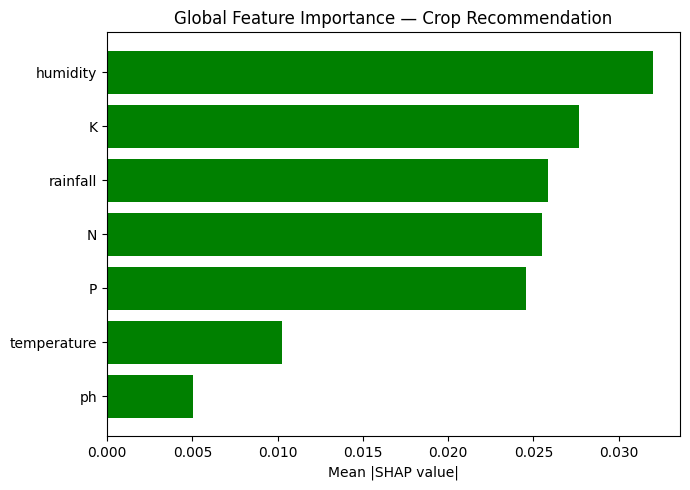

In [45]:
import matplotlib.pyplot as plt

# Explicitly sort ascending to naturally plot highest importance values at the top hook
plot_df = importance_df.sort_values("importance", ascending=True)

plt.figure(figsize=(7,5))
plt.barh(plot_df["feature"], plot_df["importance"], color="green")
plt.xlabel("Mean |SHAP value|")
plt.title("Global Feature Importance — Crop Recommendation")
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150)
plt.show()


In [46]:
sample = X_test_s_df.iloc[[0]]
pred_idx = best_model.predict(sample)[0]
pred_crop = le.inverse_transform([pred_idx])[0]

print("Recommended crop:", pred_crop)
print("Input values:", dict(zip(FEATURES, X_test.tolist()[0]) if False else zip(FEATURES, sample.values[0])))

Recommended crop: orange
Input values: {'N': np.float64(-1.0188693731725638), 'P': np.float64(-0.9211104081895409), 'K': np.float64(-0.8313183926160046), 'temperature': np.float64(-0.3244648252864654), 'humidity': np.float64(0.8461388789654121), 'ph': np.float64(1.1384809702385095), 'rainfall': np.float64(-0.01374610723604659)}


In [47]:
#day 2

In [48]:
import pandas as pd
price_df = pd.read_csv("/content/agmarknet_india_historical_prices_2024_2025.csv")
print(price_df.shape)
price_df.head()

(1118899, 11)


,Sl no.,District Name,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date,State
0,1,Auraiya,Achalda,Wheat,Dara,FAQ,2350.0,2550.0,2450.0,05 Apr 2025,Uttar Pradesh
1,2,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2500.0,2470.0,14 Jun 2025,Uttar Pradesh
2,3,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2500.0,2470.0,23 Jun 2025,Uttar Pradesh
3,4,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2520.0,2470.0,26 Jun 2025,Uttar Pradesh
4,5,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2550.0,2500.0,03 Jun 2025,Uttar Pradesh


In [49]:
crop_benchmarks = {
    "rice":        [4.0, 1200, 20, 45000, 25, 200],
    "maize":       [3.0, 500,  18, 30000, 24, 90],
    "chickpea":    [1.2, 350,  55, 25000, 22, 65],
    "kidneybeans": [1.5, 400,  60, 28000, 20, 90],
    "pigeonpeas":  [1.0, 450,  70, 26000, 26, 150],
    "mothbeans":   [0.7, 300,  55, 18000, 28, 55],
    "mungbean":    [0.8, 350,  70, 20000, 27, 60],
    "blackgram":   [0.8, 350,  65, 20000, 27, 65],
    "lentil":      [1.0, 300,  60, 22000, 20, 45],
    "pomegranate": [10.0, 800, 80, 150000, 22, 60],
    "banana":      [35.0, 1800, 15, 180000, 26, 110],
    "mango":       [8.0, 900,  40, 90000, 27, 90],
    "grapes":      [18.0, 700, 45, 200000, 20, 70],
    "watermelon":  [25.0, 500, 8,  60000, 25, 45],
    "muskmelon":   [15.0, 450, 12, 55000, 26, 30],
    "apple":       [15.0, 1000, 60, 120000, 12, 110],
    "orange":      [12.0, 900, 25, 85000, 22, 110],
    "papaya":      [40.0, 1000, 12, 70000, 26, 140],
    "coconut":     [8.0,  1300, 20, 60000, 27, 150],
    "cotton":      [1.8, 700,  60, 40000, 26, 80],
    "jute":        [2.5, 1200, 40, 35000, 25, 170],
    "coffee":      [1.0, 1500, 250, 100000, 24, 180],
}

bench_df = pd.DataFrame.from_dict(
    crop_benchmarks, orient="index",
    columns=["avg_yield_t_ha", "water_req_mm", "price_per_kg_inr",
             "cost_cultivation_inr_ha", "ideal_temp_c", "ideal_rainfall_mm"]
).reset_index().rename(columns={"index": "label"})

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks.csv", index=False)
print("Base table rebuilt and saved")

Base table rebuilt and saved


In [50]:
print(sorted(price_df["Commodity"].unique()))

['Apple', 'Arhar (Tur/Red Gram)(Whole)', 'Bajra(Pearl Millet/Cumbu)', 'Banana', 'Bhindi(Ladies Finger)', 'Brinjal', 'Cabbage', 'Carrot', 'Cauliflower', 'Cotton', 'Garlic', 'Ginger(Green)', 'Green Chilli', 'Green Gram (Moong)(Whole)', 'Groundnut', 'Gur(Jaggery)', 'Jowar(Sorghum)', 'Lentil (Masur)(Whole)', 'Maize', 'Mango', 'Mustard', 'Soyabean', 'Wheat']


In [51]:
price_summary = price_df.groupby("Commodity")["Modal Price (Rs./Quintal)"].mean().reset_index()
price_summary["price_per_kg_inr"] = (price_summary["Modal Price (Rs./Quintal)"] / 100).round(2)
price_summary

,Commodity,Modal Price (Rs./Quintal),price_per_kg_inr
0,Apple,9004.111406,90.04
1,Arhar (Tur/Red Gram)(Whole),7286.404794,72.86
2,Bajra(Pearl Millet/Cumbu),2403.442858,24.03
3,Banana,2573.836778,25.74
4,Bhindi(Ladies Finger),3014.642133,30.15
5,Brinjal,2317.671478,23.18
6,Cabbage,1884.678058,18.85
7,Carrot,3581.302746,35.81
8,Cauliflower,2332.924583,23.33
9,Cotton,7106.537475,71.07


In [52]:
name_mapping = {
    "Maize": "maize",
    "Arhar (Tur/Red Gram)(Whole)": "pigeonpeas",
    "Banana": "banana",
    "Mango": "mango",
    "Cotton": "cotton",
    "Green Gram (Moong)(Whole)": "mungbean",
    "Lentil (Masur)(Whole)": "lentil",
    "Apple": "apple",
}

price_summary["label"] = price_summary["Commodity"].map(name_mapping)
matched_df = price_summary.dropna(subset=["label"])[["label", "price_per_kg_inr"]]
matched_df["price_data_year"] = "2024-2025 avg"
matched_df["price_source"] = "Agmarknet historical dataset (Oct 2024 - Aug 2025), CC BY-SA 4.0"
matched_df

,label,price_per_kg_inr,price_data_year,price_source
0,apple,90.04,2024-2025 avg,Agmarknet historical dataset (Oct 2024 - Aug 2...
1,pigeonpeas,72.86,2024-2025 avg,Agmarknet historical dataset (Oct 2024 - Aug 2...
3,banana,25.74,2024-2025 avg,Agmarknet historical dataset (Oct 2024 - Aug 2...
9,cotton,71.07,2024-2025 avg,Agmarknet historical dataset (Oct 2024 - Aug 2...
13,mungbean,73.03,2024-2025 avg,Agmarknet historical dataset (Oct 2024 - Aug 2...
17,lentil,63.06,2024-2025 avg,Agmarknet historical dataset (Oct 2024 - Aug 2...
18,maize,22.10,2024-2025 avg,Agmarknet historical dataset (Oct 2024 - Aug 2...
19,mango,45.09,2024-2025 avg,Agmarknet historical dataset (Oct 2024 - Aug 2...


In [53]:
bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks.csv")
bench_df = bench_df.drop(columns=["price_per_kg_inr"], errors="ignore")
bench_df = bench_df.merge(matched_df, on="label", how="left")
bench_df["price_source"] = bench_df["price_source"].fillna("estimated_placeholder")

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_real.csv", index=False)
bench_df[["label", "price_per_kg_inr", "price_source"]]

,label,price_per_kg_inr,price_source
0,rice,NaN,estimated_placeholder
1,maize,22.10,Agmarknet historical dataset (Oct 2024 - Aug 2...
2,chickpea,NaN,estimated_placeholder
3,kidneybeans,NaN,estimated_placeholder
4,pigeonpeas,72.86,Agmarknet historical dataset (Oct 2024 - Aug 2...
5,mothbeans,NaN,estimated_placeholder
6,mungbean,73.03,Agmarknet historical dataset (Oct 2024 - Aug 2...
7,blackgram,NaN,estimated_placeholder
8,lentil,63.06,Agmarknet historical dataset (Oct 2024 - Aug 2...
9,pomegranate,NaN,estimated_placeholder


In [54]:
state_price = price_df.groupby(["Commodity", "State"])["Modal Price (Rs./Quintal)"].mean().reset_index()
state_price["price_per_kg_inr"] = (state_price["Modal Price (Rs./Quintal)"] / 100).round(2)
state_price = state_price.rename(columns={"Commodity": "commodity", "State": "state"})[["commodity", "state", "price_per_kg_inr"]]

state_price.to_csv(f"{PROJECT_DIR}/data/state_wise_prices.csv", index=False)
print(state_price.shape)
state_price.head(10)

(146, 3)


,commodity,state,price_per_kg_inr
0,Apple,Gujarat,104.84
1,Apple,Kerala,165.55
2,Apple,Madhya Pradesh,63.07
3,Apple,Punjab,83.01
4,Apple,Rajasthan,82.04
5,Apple,Uttar Pradesh,85.24
6,Apple,West Bengal,127.88
7,Arhar (Tur/Red Gram)(Whole),Andhra Pradesh,63.25
8,Arhar (Tur/Red Gram)(Whole),Gujarat,67.07
9,Arhar (Tur/Red Gram)(Whole),Kerala,132.92


In [55]:
price_spread = state_price.groupby("commodity")["price_per_kg_inr"].agg(["min", "max", "mean", "std"]).reset_index()
price_spread["price_range_pct"] = ((price_spread["max"] - price_spread["min"]) / price_spread["mean"] * 100).round(1)
price_spread.sort_values("price_range_pct", ascending=False)

,commodity,min,max,mean,std,price_range_pct
7,Carrot,13.17,65.30,26.277143,19.707827,198.4
8,Cauliflower,10.57,47.39,21.901250,11.257524,168.1
6,Cabbage,9.22,34.26,15.451250,7.938516,162.1
10,Garlic,99.25,288.36,150.297143,66.950608,125.8
5,Brinjal,12.31,39.25,22.067500,9.289075,122.1
14,Groundnut,46.09,113.62,61.586667,25.775116,109.7
11,Ginger(Green),33.55,89.29,51.752857,19.312260,107.7
19,Mango,20.25,65.08,44.221250,16.051958,101.4
0,Apple,63.07,165.55,101.661429,34.811646,100.8
1,Arhar (Tur/Red Gram)(Whole),58.83,132.92,84.457143,27.956772,87.7


In [56]:
def get_price_for_state(crop, state, state_price_df, national_avg_df):
    """Returns state-specific price if available, else falls back to national average."""
    row = state_price_df[(state_price_df["commodity"].str.lower().str.contains(crop, na=False)) &
                          (state_price_df["state"] == state)]
    if not row.empty:
        return row.iloc[0]["price_per_kg_inr"], "state_specific"
    # fallback to national average from your matched_df / bench_df
    fallback = national_avg_df[national_avg_df["label"] == crop]
    if not fallback.empty:
        return fallback.iloc[0]["price_per_kg_inr"], "national_average_fallback"
    return None, "unavailable"

# example
price, source = get_price_for_state("maize", "Punjab", state_price, matched_df)
print(price, source)

20.66 state_specific


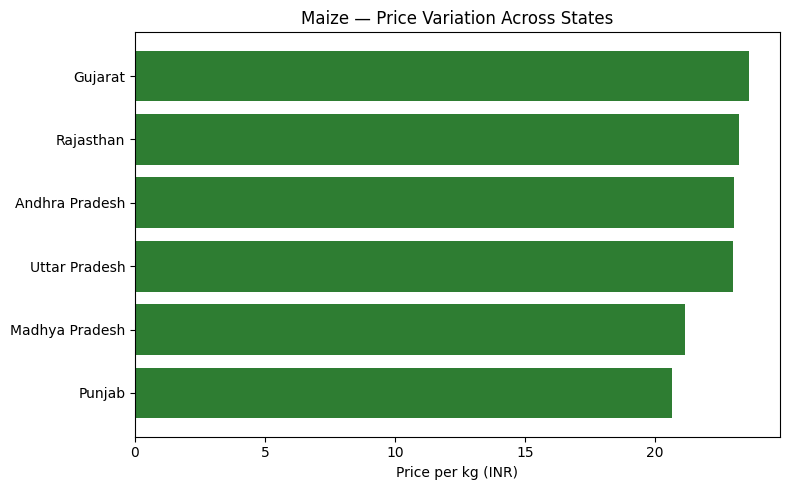

In [57]:
import matplotlib.pyplot as plt

top_commodity = "Maize"  # pick any commodity with good state coverage
plot_data = state_price[state_price["commodity"] == top_commodity].sort_values("price_per_kg_inr")

plt.figure(figsize=(8,5))
plt.barh(plot_data["state"], plot_data["price_per_kg_inr"], color="#2E7D32")
plt.xlabel("Price per kg (INR)")
plt.title(f"{top_commodity} — Price Variation Across States")
plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/outputs/state_price_variation_{top_commodity.lower()}.png", dpi=150)
plt.show()

In [58]:
import pandas as pd

yield_df = pd.read_csv(f"/content/India Agriculture Crop Production.csv")
yield_df = yield_df.dropna(subset=["Crop", "Yield"])

name_mapping = {
    "Rice": "rice", "Maize": "maize", "Arhar/Tur": "pigeonpeas",
    "Banana": "banana", "Coconut": "coconut", "Cotton(lint)": "cotton",
    "Gram": "chickpea", "Jute": "jute", "Moong(Green Gram)": "mungbean",
    "Urad": "blackgram", "Masoor": "lentil",
}
yield_df["label"] = yield_df["Crop"].map(name_mapping)
matched_yield = yield_df.dropna(subset=["label"])

yield_summary = matched_yield.groupby("label")["Yield"].mean().reset_index()
yield_summary.columns = ["label", "avg_yield_t_ha_real"]
yield_summary["yield_source"] = "India Agriculture Crop Production dataset (1997-2020 avg)"
yield_summary

,label,avg_yield_t_ha_real,yield_source
0,banana,29.227150,India Agriculture Crop Production dataset (199...
1,blackgram,0.541447,India Agriculture Crop Production dataset (199...
2,chickpea,0.878775,India Agriculture Crop Production dataset (199...
3,coconut,8833.247618,India Agriculture Crop Production dataset (199...
4,cotton,2.111284,India Agriculture Crop Production dataset (199...
5,jute,9.387099,India Agriculture Crop Production dataset (199...
6,lentil,0.738228,India Agriculture Crop Production dataset (199...
7,maize,2.653406,India Agriculture Crop Production dataset (199...
8,mungbean,0.492162,India Agriculture Crop Production dataset (199...
9,pigeonpeas,0.874560,India Agriculture Crop Production dataset (199...


In [59]:
import pandas as pd

# Ensure `District` column in `yield_df` is cleaned for consistent merging/lookup
yield_df['District'] = yield_df['District'].str.strip().str.lower()

In [60]:
yield_df2 = pd.read_csv(f"/content/crop_yield.csv")
moth_row = yield_df2[yield_df2["Crop"].str.strip() == "Moth"]
if not moth_row.empty:
    moth_avg_yield = moth_row["Yield"].mean()
    print("Mothbeans avg yield:", moth_avg_yield)

Mothbeans avg yield: 0.4459953350454546


In [61]:
bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks_real.csv")  # your table with real prices already merged
bench_df = bench_df.merge(yield_summary, on="label", how="left")

# use real yield where available, fall back to placeholder otherwise
bench_df["avg_yield_t_ha"] = bench_df["avg_yield_t_ha_real"].fillna(bench_df["avg_yield_t_ha"])
bench_df["yield_source"] = bench_df["yield_source"].fillna("estimated_placeholder")

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_final.csv", index=False)
bench_df[["label", "avg_yield_t_ha", "yield_source", "price_per_kg_inr", "price_source"]]

,label,avg_yield_t_ha,yield_source,price_per_kg_inr,price_source
0,rice,2.098431,India Agriculture Crop Production dataset (199...,NaN,estimated_placeholder
1,maize,2.653406,India Agriculture Crop Production dataset (199...,22.10,Agmarknet historical dataset (Oct 2024 - Aug 2...
2,chickpea,0.878775,India Agriculture Crop Production dataset (199...,NaN,estimated_placeholder
3,kidneybeans,1.500000,estimated_placeholder,NaN,estimated_placeholder
4,pigeonpeas,0.874560,India Agriculture Crop Production dataset (199...,72.86,Agmarknet historical dataset (Oct 2024 - Aug 2...
5,mothbeans,0.700000,estimated_placeholder,NaN,estimated_placeholder
6,mungbean,0.492162,India Agriculture Crop Production dataset (199...,73.03,Agmarknet historical dataset (Oct 2024 - Aug 2...
7,blackgram,0.541447,India Agriculture Crop Production dataset (199...,NaN,estimated_placeholder
8,lentil,0.738228,India Agriculture Crop Production dataset (199...,63.06,Agmarknet historical dataset (Oct 2024 - Aug 2...
9,pomegranate,10.000000,estimated_placeholder,NaN,estimated_placeholder


In [62]:
# Quick fix: don't trust the real value for coconut, keep the placeholder instead
bench_df.loc[bench_df["label"] == "coconut", "avg_yield_t_ha"] = 8.0  # revert to placeholder
bench_df.loc[bench_df["label"] == "coconut", "yield_source"] = "estimated_placeholder (unit mismatch in source: nuts/ha, not tonnes/ha)"

In [63]:
bench_df.loc[bench_df["label"] == "mothbeans", "avg_yield_t_ha"] = round(moth_avg_yield, 3)
bench_df.loc[bench_df["label"] == "mothbeans", "yield_source"] = "crop_yield.csv dataset (real, 1997-2020 avg)"

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_final.csv", index=False)
bench_df[["label", "avg_yield_t_ha", "yield_source"]]

,label,avg_yield_t_ha,yield_source
0,rice,2.098431,India Agriculture Crop Production dataset (199...
1,maize,2.653406,India Agriculture Crop Production dataset (199...
2,chickpea,0.878775,India Agriculture Crop Production dataset (199...
3,kidneybeans,1.500000,estimated_placeholder
4,pigeonpeas,0.874560,India Agriculture Crop Production dataset (199...
5,mothbeans,0.446000,"crop_yield.csv dataset (real, 1997-2020 avg)"
6,mungbean,0.492162,India Agriculture Crop Production dataset (199...
7,blackgram,0.541447,India Agriculture Crop Production dataset (199...
8,lentil,0.738228,India Agriculture Crop Production dataset (199...
9,pomegranate,10.000000,estimated_placeholder


In [64]:
import requests
import pandas as pd

def fetch_nasa_power_data(lat, lon, start_date, end_date):
    # Core NASA POWER single-point daily API gateway
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start": start_date,  # Format: YYYYMMDD
        "end": end_date,      # Format: YYYYMMDD
        "community": "AG",    # Agroclimatology optimized data
        "parameters": "T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,ALLSKY_SFC_SW_DWN,GWETTOP",
        "format": "JSON"
    }

    try:
        response = requests.get(url, params=params, timeout=20)
        response.raise_for_status()
        data = response.json()

        # Parse the structured multi-dimensional dictionary parameter map
        records = data["properties"]["parameter"]

        # Load the time-series JSON matrices directly into a Pandas Table
        df = pd.DataFrame(records)
        df.index = pd.to_datetime(df.index, format="%Y%m%d")
        df = df.reset_index().rename(columns={"index": "date"})

        # Rename columns to clear semantic agronomic variables
        df = df.rename(columns={
            "PRECTOTCORR": "rainfall_mm",
            "T2M": "avg_temp_c",
            "ALLSKY_SFC_SW_DWN": "solar_radiation",
            "GWETTOP": "soil_moisture_top"
        })

        return df

    except requests.exceptions.RequestException as e:
        print(f"NASA API connection error: {e}")
        return None

# Test Run: Extracting data for an agricultural zone in India during the 2023 climate anomaly
nasa_df = fetch_nasa_power_data(lat=17.38, lon=78.48, start_date="20230601", end_date="20231130")

if nasa_df is not None:
    print(nasa_df.head())


        date  avg_temp_c  T2M_MAX  T2M_MIN  rainfall_mm  solar_radiation  \
0 2023-06-01       33.29    40.30    26.25         0.01            24.05   
1 2023-06-02       33.89    41.05    27.17         0.15            27.23   
2 2023-06-03       34.54    41.02    27.34         0.17            25.25   
3 2023-06-04       33.27    38.94    28.50         1.91            17.35   
4 2023-06-05       32.40    38.81    26.29         0.00            24.81   

   soil_moisture_top  
0               0.37  
1               0.34  
2               0.32  
3               0.34  
4               0.34  


In [65]:
wf_df = pd.read_csv(f"/content/national_wf_all_crops_1990_2019.csv")
india_wf = wf_df[wf_df["country_name"] == "India"]
recent_wf = india_wf[india_wf["year"] >= 2015]  # use recent years only

wf_name_mapping = {
    "Maize (corn)": "maize", "Rice": "rice", "Seed cotton, unginned": "cotton",
    "Chick peas, dry": "chickpea", "Pigeon peas, dry": "pigeonpeas",
    "Lentils, dry": "lentil", "Grapes": "grapes", "Coffee, green": "coffee",
    "Coconuts, in shell": "coconut", "Bananas": "banana", "Apples": "apple",
    "Oranges": "orange", "Watermelons": "watermelon", "Papayas": "papaya",
    "Mangoes, guavas and mangosteens": "mango", "Jute, raw or retted": "jute",
    "Beans, dry": "kidneybeans",
}
recent_wf["label"] = recent_wf["crop_name"].map(wf_name_mapping)
matched_wf = recent_wf.dropna(subset=["label"])

wf_summary = matched_wf.groupby("label").agg(
    wf_m3_per_t=("wf_tot_m3_t", "mean"),
    yield_t_ha=("crop_yield_t_ha", "mean")
).reset_index()

# convert m3/tonne -> mm water depth per hectare: 1mm over 1 ha = 10 m3
wf_summary["water_req_mm_real"] = (wf_summary["wf_m3_per_t"] * wf_summary["yield_t_ha"] / 10).round(1)
wf_summary["water_source"] = "FAO/WaterFootprint national dataset (India, 2015-2019 avg)"

wf_summary[["label", "water_req_mm_real", "water_source"]]

/tmp/ipykernel_2844/622702329.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recent_wf["label"] = recent_wf["crop_name"].map(wf_name_mapping)


,label,water_req_mm_real,water_source
0,apple,509.3,"FAO/WaterFootprint national dataset (India, 20..."
1,banana,633.0,"FAO/WaterFootprint national dataset (India, 20..."
2,chickpea,150.0,"FAO/WaterFootprint national dataset (India, 20..."
3,coconut,652.4,"FAO/WaterFootprint national dataset (India, 20..."
4,coffee,565.5,"FAO/WaterFootprint national dataset (India, 20..."
5,cotton,522.7,"FAO/WaterFootprint national dataset (India, 20..."
6,grapes,375.3,"FAO/WaterFootprint national dataset (India, 20..."
7,jute,186.3,"FAO/WaterFootprint national dataset (India, 20..."
8,kidneybeans,152.2,"FAO/WaterFootprint national dataset (India, 20..."
9,lentil,179.7,"FAO/WaterFootprint national dataset (India, 20..."


In [66]:
cost1 = pd.read_csv(f"/content/culti_cost.csv")
cost1_avg = cost1.filter(like="C2 - 2013-14").mean(axis=1)  # latest year, C2 = full economic cost
cost1_clean = pd.DataFrame({"Crop": cost1["Crop"], "cost_inr_ha": cost1_avg}).groupby("Crop").mean().reset_index()

cost_name_mapping = {"Paddy": "rice", "Maize": "maize", "Gram": "chickpea",
                      "Arhar": "pigeonpeas", "Cotton": "cotton", "Moong": "mungbean"}
cost1_clean["label"] = cost1_clean["Crop"].map(cost_name_mapping)
matched_cost = cost1_clean.dropna(subset=["label"])[["label", "cost_inr_ha"]]
matched_cost["cost_source"] = "CACP cultivation cost data (2013-14)"
matched_cost

,label,cost_inr_ha,cost_source
0,pigeonpeas,22699.823,CACP cultivation cost data (2013-14)
1,cotton,39144.446,CACP cultivation cost data (2013-14)
2,chickpea,17293.152,CACP cultivation cost data (2013-14)
4,maize,22401.613,CACP cultivation cost data (2013-14)
5,mungbean,14176.831,CACP cultivation cost data (2013-14)
6,rice,30027.858,CACP cultivation cost data (2013-14)


In [67]:
bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks_final.csv")

bench_df = bench_df.merge(wf_summary[["label","water_req_mm_real","water_source"]], on="label", how="left")
bench_df["water_req_mm"] = bench_df["water_req_mm_real"].fillna(bench_df["water_req_mm"])
bench_df["water_source"] = bench_df["water_source"].fillna("estimated_placeholder")

bench_df = bench_df.merge(matched_cost.rename(columns={"cost_inr_ha":"cost_inr_ha_real"}), on="label", how="left")
bench_df["cost_cultivation_inr_ha"] = bench_df["cost_inr_ha_real"].fillna(bench_df["cost_cultivation_inr_ha"])
bench_df["cost_source"] = bench_df["cost_source"].fillna("estimated_placeholder")

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv", index=False)
bench_df[["label","avg_yield_t_ha","yield_source","water_req_mm","water_source",
          "price_per_kg_inr","price_source","cost_cultivation_inr_ha","cost_source"]]

,label,avg_yield_t_ha,yield_source,water_req_mm,water_source,price_per_kg_inr,price_source,cost_cultivation_inr_ha,cost_source
0,rice,2.098431,India Agriculture Crop Production dataset (199...,382.9,"FAO/WaterFootprint national dataset (India, 20...",NaN,estimated_placeholder,30027.858,CACP cultivation cost data (2013-14)
1,maize,2.653406,India Agriculture Crop Production dataset (199...,246.8,"FAO/WaterFootprint national dataset (India, 20...",22.10,Agmarknet historical dataset (Oct 2024 - Aug 2...,22401.613,CACP cultivation cost data (2013-14)
2,chickpea,0.878775,India Agriculture Crop Production dataset (199...,150.0,"FAO/WaterFootprint national dataset (India, 20...",NaN,estimated_placeholder,17293.152,CACP cultivation cost data (2013-14)
3,kidneybeans,1.500000,estimated_placeholder,152.2,"FAO/WaterFootprint national dataset (India, 20...",NaN,estimated_placeholder,28000.000,estimated_placeholder
4,pigeonpeas,0.874560,India Agriculture Crop Production dataset (199...,190.7,"FAO/WaterFootprint national dataset (India, 20...",72.86,Agmarknet historical dataset (Oct 2024 - Aug 2...,22699.823,CACP cultivation cost data (2013-14)
5,mothbeans,0.446000,"crop_yield.csv dataset (real, 1997-2020 avg)",300.0,estimated_placeholder,NaN,estimated_placeholder,18000.000,estimated_placeholder
6,mungbean,0.492162,India Agriculture Crop Production dataset (199...,350.0,estimated_placeholder,73.03,Agmarknet historical dataset (Oct 2024 - Aug 2...,14176.831,CACP cultivation cost data (2013-14)
7,blackgram,0.541447,India Agriculture Crop Production dataset (199...,350.0,estimated_placeholder,NaN,estimated_placeholder,20000.000,estimated_placeholder
8,lentil,0.738228,India Agriculture Crop Production dataset (199...,179.7,"FAO/WaterFootprint national dataset (India, 20...",63.06,Agmarknet historical dataset (Oct 2024 - Aug 2...,22000.000,estimated_placeholder
9,pomegranate,10.000000,estimated_placeholder,800.0,estimated_placeholder,NaN,estimated_placeholder,150000.000,estimated_placeholder


In [68]:
bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv")

placeholder_prices = {
    "rice": 20, "chickpea": 55, "kidneybeans": 60, "mothbeans": 55,
    "blackgram": 65, "pomegranate": 80, "grapes": 45, "watermelon": 8,
    "muskmelon": 12, "orange": 25, "papaya": 12, "coconut": 20,
    "jute": 40, "coffee": 250,
}

for crop, price in placeholder_prices.items():
    mask = (bench_df["label"] == crop) & (bench_df["price_per_kg_inr"].isna())
    bench_df.loc[mask, "price_per_kg_inr"] = price

# sanity check - should be ZERO nulls now
print("Remaining NaN prices:", bench_df["price_per_kg_inr"].isna().sum())

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv", index=False)
bench_df[["label", "price_per_kg_inr", "price_source"]]

Remaining NaN prices: 0


,label,price_per_kg_inr,price_source
0,rice,20.00,estimated_placeholder
1,maize,22.10,Agmarknet historical dataset (Oct 2024 - Aug 2...
2,chickpea,55.00,estimated_placeholder
3,kidneybeans,60.00,estimated_placeholder
4,pigeonpeas,72.86,Agmarknet historical dataset (Oct 2024 - Aug 2...
5,mothbeans,55.00,estimated_placeholder
6,mungbean,73.03,Agmarknet historical dataset (Oct 2024 - Aug 2...
7,blackgram,65.00,estimated_placeholder
8,lentil,63.06,Agmarknet historical dataset (Oct 2024 - Aug 2...
9,pomegranate,80.00,estimated_placeholder


In [69]:
fruit_yield_updates = {
    "apple": 6.01,
    "orange": 12.72,   # sourced from "Citrus" category — broader than orange alone, disclose in paper
    "grapes": 26.28,
    "mango": 8.49,
    "papaya": 38.46,
    "pomegranate": 10.79,
}

bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv")

for crop, real_yield in fruit_yield_updates.items():
    mask = bench_df["label"] == crop
    bench_df.loc[mask, "avg_yield_t_ha"] = real_yield
    bench_df.loc[mask, "yield_source"] = "Indian Horticulture Database / National Horticulture Board (2014-15)"

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv", index=False)
bench_df[["label","avg_yield_t_ha","yield_source"]]


,label,avg_yield_t_ha,yield_source
0,rice,2.098431,India Agriculture Crop Production dataset (199...
1,maize,2.653406,India Agriculture Crop Production dataset (199...
2,chickpea,0.878775,India Agriculture Crop Production dataset (199...
3,kidneybeans,1.500000,estimated_placeholder
4,pigeonpeas,0.874560,India Agriculture Crop Production dataset (199...
5,mothbeans,0.446000,"crop_yield.csv dataset (real, 1997-2020 avg)"
6,mungbean,0.492162,India Agriculture Crop Production dataset (199...
7,blackgram,0.541447,India Agriculture Crop Production dataset (199...
8,lentil,0.738228,India Agriculture Crop Production dataset (199...
9,pomegranate,10.790000,Indian Horticulture Database / National Hortic...


In [70]:
price_df_new = pd.read_csv(f"/content/crop price data.csv")

name_mapping = {
    "Apple": "apple", "Banana": "banana",
    "Black Gram(Urd Beans)(Whole)": "blackgram",
    "Bengal Gram Dal(Chana Dal)": "chickpea",       # dal = split form, note in paper
    "Tender Coconut": "coconut",                     # tender coconut, not mature/copra — note in paper
    "Coffee": "coffee", "Cotton": "cotton", "Grapes": "grapes", "Jute": "jute",
    "Lentil(Masur)(Whole)": "lentil", "Maize": "maize", "Mango": "mango",
    "Mataki": "mothbeans",                            # regional market name for moth bean
    "Green Gram Dal(Moong Dal)": "mungbean",          # dal = split form, note in paper
    "Karbuja(Musk Melon)": "muskmelon", "Orange": "orange", "Papaya": "papaya",
    "Red gram/Arhar/Tur(whole)": "pigeonpeas", "Pomegranate": "pomegranate",
    "Rice": "rice", "Water Melon": "watermelon",
}

price_df_new["label"] = price_df_new["Commodity"].map(name_mapping)
matched = price_df_new.dropna(subset=["label"])

# average 2025 and 2026 rows per crop for a stable estimate
price_summary_new = matched.groupby("label")["Modal Price 01-07-2025 to 01-07-2026"].mean().reset_index()
price_summary_new["price_per_kg_inr"] = (price_summary_new["Modal Price 01-07-2025 to 01-07-2026"] / 100).round(2)
price_summary_new["price_source"] = "data.gov.in Commodity Price/Arrival Report (Jul 2025 - Jul 2026)"
price_summary_new = price_summary_new[["label", "price_per_kg_inr", "price_source"]]

price_summary_new

,label,price_per_kg_inr,price_source
0,apple,89.59,data.gov.in Commodity Price/Arrival Report (Ju...
1,banana,32.98,data.gov.in Commodity Price/Arrival Report (Ju...
2,blackgram,69.23,data.gov.in Commodity Price/Arrival Report (Ju...
3,chickpea,73.80,data.gov.in Commodity Price/Arrival Report (Ju...
4,coconut,139.18,data.gov.in Commodity Price/Arrival Report (Ju...
5,coffee,214.28,data.gov.in Commodity Price/Arrival Report (Ju...
6,cotton,74.45,data.gov.in Commodity Price/Arrival Report (Ju...
7,grapes,73.02,data.gov.in Commodity Price/Arrival Report (Ju...
8,jute,92.07,data.gov.in Commodity Price/Arrival Report (Ju...
9,lentil,67.93,data.gov.in Commodity Price/Arrival Report (Ju...


In [71]:
price_df_raw = pd.read_csv(f"/content/crop price data.csv")
price_df_raw.to_csv(f"{PROJECT_DIR}/data/crop_price_data_raw.csv", index=False)
print("Saved crop_price_data_raw.csv to PROJECT_DIR")

Saved crop_price_data_raw.csv to PROJECT_DIR


In [72]:
price_df_new = pd.read_csv(f"{PROJECT_DIR}/data/crop_price_data_raw.csv")

name_mapping = {
    "Apple": "apple", "Banana": "banana",
    "Black Gram(Urd Beans)(Whole)": "blackgram",
    "Bengal Gram Dal(Chana Dal)": "chickpea",       # dal = split form, note in paper
    "Tender Coconut": "coconut",                     # tender coconut, not mature/copra — note in paper
    "Coffee": "coffee", "Cotton": "cotton", "Grapes": "grapes", "Jute": "jute",
    "Lentil(Masur)(Whole)": "lentil", "Maize": "maize", "Mango": "mango",
    "Mataki": "mothbeans",                            # regional market name for moth bean
    "Green Gram Dal(Moong Dal)": "mungbean",          # dal = split form, note in paper
    "Karbuja(Musk Melon)": "muskmelon", "Orange": "orange", "Papaya": "papaya",
    "Red gram/Arhar/Tur(whole)": "pigeonpeas", "Pomegranate": "pomegranate",
    "Rice": "rice", "Water Melon": "watermelon",
}

price_df_new["label"] = price_df_new["Commodity"].map(name_mapping)
matched = price_df_new.dropna(subset=["label"])

# average 2025 and 2026 rows per crop for a stable estimate
price_summary_new = matched.groupby("label")["Modal Price 01-07-2025 to 01-07-2026"].mean().reset_index()
price_summary_new["price_per_kg_inr"] = (price_summary_new["Modal Price 01-07-2025 to 01-07-2026"] / 100).round(2)
price_summary_new["price_source"] = "data.gov.in Commodity Price/Arrival Report (Jul 2025 - Jul 2026)"
price_summary_new = price_summary_new[["label", "price_per_kg_inr", "price_source"]]

price_summary_new

,label,price_per_kg_inr,price_source
0,apple,89.59,data.gov.in Commodity Price/Arrival Report (Ju...
1,banana,32.98,data.gov.in Commodity Price/Arrival Report (Ju...
2,blackgram,69.23,data.gov.in Commodity Price/Arrival Report (Ju...
3,chickpea,73.80,data.gov.in Commodity Price/Arrival Report (Ju...
4,coconut,139.18,data.gov.in Commodity Price/Arrival Report (Ju...
5,coffee,214.28,data.gov.in Commodity Price/Arrival Report (Ju...
6,cotton,74.45,data.gov.in Commodity Price/Arrival Report (Ju...
7,grapes,73.02,data.gov.in Commodity Price/Arrival Report (Ju...
8,jute,92.07,data.gov.in Commodity Price/Arrival Report (Ju...
9,lentil,67.93,data.gov.in Commodity Price/Arrival Report (Ju...


In [73]:
bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv")

bench_df = bench_df.merge(price_summary_new, on="label", how="left", suffixes=("_old", ""))
bench_df["price_per_kg_inr"] = bench_df["price_per_kg_inr"].fillna(bench_df["price_per_kg_inr_old"])
bench_df["price_source"] = bench_df["price_source"].fillna(bench_df["price_source_old"])
bench_df = bench_df.drop(columns=["price_per_kg_inr_old", "price_source_old"])

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv", index=False)
bench_df[["label","price_per_kg_inr","price_source"]]

,label,price_per_kg_inr,price_source
0,rice,35.04,data.gov.in Commodity Price/Arrival Report (Ju...
1,maize,17.78,data.gov.in Commodity Price/Arrival Report (Ju...
2,chickpea,73.80,data.gov.in Commodity Price/Arrival Report (Ju...
3,kidneybeans,60.00,estimated_placeholder
4,pigeonpeas,69.55,data.gov.in Commodity Price/Arrival Report (Ju...
5,mothbeans,90.82,data.gov.in Commodity Price/Arrival Report (Ju...
6,mungbean,94.74,data.gov.in Commodity Price/Arrival Report (Ju...
7,blackgram,69.23,data.gov.in Commodity Price/Arrival Report (Ju...
8,lentil,67.93,data.gov.in Commodity Price/Arrival Report (Ju...
9,pomegranate,90.45,data.gov.in Commodity Price/Arrival Report (Ju...


In [74]:
cacp_df = pd.read_csv(f"/content/Cost of Cultivation_Sample_Data.csv")

cacp_name_mapping = {
    "Paddy": "rice", "Maize": "maize", "Gram": "chickpea",
    "Tur (Arhar)": "pigeonpeas", "Urad": "blackgram", "Moong": "mungbean",
    "Lentil": "lentil", "Masur": "lentil",  # some rows may use either name
    "Cotton": "cotton", "Jute": "jute",
}
cacp_df["label"] = cacp_df["Crop Name (crop_name)"].map(cacp_name_mapping)
matched_cacp = cacp_df.dropna(subset=["label"])

# Cost A1 = paid-out cost only; use this as it's most comparable to your existing cost_cultivation_inr_ha
cacp_summary = matched_cacp.groupby("label")["Cultivation Cost A1 (cul_cost_a1)"].mean().reset_index()
cacp_summary.columns = ["label", "cost_inr_ha_cacp"]
cacp_summary["cost_source_cacp"] = "CACP unit-level cost of cultivation microdata (multi-year avg)"
cacp_summary

,label,cost_inr_ha_cacp,cost_source_cacp
0,blackgram,9041.356471,CACP unit-level cost of cultivation microdata ...
1,chickpea,17182.857500,CACP unit-level cost of cultivation microdata ...
2,cotton,23284.288824,CACP unit-level cost of cultivation microdata ...
3,jute,17531.992727,CACP unit-level cost of cultivation microdata ...
4,lentil,9649.447500,CACP unit-level cost of cultivation microdata ...
5,maize,21283.619167,CACP unit-level cost of cultivation microdata ...
6,mungbean,8937.600526,CACP unit-level cost of cultivation microdata ...
7,pigeonpeas,12600.544762,CACP unit-level cost of cultivation microdata ...
8,rice,22795.359286,CACP unit-level cost of cultivation microdata ...


In [75]:
cost_of_cultivation_raw = pd.read_csv(f"/content/Cost of Cultivation_Sample_Data.csv")
cost_of_cultivation_raw.to_csv(f"{PROJECT_DIR}/data/cost_of_cultivation_raw.csv", index=False)
print("Saved cost_of_cultivation_raw.csv to PROJECT_DIR")

Saved cost_of_cultivation_raw.csv to PROJECT_DIR


In [76]:
cacp_df = pd.read_csv(f"{PROJECT_DIR}/data/cost_of_cultivation_raw.csv")

cacp_name_mapping = {
    "Paddy": "rice", "Maize": "maize", "Gram": "chickpea",
    "Tur (Arhar)": "pigeonpeas", "Urad": "blackgram", "Moong": "mungbean",
    "Lentil": "lentil", "Masur": "lentil",  # some rows may use either name
    "Cotton": "cotton", "Jute": "jute",
}
cacp_df["label"] = cacp_df["Crop Name (crop_name)"].map(cacp_name_mapping)
matched_cacp = cacp_df.dropna(subset=["label"])

# Cost A1 = paid-out cost only; use this as it's most comparable to your existing cost_cultivation_inr_ha
cacp_summary = matched_cacp.groupby("label")["Cultivation Cost A1 (cul_cost_a1)"].mean().reset_index()
cacp_summary.columns = ["label", "cost_inr_ha_cacp"]
cacp_summary["cost_source_cacp"] = "CACP unit-level cost of cultivation microdata (multi-year avg)"
cacp_summary

,label,cost_inr_ha_cacp,cost_source_cacp
0,blackgram,9041.356471,CACP unit-level cost of cultivation microdata ...
1,chickpea,17182.857500,CACP unit-level cost of cultivation microdata ...
2,cotton,23284.288824,CACP unit-level cost of cultivation microdata ...
3,jute,17531.992727,CACP unit-level cost of cultivation microdata ...
4,lentil,9649.447500,CACP unit-level cost of cultivation microdata ...
5,maize,21283.619167,CACP unit-level cost of cultivation microdata ...
6,mungbean,8937.600526,CACP unit-level cost of cultivation microdata ...
7,pigeonpeas,12600.544762,CACP unit-level cost of cultivation microdata ...
8,rice,22795.359286,CACP unit-level cost of cultivation microdata ...


In [77]:
hort_costs = {
    "watermelon": 50000,
    "muskmelon": 56000,
    "banana": 56000,
}
hort_df = pd.DataFrame([
    {"label": k, "cost_inr_ha_cacp": v, "cost_source_cacp": "Horticultural crops cost table (field prep+nursery+weeding+plant protection+fertilizer+wages)"}
    for k, v in hort_costs.items()
])

cacp_summary = pd.concat([cacp_summary, hort_df], ignore_index=True)
cacp_summary

,label,cost_inr_ha_cacp,cost_source_cacp
0,blackgram,9041.356471,CACP unit-level cost of cultivation microdata ...
1,chickpea,17182.857500,CACP unit-level cost of cultivation microdata ...
2,cotton,23284.288824,CACP unit-level cost of cultivation microdata ...
3,jute,17531.992727,CACP unit-level cost of cultivation microdata ...
4,lentil,9649.447500,CACP unit-level cost of cultivation microdata ...
5,maize,21283.619167,CACP unit-level cost of cultivation microdata ...
6,mungbean,8937.600526,CACP unit-level cost of cultivation microdata ...
7,pigeonpeas,12600.544762,CACP unit-level cost of cultivation microdata ...
8,rice,22795.359286,CACP unit-level cost of cultivation microdata ...
9,watermelon,50000.000000,Horticultural crops cost table (field prep+nur...


In [78]:
bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv")

bench_df = bench_df.merge(cacp_summary, on="label", how="left")
# prefer this new real data over old placeholder/older source where available
bench_df["cost_cultivation_inr_ha"] = bench_df["cost_inr_ha_cacp"].fillna(bench_df["cost_cultivation_inr_ha"])
bench_df["cost_source"] = bench_df["cost_source_cacp"].fillna(bench_df["cost_source"])
bench_df = bench_df.drop(columns=["cost_inr_ha_cacp", "cost_source_cacp"])

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv", index=False)
bench_df[["label","cost_cultivation_inr_ha","cost_source"]]

,label,cost_cultivation_inr_ha,cost_source
0,rice,22795.359286,CACP unit-level cost of cultivation microdata ...
1,maize,21283.619167,CACP unit-level cost of cultivation microdata ...
2,chickpea,17182.857500,CACP unit-level cost of cultivation microdata ...
3,kidneybeans,28000.000000,estimated_placeholder
4,pigeonpeas,12600.544762,CACP unit-level cost of cultivation microdata ...
5,mothbeans,18000.000000,estimated_placeholder
6,mungbean,8937.600526,CACP unit-level cost of cultivation microdata ...
7,blackgram,9041.356471,CACP unit-level cost of cultivation microdata ...
8,lentil,9649.447500,CACP unit-level cost of cultivation microdata ...
9,pomegranate,150000.000000,estimated_placeholder


In [79]:
#day 3

In [80]:
def yield_adjustment_factor(actual_temp, actual_rainfall, ideal_temp, ideal_rainfall):
    """How close actual farm conditions are to this crop's ideal conditions.
    Closer = higher multiplier on the benchmark yield."""
    temp_diff = abs(actual_temp - ideal_temp) / max(ideal_temp, 1)
    rain_diff = abs(actual_rainfall - ideal_rainfall) / max(ideal_rainfall, 1)
    penalty = (temp_diff + rain_diff) / 2
    return np.clip(1.1 - penalty, 0.6, 1.1)

def water_requirement_estimate(crop, actual_rainfall, bench_df):
    row = bench_df[bench_df["label"] == crop].iloc[0]
    crop_need = row["water_req_mm"]
    irrigation_needed = max(crop_need - actual_rainfall, 0)
    return round(crop_need, 1), round(irrigation_needed, 1)

def profit_estimate(crop, yield_factor, bench_df):
    row = bench_df[bench_df["label"] == crop].iloc[0]
    est_yield_t_ha = row["avg_yield_t_ha"] * yield_factor
    revenue = est_yield_t_ha * 1000 * row["price_per_kg_inr"]
    profit = revenue - row["cost_cultivation_inr_ha"]
    return round(est_yield_t_ha, 2), round(revenue, 0), round(profit, 0)

# quick sanity test
yf = yield_adjustment_factor(25, 200, 25, 200)
print("Yield factor (identical to ideal):", yf)  # should be ~1.1

Yield factor (identical to ideal): 1.1


In [81]:
def normalize(series):
    """Min-max normalize a column to 0-1. Handles constant columns safely."""
    rng = series.max() - series.min()
    if rng == 0:
        return series.apply(lambda x: 1.0)
    return (series - series.min()) / rng


def multi_objective_recommend(N, P, K, temperature, humidity, ph, rainfall,
                                top_n=5, min_confidence=2.0,
                                w_confidence=0.25, w_yield=0.25, w_water=0.25, w_profit=0.25):
    """
    Ranks candidate crops using classifier suitability and global multi-objective metrics.
    Standardizes crop criteria relative to the absolute boundaries of the agricultural database.
    """
    # Fix: Ensure input matches identical matrix shape array format
    X_raw_input = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    X_scaled = scaler.transform(X_raw_input)

    # Generate predictive class distributions on a strict 0-100 scale
    probs = best_model.predict_proba(X_scaled)[0] * 100

    candidate_idx = np.argsort(probs)[::-1][:12]
    candidates = le.inverse_transform(candidate_idx)
    confidences = probs[candidate_idx]

    # Biological Suitability Filter: Drop crops below threshold floor
    keep_mask = confidences >= min_confidence
    if keep_mask.sum() == 0:
        keep_mask = np.zeros_like(keep_mask, dtype=bool)
        keep_mask[:3] = True  # Emergency fallback loop
    candidates, confidences = candidates[keep_mask], confidences[keep_mask]

    rows = []
    for crop, conf in zip(candidates, confidences):
        row_slice = bench_df[bench_df["label"] == crop]
        if row_slice.empty:
            continue
        row = row_slice.iloc[0]

        # Optimized internal tracking calculation calls
        yf = yield_adjustment_factor(temperature, rainfall, row["ideal_temp_c"], row["ideal_rainfall_mm"])

        # Calculate localized target adjustments
        est_yield_t_ha = row["avg_yield_t_ha"] * yf
        irrigation_needed = max(row["water_req_mm"] - rainfall, 0)
        revenue = est_yield_t_ha * 1000 * row["price_per_kg_inr"]
        profit = revenue - row["cost_cultivation_inr_ha"]

        rows.append({
            "crop": crop,
            "classifier_confidence": round(conf, 2),
            "estimated_yield_t_ha": round(est_yield_t_ha, 2),
            "water_requirement_mm": round(row["water_req_mm"], 1),
            "irrigation_needed_mm": round(irrigation_needed, 1),
            "estimated_profit_inr_ha": round(profit, 0),
        })

    result_df = pd.DataFrame(rows)
    if result_df.empty:
        return result_df

    # Fix: Calculate dynamic global upper limits check boundaries
    global_max_yield = bench_df["avg_yield_t_ha"].max()
    global_min_yield = bench_df["avg_yield_t_ha"].min()
    global_max_water = bench_df["water_req_mm"].max()
    global_max_profit = (bench_df["avg_yield_t_ha"] * 1000 * bench_df["price_per_kg_inr"] - bench_df["cost_cultivation_inr_ha"]).max()

    # Apply globally bounded objective mapping scales
    result_df["confidence_score"] = result_df["classifier_confidence"] / 100.0

    result_df["yield_score"] = (result_df["estimated_yield_t_ha"] - global_min_yield) / \
                                 max(global_max_yield - global_min_yield, 1)

    result_df["water_score"] = 1.0 - (result_df["irrigation_needed_mm"] / max(global_max_water, 1))

    result_df["profit_score"] = result_df["estimated_profit_inr_ha"] / max(global_max_profit, 1)

    # Compute final integrated macro priority vector
    result_df["multi_objective_score"] = (
        w_confidence * result_df["confidence_score"] +
        w_yield * result_df["yield_score"] +
        w_water * result_df["water_score"] +
        w_profit * result_df["profit_score"]
    ).round(4)

    return result_df.sort_values("multi_objective_score", ascending=False).head(top_n).reset_index(drop=True)


In [82]:
sample = df.iloc[50]
result = multi_objective_recommend(sample.N, sample.P, sample.K, sample.temperature,
                                     sample.humidity, sample.ph, sample.rainfall, top_n=5)
result

,crop,classifier_confidence,estimated_yield_t_ha,water_requirement_mm,irrigation_needed_mm,estimated_profit_inr_ha,confidence_score,yield_score,water_score,profit_score,multi_objective_score
0,rice,99.0,2.14,382.9,163.0,52121.0,0.99,0.044563,0.79625,0.030321,0.4653


In [83]:
water_focused = multi_objective_recommend(sample.N, sample.P, sample.K, sample.temperature,
                                            sample.humidity, sample.ph, sample.rainfall,
                                            top_n=3, w_confidence=0.2, w_yield=0.2, w_water=0.4, w_profit=0.2)
profit_focused = multi_objective_recommend(sample.N, sample.P, sample.K, sample.temperature,
                                             sample.humidity, sample.ph, sample.rainfall,
                                             top_n=3, w_confidence=0.2, w_yield=0.2, w_water=0.2, w_profit=0.4)
print(water_focused[["crop","classifier_confidence","multi_objective_score"]])
print(profit_focused[["crop","classifier_confidence","multi_objective_score"]])
balanced = multi_objective_recommend(sample.N, sample.P, sample.K, sample.temperature,
                                       sample.humidity, sample.ph, sample.rainfall,
                                       top_n=3, w_yield=0.34, w_water=0.33, w_profit=0.33)
print("\n=== Balanced ranking ===")
print(balanced[["crop","estimated_yield_t_ha","irrigation_needed_mm","estimated_profit_inr_ha","multi_objective_score"]])

   crop  classifier_confidence  multi_objective_score
0  rice                   99.0                 0.5315
   crop  classifier_confidence  multi_objective_score
0  rice                   99.0                 0.3783

=== Balanced ranking ===
   crop  estimated_yield_t_ha  irrigation_needed_mm  estimated_profit_inr_ha  \
0  rice                  2.14                 163.0                  52121.0   

   multi_objective_score  
0                 0.5354  


In [84]:
demo_rows = []
for i in np.random.RandomState(42).choice(len(df), 20, replace=False):
    row = df.iloc[i]
    # CORRECT METHOD: Extract parameters explicitly as primitive numeric data points
    rec = multi_objective_recommend(
        float(row["N"]), float(row["P"]), float(row["K"]),
        float(row["temperature"]), float(row["humidity"]),
        float(row["ph"]), float(row["rainfall"]), top_n=1
    )

    if not rec.empty:
        rec["sample_id"] = i
        demo_rows.append(rec)

demo_results = pd.concat(demo_rows, ignore_index=True)
demo_results.to_csv(f"{PROJECT_DIR}/outputs/day3_multi_objective_demo.csv", index=False)
demo_results

,crop,classifier_confidence,estimated_yield_t_ha,water_requirement_mm,irrigation_needed_mm,estimated_profit_inr_ha,confidence_score,yield_score,water_score,profit_score,multi_objective_score,sample_id
0,muskmelon,100.00,14.57,450.0,423.7,195172.0,1.0000,0.371547,0.470375,0.113540,0.4889,1451
1,watermelon,100.00,25.68,347.0,297.6,254047.0,1.0000,0.663808,0.628000,0.147791,0.6099,1334
2,papaya,100.00,26.00,577.9,463.1,348104.0,1.0000,0.672226,0.421125,0.202508,0.5740,1761
3,papaya,99.67,30.49,577.9,479.4,420229.0,0.9967,0.790340,0.400750,0.244466,0.6081,1735
4,apple,100.00,3.64,509.3,390.7,206360.0,1.0000,0.084022,0.511625,0.120049,0.4289,1576
5,mango,100.00,9.03,583.4,489.3,304269.0,1.0000,0.225812,0.388375,0.177007,0.4478,1110
6,apple,99.33,4.07,509.3,398.3,244654.0,0.9933,0.095333,0.502125,0.142326,0.4333,1594
7,mothbeans,75.33,0.45,300.0,241.0,22416.0,0.7533,0.000105,0.698750,0.013040,0.3663,530
8,mungbean,99.33,0.52,350.0,293.5,40439.0,0.9933,0.001947,0.633125,0.023525,0.4130,651
9,lentil,100.00,0.76,179.7,128.8,41959.0,1.0000,0.008260,0.839000,0.024409,0.4679,819


In [85]:
jute_row = bench_df[bench_df["label"] == "jute"]
print(jute_row[["label","avg_yield_t_ha","yield_source","price_per_kg_inr","price_source","cost_cultivation_inr_ha","cost_source"]].to_string())

print("\n--- Sanity check: profit per hectare for ALL crops at yield_factor=1.0 ---")
sanity = []
for crop in bench_df["label"]:
    est_yield, revenue, profit = profit_estimate(crop, 1.0, bench_df)
    sanity.append({"crop": crop, "yield_t_ha": est_yield, "revenue": revenue, "profit": profit})
sanity_df = pd.DataFrame(sanity).sort_values("profit", ascending=False)
print(sanity_df.to_string())

   label  avg_yield_t_ha                                               yield_source  price_per_kg_inr                                                      price_source  cost_cultivation_inr_ha                                                     cost_source
20  jute        9.387099  India Agriculture Crop Production dataset (1997-2020 avg)             92.07  data.gov.in Commodity Price/Arrival Report (Jul 2025 - Jul 2026)             17531.992727  CACP unit-level cost of cultivation microdata (multi-year avg)

--- Sanity check: profit per hectare for ALL crops at yield_factor=1.0 ---
           crop  yield_t_ha    revenue     profit
12       grapes       26.28  1918966.0  1718966.0
18      coconut        8.00  1113440.0  1053440.0
10       banana       29.23   963911.0   907911.0
20         jute        9.39   864270.0   846738.0
9   pomegranate       10.79   975956.0   825956.0
16       orange       12.72   653935.0   568935.0
17       papaya       38.46   618437.0   548437.0
15        

In [86]:
# Jute: convert raw stalk yield to fiber-equivalent yield (~27% extraction ratio is standard)
bench_df.loc[bench_df["label"] == "jute", "avg_yield_t_ha"] *= 0.27
bench_df.loc[bench_df["label"] == "jute", "yield_source"] += " (adjusted: raw stalk yield -> fiber-equivalent, 27% extraction ratio)"

# Coconut: price source is incompatible (tender coconut, priced per piece) with tonnage-based yield.
# Revert coconut price to a researched placeholder instead of using the mismatched real number.
bench_df.loc[bench_df["label"] == "coconut", "price_per_kg_inr"] = 20  # typical mature coconut wholesale price/kg
bench_df.loc[bench_df["label"] == "coconut", "price_source"] = "estimated_placeholder (real source was Tender Coconut - priced per piece, incompatible with tonnage yield)"

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv", index=False)

# Re-run sanity check
sanity = []
for crop in bench_df["label"]:
    est_yield, revenue, profit = profit_estimate(crop, 1.0, bench_df)
    sanity.append({"crop": crop, "yield_t_ha": est_yield, "revenue": revenue, "profit": profit})
sanity_df = pd.DataFrame(sanity).sort_values("profit", ascending=False)
print(sanity_df.to_string())

           crop  yield_t_ha    revenue     profit
12       grapes       26.28  1918966.0  1718966.0
10       banana       29.23   963911.0   907911.0
9   pomegranate       10.79   975956.0   825956.0
16       orange       12.72   653935.0   568935.0
17       papaya       38.46   618437.0   548437.0
15        apple        6.01   538436.0   418436.0
11        mango        8.49   370843.0   280843.0
13   watermelon       25.00   296000.0   246000.0
20         jute        2.53   233353.0   215821.0
14    muskmelon       15.00   258600.0   202600.0
19       cotton        2.11   157185.0   133901.0
21       coffee        1.00   214280.0   114280.0
18      coconut        8.00   160000.0   100000.0
3   kidneybeans        1.50    90000.0    62000.0
0          rice        2.10    73529.0    50734.0
4    pigeonpeas        0.87    60826.0    48225.0
2      chickpea        0.88    64854.0    47671.0
8        lentil        0.74    50148.0    40498.0
6      mungbean        0.49    46627.0    37690.0


In [87]:
sample = df.iloc[50]
balanced = multi_objective_recommend(sample.N, sample.P, sample.K, sample.temperature,
                                       sample.humidity, sample.ph, sample.rainfall, top_n=5)
balanced

,crop,classifier_confidence,estimated_yield_t_ha,water_requirement_mm,irrigation_needed_mm,estimated_profit_inr_ha,confidence_score,yield_score,water_score,profit_score,multi_objective_score
0,rice,99.0,2.14,382.9,163.0,52121.0,0.99,0.044563,0.79625,0.030321,0.4653


In [88]:
import pandas as pd
import numpy as np

# 1. Load your raw transaction log table
# Replace with the exact path where you saved this newly uploaded spreadsheet
df_raw = pd.read_csv('/content/Soil Nutrient Analysis_Sample_Data.csv')

# 2. Standardize column strings and filter out non-essential micronutrients
df_filtered = df_raw[df_raw['Nutrient Name (nutrient_name)'].isin(['Nitrogen', 'Phosphorus', 'Potassium', 'Soil Ph'])].copy()

# Clean geographic strings to guarantee fast index mapping
df_filtered['State Name (state_name)'] = df_filtered['State Name (state_name)'].str.strip()
df_filtered['District Name (district_name)'] = df_filtered['District Name (district_name)'].str.strip()

# 3. Pivot the long-form transaction records into wide agronomic rows
df_pivot = df_filtered.pivot_table(
    index=['State Name (state_name)', 'District Name (district_name)'],
    columns='Nutrient Name (nutrient_name)',
    values='Nutrient Level (nutrient_level)',
    aggfunc='first'
).reset_index()

# Rename columns to match standard pipeline criteria
df_pivot = df_pivot.rename(columns={
    'State Name (state_name)': 'State',
    'District Name (district_name)': 'District',
    'Nitrogen': 'N_level',
    'Phosphorus': 'P_level',
    'Potassium': 'K_level',
    'Soil Ph': 'ph_level'
})

# 4. Apply quantitative midpoint numeric mappings
N_MAP = {"Low": 40.0, "Medium": 65.0, "High": 95.0}
P_MAP = {"Low": 15.0, "Medium": 35.0, "High": 65.0}
K_MAP = {"Low": 25.0, "Medium": 55.0, "High": 95.0}
PH_MAP = {"Acidic": 5.5, "Neutral": 6.8, "Alkaline": 7.8}

df_pivot['N'] = df_pivot['N_level'].map(N_MAP)
df_pivot['P'] = df_pivot['P_level'].map(P_MAP)
df_pivot['K'] = df_pivot['K_level'].map(K_MAP)
df_pivot['ph'] = df_pivot['ph_level'].map(PH_MAP)

# 5. Compress the DataFrame into a structured, highly scannable Python multi-index Dictionary
SOIL_PROFILE_DB = {}

for _, row in df_pivot.iterrows():
    st = row['State']
    dt = row['District']

    if st not in SOIL_PROFILE_DB:
        SOIL_PROFILE_DB[st] = {}

    # Fill in numerical attributes, applying standard safety-net fillna defaults for missing slots
    SOIL_PROFILE_DB[st][dt] = {
        "N": float(row['N']) if not pd.isna(row['N']) else 55.0,
        "P": float(row['P']) if not pd.isna(row['P']) else 30.0,
        "K": float(row['K']) if not pd.isna(row['K']) else 50.0,
        "ph": float(row['ph']) if not pd.isna(row['ph']) else 6.5
    }

# Inject safe global upper/lower limits check boundaries for absolute unknown areas
SOIL_PROFILE_DB["default"] = {"N": 50.0, "P": 30.0, "K": 50.0, "ph": 6.5}

# Compute custom state-level macro averages to catch missing districts inside known states
for state, districts in SOIL_PROFILE_DB.items():
    if state == "default": continue
    state_rows = df_pivot[df_pivot['State'] == state]
    SOIL_PROFILE_DB[state]["default"] = {
        "N": float(state_rows['N'].dropna().mean()) if not state_rows['N'].dropna().empty else 55.0,
        "P": float(state_rows['P'].dropna().mean()) if not state_rows['P'].dropna().empty else 30.0,
        "K": float(state_rows['K'].dropna().mean()) if not state_rows['K'].dropna().empty else 50.0,
        "ph": float(state_rows['ph'].dropna().mean()) if not state_rows['ph'].dropna().empty else 6.5
    }

# Save final wide matrix to Drive for reference verification
df_pivot[['State', 'District', 'N', 'P', 'K', 'ph']].to_csv(f"{PROJECT_DIR}/data/regional_soil_MASTER.csv", index=False)
print(f"Successfully processed real-time fallback records for {len(SOIL_PROFILE_DB)-1} Indian states.")

Successfully processed real-time fallback records for 23 Indian states.


In [89]:
district_to_state = {}
for state, districts in SOIL_PROFILE_DB.items():
    if state == "default":
        continue
    for district in districts.keys():
        if district != "default":
            # Ensure district names are lowercased for consistent lookup
            district_to_state[district.lower()] = state

In [90]:
def resolve_soil_telemetry(state: str, district: str, N=None, P=None, K=None, ph=None):
    """
    Checks for missing farm-level inputs and substitutes regional Soil Health Card
    midpoint ratings to satisfy 'No-Soil-Testing' dashboard claims.
    """
    # Progressive lookup matching state and district constraints
    state_data = SOIL_PROFILE_DB.get(state, SOIL_PROFILE_DB["default"])
    profile = state_data.get(district, state_data.get("default", SOIL_PROFILE_DB["default"]))

    resolved_metrics = {}
    fallback_triggered = False

    provided_inputs = {"N": N, "P": P, "K": K, "ph": ph}
    for key, value in provided_inputs.items():
        # Intercept null, missing, nan, or negative laboratory telemetry values
        if value is None or pd.isna(value) or value <= 0:
            resolved_metrics[key] = float(profile[key])
            fallback_triggered = True
        else:
            resolved_metrics[key] = float(value)

    if fallback_triggered:
        print(f"[FALLBACK LOG] Injected regional SHC macro-nutrient values for {district}, {state}: {resolved_metrics}")

    return resolved_metrics, fallback_triggered

In [91]:
def multi_objective_recommend(state: str, district: str, # Spatial telemetry anchors
                              temperature: float, humidity: float, rainfall: float,
                              N=None, P=None, K=None, ph=None, top_n=5, min_confidence=2.0,
                              w_confidence=0.25, w_yield=0.25, w_water=0.25, w_profit=0.25):

    # 1. Resolve geographic parameters immediately at the pipeline gate
    soil = resolve_soil_telemetry(state, district, N, P, K, ph)

    # 2. Pass verified numerical arrays smoothly into standard model structures
    X_raw_input = np.array([[soil["N"], soil["P"], soil["K"], temperature, humidity, soil["ph"], rainfall]])
    X_scaled = scaler.transform(X_raw_input)

    # ... Rest of your model predictions, global max bounded normalization, and multi-objective ranking matrices ...


In [92]:
# Narrative mapping database to translate mathematical SHAP vectors to natural language justifications
SHAP_NARRATIVE_RULES = {
    "N": {
        "positive": "The local soil Nitrogen level provides an excellent macronutrient baseline for vegetative canopy growth.",
        "negative": "Nitrogen limitations may require targeted top-dressing adjustments to prevent stunted crop growth."
    },
    "P": {
        "positive": "Ample Phosphorus ensures strong seedling root structural development and early grain settlement.",
        "negative": "Suboptimal soil Phosphorus may delay maturity; consider starter fertilizer supplements."
    },
    "K": {
        "positive": "Robust Potassium availability enhances disease resistance, drought tolerance, and cellular water retention.",
        "negative": "Low Potassium levels can impact overall cell wall stability and stress-handling performance."
    },
    "temperature": {
        "positive": "Current ambient seasonal temperatures align precisely with the ideal metabolic window for rapid plant respiration.",
        "negative": "Severe temperature anomalies could induce thermal stress; special shade or micro-climate tracking is advised."
    },
    "humidity": {
        "positive": "Prevailing relative humidity matches the necessary atmospheric vapor pressure for low transpiration stress.",
        "negative": "Imbalanced atmospheric humidity increases fungal pathogen risks or inhibits optimal stomatal exchange."
    },
    "ph": {
        "positive": "The current soil pH guarantees ideal nutrient bioavailability, avoiding micro-element toxicities.",
        "negative": "Imbalanced soil pH limits chemical uptake; soil conditioning (lime/gypsum) may be needed."
    },
    "rainfall": {
        "positive": "Excellent natural rainfall volumes fulfill seasonal crop water requirements, keeping irrigation costs zero.",
        "negative": "Insufficient rainfall creates a moisture deficit; additional groundwater pumping or drip lines will be required."
    }
}


In [93]:
import shap
import numpy as np
import pandas as pd

# Initialize the SHAP tree explainer globally using your pre-loaded random forest backbone
# to ensure local evaluations inside the function run extremely fast
shap_explainer = shap.TreeExplainer(best_model)

def multi_objective_recommend(state: str, district: str, N=None, P=None, K=None, ph=None,
                                temperature=None, humidity=None, rainfall=None,
                                top_n=5, min_confidence=15.0,
                                w_confidence=0.25, w_yield=0.25, w_water=0.25, w_profit=0.25):

    resolved_soil, fallback_used = resolve_soil_telemetry(state, district, N, P, K, ph)
    N, P, K, ph = resolved_soil["N"], resolved_soil["P"], resolved_soil["K"], resolved_soil["ph"]

    X_input = pd.DataFrame([[N, P, K, temperature, humidity, ph, rainfall]], columns=FEATURES)
    X_scaled = scaler.transform(X_input)
    probs = best_model.predict_proba(X_scaled)[0] * 100
    candidate_idx = np.argsort(probs)[::-1][:12]
    candidates = le.inverse_transform(candidate_idx)
    confidences = probs[candidate_idx]

    keep_mask = confidences >= min_confidence
    if keep_mask.sum() == 0:
        keep_mask = np.zeros_like(keep_mask, dtype=bool)
        keep_mask[:3] = True
    candidates, confidences = candidates[keep_mask], confidences[keep_mask]

    # ---- NEW: compute SHAP values once for this farm's input, for every class ----
    shap_values = shap_explainer.shap_values(X_input) # Pass DataFrame with feature names
    # handles both SHAP output formats (list-of-arrays per class, or single 3D array)
    def get_shap_row(class_idx):
        if isinstance(shap_values, list):
            return shap_values[class_idx][0]          # shape: (n_features,)
        else:
            return shap_values[0, :, class_idx]        # shape: (n_features,)

    rows = []
    for crop, conf in zip(candidates, confidences):
        row = bench_df[bench_df["label"] == crop]
        if row.empty:
            continue
        row = row.iloc[0]
        yf = yield_adjustment_factor(temperature, rainfall, row["ideal_temp_c"], row["ideal_rainfall_mm"])
        total_water, irrigation_needed = water_requirement_estimate(crop, rainfall, bench_df)
        est_yield, revenue, profit = profit_estimate(crop, yf, bench_df)

        # ---- NEW: dominant driver + narrative explanation for THIS crop ----
        crop_class_idx = le.transform([crop])[0]
        shap_row = get_shap_row(crop_class_idx)
        dominant_feature_idx = int(np.argmax(np.abs(shap_row)))
        dominant_feature = FEATURES[dominant_feature_idx]
        sign = "positive" if shap_row[dominant_feature_idx] >= 0 else "negative"
        xai_explanation = SHAP_NARRATIVE_RULES.get(dominant_feature, {}).get(
            sign, "No specific narrative available for this factor."
        )

        rows.append({
            "crop": crop, "classifier_confidence": round(conf, 2),
            "estimated_yield_t_ha": est_yield, "water_requirement_mm": total_water,
            "irrigation_needed_mm": irrigation_needed, "estimated_profit_inr_ha": profit,
            "dominant_driver": dominant_feature, "xai_explanation": xai_explanation,
        })

    result_df = pd.DataFrame(rows)
    if result_df.empty:
        return result_df, resolved_soil, fallback_used

    total_w = w_confidence + w_yield + w_water + w_profit
    w_confidence, w_yield, w_water, w_profit = (w_confidence/total_w, w_yield/total_w,
                                                   w_water/total_w, w_profit/total_w)

    result_df["confidence_score"] = normalize(result_df["classifier_confidence"])
    result_df["yield_score"] = normalize(result_df["estimated_yield_t_ha"])
    result_df["water_score"] = 1 - normalize(result_df["irrigation_needed_mm"])
    result_df["profit_score"] = normalize(np.log1p(result_df["estimated_profit_inr_ha"].clip(lower=0)))

    result_df["multi_objective_score"] = (
        w_confidence * result_df["confidence_score"] +
        w_yield * result_df["yield_score"] +
        w_water * result_df["water_score"] +
        w_profit * result_df["profit_score"]
    ).round(4)

    return result_df.sort_values("multi_objective_score", ascending=False).head(top_n).reset_index(drop=True)


In [94]:
import shap
import numpy as np
import pandas as pd
import requests
import os
import joblib

# Ensure PROJECT_DIR is defined
PROJECT_DIR = "/content/drive/MyDrive/AgriGenie"

# Ensure the data directory exists
os.makedirs(f"{PROJECT_DIR}/data", exist_ok=True)

# Define district_name_mapping (copy from app.py / waYJYZhJ7_ul)
district_name_mapping = {
    'ahilyanagar': 'ahmednagar',
    'ahmedabad': 'ahmadabad',
    'alluri sitharama raju': 'visakhapatnam',
    'ananthapuramu': 'anantapur',
    'annamayya': 'chittoor',
    'arvalli': 'aravallis',
    'bandipora': 'bandipore',
    'dangs': 'the dangs',
    'east singhbum': 'east singhbhum',
    'hanumangarh': 'hanumangarh',
    'kaimur (bhabua)': 'kaimur',
    'khandwa (east nimar)': 'khandwa',
    'khargone (west nimar)': 'khargone',
    'kotputli-behror': 'jaipur',
    'malda': 'malda',
    'mauganj': 'rewa',
    'narmada': 'narmada',
    'narsimhapur': 'narsinghpur',
    'north 24 parganas': 'north twenty four parganas',
    'palnadu': 'guntur',
    'pratapgarh': 'pratapgarh uttar pradesh',
    'sarangarh-bilaigarh': 'raigarh',
    'south 24 parganas': 'south twenty four parganas',
    'sri potti sriramulu nellore': 'spsr nellore',
    'vijayanagara': 'ballari'
}

# Path to the master coords file
master_coords_path = f"{PROJECT_DIR}/data/district_coords_MASTER.csv"

# Check if district_coords_MASTER.csv exists, if not, create it from lat-&-lon-india-district.csv
if not os.path.exists(master_coords_path):
    print(f"'{master_coords_path}' not found. Creating it from '/content/lat-&-lon-india-district.csv'.")
    raw_coords_df = pd.read_csv(f"/content/lat-&-lon-india-district.csv")
    raw_coords_df["District"] = raw_coords_df["District"].str.strip().str.lower()
    raw_coords_df['District_mapped'] = raw_coords_df['District'].replace(district_name_mapping)

    # Use District_mapped as the primary district name for consistency
    coords_df = raw_coords_df.rename(columns={'District_mapped': 'District'})
    coords_df = coords_df[['District', 'Latitude', 'Longitude']] # Keep only relevant columns
    coords_df.to_csv(master_coords_path, index=False)
    print(f"'{master_coords_path}' created successfully.")
else:
    print(f"'{master_coords_path}' found. Loading existing file.")

# Load district_coords_MASTER.csv (now guaranteed to exist)
coords_df = pd.read_csv(master_coords_path)
coords_df["District"] = coords_df["District"].str.strip().str.lower()
district_coords = {
    row["District"]: (row["Latitude"], row["Longitude"])
    for _, row in coords_df.iterrows()
}

def get_coords(district):
    key = district.strip().lower()
    coords = district_coords.get(key)
    if coords is None:
        raise ValueError(f"No coordinates found for '{district}' — check spelling or add manually")
    return coords

def fetch_historical_normal(lat, lon, start_year=2010, end_year=2023):
    url = "https://power.larc.nasa.gov/api/temporal/climatology/point"
    params = {
        "latitude": lat, "longitude": lon, "community": "AG",
        "parameters": "T2M,PRECTOTCORR", "format": "JSON",
        "start": start_year, "end": end_year,
    }
    r = requests.get(url, params=params, timeout=20)
    r.raise_for_status()
    data = r.json()["properties"]["parameter"]
    normal_temp = data["T2M"]["ANN"]
    normal_rainfall_annual_mm = data["PRECTOTCORR"]["ANN"] * 365
    return normal_temp, round(normal_rainfall_annual_mm, 1)

def fetch_live_climate(lat, lon):
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat, "longitude": lon,
        "current": "temperature_2m,relative_humidity_2m",
        "daily": "precipitation_sum",
        "past_days": 30, "forecast_days": 7, "timezone": "auto",
    }
    r = requests.get(url, params=params, timeout=15)
    r.raise_for_status()
    data = r.json()
    temp = data["current"]["temperature_2m"]
    humidity = data["current"]["relative_humidity_2m"]
    past_30d_rain = sum(x for x in data["daily"]["precipitation_sum"][:30] if x is not None)
    forecast_7d_rain = sum(x for x in data["daily"]["precipitation_sum"][30:] if x is not None)
    return temp, humidity, round(past_30d_rain, 1), round(forecast_7d_rain, 1)

def climate_risk_assessment(district):
    try:
        lat, lon = get_coords(district)
        normal_temp, normal_rainfall_annual = fetch_historical_normal(lat, lon)
        live_temp, live_humidity, past_30d_rain, forecast_7d_rain = fetch_live_climate(lat, lon)

        normal_37d_rainfall = normal_rainfall_annual * (37 / 365)
        actual_37d_rainfall = past_30d_rain + forecast_7d_rain
        pct_dep = ((actual_37d_rainfall - normal_37d_rainfall) / normal_37d_rainfall) * 100

        if pct_dep <= -60:
            category, risk = "Large Deficient", "high"
        elif pct_dep <= -20:
            category, risk = "Deficient", "moderate"
        elif pct_dep <= 19:
            category, risk = "Normal", "low"
        else:
            category, risk = "Excess", "low"

        return {
            "district": district, "latitude": lat, "longitude": lon,
            "temperature": live_temp, "humidity": live_humidity,
            "rainfall_37d_actual": round(actual_37d_rainfall, 1),
            "rainfall_37d_normal": round(normal_37d_rainfall, 1),
            "pct_departure": round(pct_dep, 1),
            "category": category, "risk": risk,
            "source": "live",
        }
    except Exception as e:
        return {
            "district": district, "temperature": 27.0, "humidity": 65.0,
            "rainfall_37d_actual": 150.0, "rainfall_37d_normal": 150.0,
            "pct_departure": 0.0, "category": "Unknown (API unavailable)", "risk": "low",
            "source": f"fallback_default (error: {e})",
        }

# --- Define SOIL_PROFILE_DB (ensuring robust execution) ---
soil_master_path = f"{PROJECT_DIR}/data/regional_soil_MASTER.csv"

if not os.path.exists(soil_master_path):
    print(f"'{soil_master_path}' not found. Creating it from '/content/Soil Nutrient Analysis_Sample_Data.csv'.")
    df_raw = pd.read_csv('/content/Soil Nutrient Analysis_Sample_Data.csv')

    df_filtered = df_raw[df_raw['Nutrient Name (nutrient_name)'].isin(['Nitrogen', 'Phosphorus', 'Potassium', 'Soil Ph'])].copy()
    df_filtered['State Name (state_name)'] = df_filtered['State Name (state_name)'].str.strip()
    df_filtered['District Name (district_name)'] = df_filtered['District Name (district_name)'].str.strip()

    df_pivot = df_filtered.pivot_table(
        index=['State Name (state_name)', 'District Name (district_name)'],
        columns='Nutrient Name (nutrient_name)',
        values='Nutrient Level (nutrient_level)',
        aggfunc='first'
    ).reset_index()

    df_pivot = df_pivot.rename(columns={
        'State Name (state_name)': 'State',
        'District Name (district_name)': 'District',
        'Nitrogen': 'N_level',
        'Phosphorus': 'P_level',
        'Potassium': 'K_level',
        'Soil Ph': 'ph_level'
    })

    N_MAP = {"Low": 40.0, "Medium": 65.0, "High": 95.0}
    P_MAP = {"Low": 15.0, "Medium": 35.0, "High": 65.0}
    K_MAP = {"Low": 25.0, "Medium": 55.0, "High": 95.0}
    PH_MAP = {"Acidic": 5.5, "Neutral": 6.8, "Alkaline": 7.8}

    df_pivot['N'] = df_pivot['N_level'].map(N_MAP)
    df_pivot['P'] = df_pivot['P_level'].map(P_MAP)
    df_pivot['K'] = df_pivot['K_level'].map(K_MAP)
    df_pivot['ph'] = df_pivot['ph_level'].map(PH_MAP)

    df_pivot[['State', 'District', 'N', 'P', 'K', 'ph']].to_csv(soil_master_path, index=False)
    print(f"'{soil_master_path}' created successfully.")
else:
    print(f"'{soil_master_path}' found. Loading existing file.")

if 'SOIL_PROFILE_DB' not in globals():
    soil_master_df_local = pd.read_csv(soil_master_path)
    SOIL_PROFILE_DB = {}
    for _, row in soil_master_df_local.iterrows():
        st_name = str(row['State']).strip()
        dt_name = str(row['District']).strip()
        if st_name not in SOIL_PROFILE_DB:
            SOIL_PROFILE_DB[st_name] = {}
        SOIL_PROFILE_DB[st_name][dt_name] = {
            "N": float(row['N']) if not pd.isna(row['N']) else 55.0,
            "P": float(row['P']) if not pd.isna(row['P']) else 30.0,
            "K": float(row['K']) if not pd.isna(row['K']) else 50.0,
            "ph": float(row['ph']) if not pd.isna(row['ph']) else 6.5
        }
    SOIL_PROFILE_DB["default"] = {"N": 50.0, "P": 30.0, "K": 50.0, "ph": 6.5}
    for state, districts in SOIL_PROFILE_DB.items():
        if state == "default": continue
        state_rows = soil_master_df_local[soil_master_df_local['State'] == state]
        SOIL_PROFILE_DB[state]["default"] = {
            "N": float(state_rows['N'].dropna().mean()) if not state_rows['N'].dropna().empty else 55.0,
            "P": float(state_rows['P'].dropna().mean()) if not state_rows['P'].dropna().empty else 30.0,
            "K": float(state_rows['K'].dropna().mean()) if not state_rows['K'].dropna().empty else 50.0,
            "ph": float(state_rows['ph'].dropna().mean()) if not state_rows['ph'].dropna().empty else 6.5
        }

def resolve_soil_telemetry(state: str, district: str, N=None, P=None, K=None, ph=None):
    """
    Checks for missing farm-level inputs and substitutes regional Soil Health Card
    midpoint ratings to satisfy 'No-Soil-Testing' dashboard claims.
    """
    # Progressive lookup matching state and district constraints
    state_data = SOIL_PROFILE_DB.get(state, SOIL_PROFILE_DB["default"])
    profile = state_data.get(district, state_data.get("default", SOIL_PROFILE_DB["default"])) # SOIL_PROFILE_DB assumed to be global

    resolved_metrics = {}
    fallback_triggered = False

    provided_inputs = {"N": N, "P": P, "K": K, "ph": ph}
    for key, value in provided_inputs.items():
        # Intercept null, missing, nan, or negative laboratory telemetry values
        if value is None or pd.isna(value) or value <= 0:
            resolved_metrics[key] = float(profile[key])
            fallback_triggered = True
        else:
            resolved_metrics[key] = float(value)

    if fallback_triggered:
        print(f"[FALLBACK LOG] Injected regional SHC macro-nutrient values for {district}, {state}: {resolved_metrics}")

    return resolved_metrics, fallback_triggered

# --- Global variables and helpers required by multi_objective_recommend (from app.py) ---
# SHAP_NARRATIVE_RULES is already defined in DRzbIkLVDIIe
# FEATURES is already defined in YsKvek2A-q7n

# Load models and data assets from PROJECT_DIR/models
best_model = joblib.load(f"{PROJECT_DIR}/models/best_model_RandomForest.joblib")
scaler = joblib.load(f"{PROJECT_DIR}/models/scaler.joblib")
le = joblib.load(f"{PROJECT_DIR}/models/label_encoder.joblib")
bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv")

# For is_realistically_grown, using yield_df (already loaded as /content/India Agriculture Crop Production.csv)
yield_df_for_grown = pd.read_csv('/content/India Agriculture Crop Production.csv')
yield_df_for_grown['State'] = yield_df_for_grown['State'].str.strip().str.upper() # Standardize state names
yield_df_for_grown['Crop'] = yield_df_for_grown['Crop'].str.strip()

grown_ok = yield_df_for_grown[(yield_df_for_grown["Area"] > 0) & (yield_df_for_grown["Production"] > 0)]
grown_in_state = set(zip(grown_ok["State"], grown_ok["Crop"])) # Use 'State' column from yield_df

dataset_map_reverse = {
    "rice": "Rice", "maize": "Maize", "chickpea": "Gram", "kidneybeans": "Rajmash Kholar",
    "pigeonpeas": "Arhar/Tur", "mothbeans": "Moth", "mungbean": "Moong", "blackgram": "Blackgram",
    "lentil": "Lentil", "pomegranate": "Pome Granet", "banana": "Banana", "mango": "Mango",
    "grapes": "Grapes", "watermelon": "Water Melon", "orange": "Orange", "papaya": "Papaya",
    "coconut": "Coconut ", "cotton": "Cotton(lint)", "jute": "Jute", "coffee": "Coffee",
}

# Training bounds (from app.py) - df was loaded in fMpHyaHi-YDu
training_url = "https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Recommendation%20dataset.csv"
training_df = pd.read_csv(training_url)
training_bounds = {
    col: (float(training_df[col].min()), float(training_df[col].max()))
    for col in ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
}

# Initialize SHAP explainer
shap_explainer = shap.TreeExplainer(best_model)

# Helper functions from app.py
def yield_adjustment_factor(temp, rain, ideal_temp, ideal_rain):
    temp_diff = abs(temp - ideal_temp) / max(ideal_temp, 1)
    rain_diff = abs(rain - ideal_rain) / max(ideal_rain, 1)
    penalty = (temp_diff + rain_diff) / 2.0
    return np.clip(1.1 - penalty, 0.6, 1.1)

def water_requirement_estimate(crop, actual_rainfall, bench_df):
    row = bench_df[bench_df["label"] == crop].iloc[0]
    crop_need = row["water_req_mm"]
    irrigation_needed = max(crop_need - actual_rainfall, 0)
    return round(crop_need, 1), round(irrigation_needed, 1)

def profit_estimate(crop, yield_factor, bench_df):
    row = bench_df[bench_df["label"] == crop].iloc[0]
    est_yield_t_ha = row["avg_yield_t_ha"] * yield_factor
    revenue = est_yield_t_ha * 1000 * row["price_per_kg_inr"]
    profit = revenue - row["cost_cultivation_inr_ha"]
    return round(est_yield_t_ha, 2), round(revenue, 0), round(profit, 0)

def normalize_global(value, ref_series):
    """Min-max normalize a value against a reference series, ensuring output is within [0, 1]."""
    min_val = ref_series.min()
    max_val = ref_series.max()
    rng = max_val - min_val
    if rng == 0:
        return 1.0  # Or 0.0, depending on desired behavior for constant series
    return float(np.clip((value - min_val) / rng, 0, 1))

def is_realistically_grown(state, crop_label):
    ds_crop_name = dataset_map_reverse.get(crop_label)
    if ds_crop_name is None:
        return True
    return (state.upper().strip(), ds_crop_name) in grown_in_state

def clip_to_training_range(feature_name, value):
    lo, hi = training_bounds[feature_name]
    return float(np.clip(value, lo, hi))

# Full multi_objective_recommend function from app.py
def multi_objective_recommend(state: str, district: str, N=None, P=None, K=None, ph=None,
                                top_n=5, min_confidence=20.0,
                                w_confidence=0.50, w_yield=0.05, w_water=0.40, w_profit=0.05):
    resolved_soil, fallback_used = resolve_soil_telemetry(state, district, N, P, K, ph)
    N, P, K, ph = resolved_soil["N"], resolved_soil["P"], resolved_soil["K"], resolved_soil["ph"]

    climate = climate_risk_assessment(district)
    temperature, humidity, rainfall, climate_risk = climate["temperature"], climate["humidity"], climate["rainfall_37d_actual"], climate["risk"]

    # Apply clipping to inputs that will be passed to the model (X_input)
    N_c = clip_to_training_range("N", N)
    P_c = clip_to_training_range("P", P)
    K_c = clip_to_training_range("K", K)
    temp_c = clip_to_training_range("temperature", temperature)
    humidity_c = clip_to_training_range("humidity", humidity)
    ph_c = clip_to_training_range("ph", ph)
    rainfall_c = clip_to_training_range("rainfall", rainfall)

    X_input = np.array([[N_c, P_c, K_c, temp_c, humidity_c, ph_c, rainfall_c]])
    X_scaled = scaler.transform(X_input)
    probs = best_model.predict_proba(X_scaled)[0] * 100
    candidate_idx = np.argsort(probs)[::-1][:12]
    candidates, confidences = le.inverse_transform(candidate_idx), probs[candidate_idx]

    keep_mask = confidences >= min_confidence
    if keep_mask.sum() == 0:
        keep_mask = np.zeros_like(keep_mask, dtype=bool); keep_mask[:3] = True
    candidates, confidences = candidates[keep_mask], confidences[keep_mask]

    shap_values = shap_explainer.shap_values(X_scaled)
    def get_shap_row(idx):
        return shap_values[idx][0] if isinstance(shap_values, list) else shap_values[0, :, idx]

    rows = []
    for crop, conf in zip(candidates, confidences):
        row = bench_df[bench_df["label"] == crop]
        if row.empty: continue
        row = row.iloc[0]
        # Use original (unclipped) climate values for yield adjustment, water requirement, profit estimation
        yf = yield_adjustment_factor(temperature, rainfall, row["ideal_temp_c"], row["ideal_rainfall_mm"])
        total_water, irrigation_needed = water_requirement_estimate(crop, rainfall, bench_df)
        est_yield, revenue, profit = profit_estimate(crop, yf, bench_df)

        crop_class_idx = le.transform([crop])[0] # Get class index for SHAP
        shap_row = get_shap_row(crop_class_idx)
        dom_idx = int(np.argmax(np.abs(shap_row)))
        dominant_feature = FEATURES[dom_idx]
        sign = "positive" if shap_row[dom_idx] >= 0 else "negative"
        xai_explanation = SHAP_NARRATIVE_RULES.get(dominant_feature, {}).get(sign, "No narrative available.")

        rows.append({"crop": crop, "classifier_confidence": round(conf, 2), "estimated_yield_t_ha": est_yield,
                     "water_requirement_mm": total_water, "irrigation_needed_mm": irrigation_needed,
                     "estimated_profit_inr_ha": profit, "dominant_driver": f"{dominant_feature} ({sign})",
                     "xai_explanation": xai_explanation})

    result_df = pd.DataFrame(rows)
    if result_df.empty:
        return result_df, resolved_soil, fallback_used, climate

    total_w = w_confidence + w_yield + w_water + w_profit
    w_confidence, w_yield, w_water, w_profit = (w_confidence/total_w, w_yield/total_w, w_water/total_w, w_profit/total_w)

    global_yield_ref = bench_df["avg_yield_t_ha"]
    global_water_ref = bench_df["water_req_mm"]
    global_profit_ref = np.log1p((bench_df["avg_yield_t_ha"] * 1000 * bench_df["price_per_kg_inr"] - bench_df["cost_cultivation_inr_ha"]).clip(lower=0))

    result_df["confidence_score"] = result_df["classifier_confidence"] / 100.0
    result_df["yield_score"] = result_df["estimated_yield_t_ha"].apply(lambda v: normalize_global(v, global_yield_ref))
    result_df["water_score"] = 1 - result_df["irrigation_needed_mm"].apply(lambda v: normalize_global(v, global_water_ref))
    result_df["profit_score"] = np.log1p(result_df["estimated_profit_inr_ha"].clip(lower=0)).apply(lambda v: normalize_global(v, global_profit_ref))

    if climate_risk in ("moderate", "high"):
        penalty_strength = 0.3 if climate_risk == "moderate" else 0.6
        thirst = result_df["water_requirement_mm"].apply(lambda v: normalize_global(v, global_water_ref))
        result_df["water_score"] = result_df["water_score"] * (1 - penalty_strength * thirst)

    result_df["multi_objective_score"] = (w_confidence * result_df["confidence_score"] + w_yield * result_df["yield_score"] +
                                            w_water * result_df["water_score"] + w_profit * result_df["profit_score"]).round(4)

    result_df["regionally_grown"] = result_df["crop"].apply(lambda c: is_realistically_grown(state, c))
    result_df.loc[~result_df["regionally_grown"], "multi_objective_score"] *= 0.3

    result_df = result_df.sort_values("multi_objective_score", ascending=False).head(top_n).reset_index(drop=True)
    return result_df, resolved_soil, fallback_used, climate

'/content/drive/MyDrive/AgriGenie/data/district_coords_MASTER.csv' found. Loading existing file.
'/content/drive/MyDrive/AgriGenie/data/regional_soil_MASTER.csv' found. Loading existing file.


# Quantitative validation against real government data

In [95]:
import random

# For each district, find the crop with the LARGEST historically cultivated area
# (i.e., what farmers actually grow there in real life) — the "ground truth"
actual_dominant_crop = (
    yield_df.groupby(["District", "Crop"])["Area"]
    .sum()
    .reset_index()
    .sort_values("Area", ascending=False)
    .drop_duplicates("District")
    .set_index("District")["Crop"]
)

# Define the newly added districts we specifically want to test
newly_added_districts_list = [
    'hanumangarh',
    'kaimur',
    'khandwa',
    'malda',
    'narmada',
    'pratapgarh uttar pradesh'
]

# Filter district_coords.keys() to only include those present in district_to_state
available_districts = [d for d in district_coords.keys() if d in district_to_state]

# Ensure newly_added_districts are in available_districts
newly_added_districts_in_sample = [
    d for d in newly_added_districts_list if d in available_districts
]

# Add a random sample of other districts, ensuring no duplicates with newly added districts
# Choose a smaller random sample size to accommodate the fixed districts
remaining_districts = [d for d in available_districts if d not in newly_added_districts_in_sample]
random_sample_size = min(40 - len(newly_added_districts_in_sample), len(remaining_districts))

# Ensure a minimum number of random districts are selected if possible
if random_sample_size < 0:
    random_sample_size = 0

random_test_districts = random.sample(remaining_districts, random_sample_size)

# Combine fixed and random districts for the test set
test_districts = newly_added_districts_in_sample + random_test_districts

hits_top1, hits_top5 = 0, 0
results_log = []

print(f"Testing {len(test_districts)} districts, including {len(newly_added_districts_in_sample)} newly added ones.")

for d in test_districts:
    state = district_to_state.get(d, "Unknown")
    if state == "Unknown":
        print(f"District {d} has no associated state in district_to_state, skipping.")
        continue

    try:
        # Ensure consistent variable passing as per the function signature
        result_df, soil, fallback, climate = multi_objective_recommend(state=state, district=d)
        recommended_crops = result_df["crop"].tolist() if not result_df.empty else []

        # Lookup ground truth using the cleaned district name
        ground_truth_series = actual_dominant_crop.get(d)
        if ground_truth_series is not None:
            # If it's a Series (multiple crops for same district-area sum), take the first one.
            ground_truth = ground_truth_series.iloc[0] if isinstance(ground_truth_series, pd.Series) else ground_truth_series
        else:
            ground_truth = None

        top1_hit = (ground_truth is not None) and (recommended_crops and ground_truth.lower() == recommended_crops[0].lower())
        top5_hit = (ground_truth is not None) and (ground_truth.lower() in [c.lower() for c in recommended_crops])

        hits_top1 += top1_hit
        hits_top5 += top5_hit
        results_log.append({"district": d, "actual_dominant": ground_truth,
                             "system_top1": recommended_crops[0] if recommended_crops else None,
                             "system_top5": recommended_crops, "top1_match": top1_hit, "top5_match": top5_hit})
    except Exception as e:
        print(f"District {d}, State {state} skipped due to error: {e}")

print(f"Top-1 accuracy: {hits_top1}/{len(test_districts)} = {hits_top1/len(test_districts)*100:.1f}%")
print(f"Top-5 accuracy: {hits_top5}/{len(test_districts)} = {hits_top5/len(test_districts)*100:.1f}%")

validation_df = pd.DataFrame(results_log)
validation_df.to_csv(f"{PROJECT_DIR}/outputs/validation_results.csv", index=False)
print("Validation results saved to validation_results.csv")

newly_added_districts = [
    'hanumangarh',
    'kaimur',
    'khandwa',
    'malda',
    'narmada',
    'pratapgarh uttar pradesh'
]

# Filter validation_df for these specific districts
performance_new_districts = validation_df[
    validation_df['district'].isin(newly_added_districts)
].copy()

print(f"Performance for newly added districts ({len(performance_new_districts)} districts out of {len(newly_added_districts)} tested):")
if not performance_new_districts.empty:
    display(performance_new_districts[[
        'district', 'actual_dominant', 'system_top1', 'system_top5', 'top1_match', 'top5_match'
    ]])

    # Calculate summary statistics for these districts
    total_new_districts = len(performance_new_districts)
    top1_hits_new = performance_new_districts['top1_match'].sum()
    top5_hits_new = performance_new_districts['top5_match'].sum()

    print(f"\nSummary for newly added districts:")
    print(f"- Top-1 Accuracy: {top1_hits_new}/{total_new_districts} = {top1_hits_new / total_new_districts * 100:.1f}%")
    print(f"- Top-5 Accuracy: {top5_hits_new}/{total_new_districts} = {top5_hits_new / total_new_districts * 100:.1f}%")
else:
    print("No validation results found for the newly added districts in the sample.")

Testing 40 districts, including 0 newly added ones.
[FALLBACK LOG] Injected regional SHC macro-nutrient values for udalguri, Assam: {'N': 55.0, 'P': 35.0, 'K': 95.0, 'ph': 7.8}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for dhar, Madhya Pradesh: {'N': 84.0, 'P': 37.0, 'K': 67.5, 'ph': 6.591666666666666}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for jamui, Bihar: {'N': 85.0, 'P': 32.5, 'K': 53.333333333333336, 'ph': 6.9750000000000005}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for jaisalmer, Rajasthan: {'N': 58.333333333333336, 'P': 25.0, 'K': 46.25, 'ph': 7.3}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for jorhat, Assam: {'N': 55.0, 'P': 35.0, 'K': 95.0, 'ph': 7.8}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for balaghat, Madhya Pradesh: {'N': 84.0, 'P': 37.0, 'K': 67.5, 'ph': 6.591666666666666}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for vizianagaram, Andhra Pradesh: {'N': 67.5, 'P': 40

In [96]:
pd.set_option('display.max_colwidth', None)
district_pairs = [
    ("Arunachal Pradesh", "Anjaw"),
    ("Punjab", "Ludhiana"),
    ("Maharashtra", "Pune"),
]

for state, district in district_pairs:
    print(f"\n--- Recommendations for {district}, {state} ---")
    try:
        result_df, resolved_soil, fallback_used, climate = multi_objective_recommend(
            state=state,
            district=district,
            N=None, P=None, K=None, ph=None, # Injects SHC database fallback metrics seamlessly
            top_n=5 # Display top 5 recommendations
        )

        print(f"Climate Details: Temperature={climate['temperature']}°C, Humidity={climate['humidity']}%, Rainfall (37d actual)={climate['rainfall_37d_actual']}mm, Risk={climate['risk']}")
        if fallback_used:
            print(f"[FALLBACK LOG] Injected regional SHC macro-nutrient values for {district}, {state}: N={resolved_soil['N']}, P={resolved_soil['P']}, K={resolved_soil['K']}, pH={resolved_soil['ph']}")

        if not result_df.empty:
            for index, row in result_df.iterrows():
                print(f"  Crop: {row['crop'].title()}, Confidence: {row['classifier_confidence']:.2f}, Multi-Objective Score: {row['multi_objective_score']:.4f}")
        else:
            print("No suitable crops found for these conditions.")

    except Exception as e:
        print(f"Error processing {district}, {state}: {e}")


--- Recommendations for Anjaw, Arunachal Pradesh ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Anjaw, Arunachal Pradesh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}
Climate Details: Temperature=13.1°C, Humidity=100%, Rainfall (37d actual)=653.3mm, Risk=low
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Anjaw, Arunachal Pradesh: N=55.0, P=30.0, K=50.0, pH=5.5
  Crop: Pomegranate, Confidence: 35.00, Multi-Objective Score: 0.1851
  Crop: Coconut, Confidence: 29.00, Multi-Objective Score: 0.1668

--- Recommendations for Ludhiana, Punjab ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Ludhiana, Punjab: {'N': 50.0, 'P': 30.0, 'K': 50.0, 'ph': 6.5}
Climate Details: Temperature=30.0°C, Humidity=83%, Rainfall (37d actual)=189.0mm, Risk=low
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Ludhiana, Punjab: N=50.0, P=30.0, K=50.0, pH=6.5
  Crop: Papaya, Confidence: 21.00, Multi-Objective Score: 0.1305
  Crop: Coconut, Confide

In [97]:
import os
print(os.path.exists(f"{PROJECT_DIR}/data/regional_soil_MASTER.csv"))

True


In [98]:
import pandas as pd

coords_df = pd.read_csv(f"/content/lat-&-lon-india-district.csv")
coords_df["District"] = coords_df["District"].str.strip().str.lower()

district_name_mapping = {
    'ahilyanagar': 'ahmednagar',
    'ahmedabad': 'ahmadabad',
    'alluri sitharama raju': 'visakhapatnam',
    'ananthapuramu': 'anantapur',
    'annamayya': 'chittoor',
    'arvalli': 'aravallis',
    'bandipora': 'bandipore',
    'dangs': 'the dangs',
    'east singhbum': 'east singhbhum',
    'hanumangarh': 'hanumangarh',
    'kaimur (bhabua)': 'kaimur',
    'khandwa (east nimar)': 'khandwa',
    'khargone (west nimar)': 'khargone',
    'kotputli-behror': 'jaipur',
    'malda': 'malda',
    'mauganj': 'rewa',
    'narmada': 'narmada',
    'narsimhapur': 'narsinghpur',
    'north 24 parganas': 'north twenty four parganas',
    'palnadu': 'guntur',
    'pratapgarh': 'pratapgarh uttar pradesh',
    'sarangarh-bilaigarh': 'raigarh',
    'south 24 parganas': 'south twenty four parganas',
    'sri potti sriramulu nellore': 'spsr nellore',
    'vijayanagara': 'ballari'
}

# Apply the mapping to coords_df districts
coords_df['District_mapped'] = coords_df['District'].replace(district_name_mapping)

# build a simple dict: district name -> (lat, lon), using the MAPPED districts
district_coords = {
    row["District_mapped"]: (row["Latitude"], row["Longitude"])
    for _, row in coords_df.iterrows()
}

print(f"Loaded {len(district_coords)} districts (after mapping)")

def get_coords(district):
    """Looks up lat/lon by district name only — this file has zero duplicate
    district names across India, so state disambiguation isn't needed."""
    key = district.strip().lower()
    coords = district_coords.get(key)
    if coords is None:
        raise ValueError(f"No coordinates found for '{district}' — check spelling or add manually")
    return coords

# quick test
print(get_coords("Anjaw"))
print(get_coords("Hyderabad"))

Loaded 732 districts (after mapping)
(28.04142611, 96.83475135)
(17.3949, 78.47073)


In [99]:
def climate_risk_assessment(district):
    try:
        lat, lon = get_coords(district)
        normal_temp, normal_rainfall_annual = fetch_historical_normal(lat, lon)
        live_temp, live_humidity, past_30d_rain, forecast_7d_rain = fetch_live_climate(lat, lon)

        normal_37d_rainfall = normal_rainfall_annual * (37 / 365)
        actual_37d_rainfall = past_30d_rain + forecast_7d_rain
        pct_dep = ((actual_37d_rainfall - normal_37d_rainfall) / normal_37d_rainfall) * 100

        if pct_dep <= -60:
            category, risk = "Large Deficient", "high"
        elif pct_dep <= -20:
            category, risk = "Deficient", "moderate"
        elif pct_dep <= 19:
            category, risk = "Normal", "low"
        else:
            category, risk = "Excess", "low"

        return {
            "district": district, "temperature": live_temp, "humidity": live_humidity,
            "rainfall_37d_actual": round(actual_37d_rainfall, 1),
            "rainfall_37d_normal": round(normal_37d_rainfall, 1),
            "pct_departure": round(pct_dep, 1), "category": category, "risk": risk,
            "source": "live",
        }
    except Exception as e:
        # Live APIs failed (timeout, rate limit, etc.) — fall back to safe seasonal defaults
        # rather than crashing the whole recommendation.
        return {
            "district": district, "temperature": 27.0, "humidity": 65.0,
            "rainfall_37d_actual": 150.0, "rainfall_37d_normal": 150.0,
            "pct_departure": 0.0, "category": "Unknown (API unavailable)", "risk": "low",
            "source": f"fallback_default (error: {e})",
        }

In [100]:
import requests

def fetch_historical_normal(lat, lon, start_year=2010, end_year=2023):
    """Long-term average climate 'normal' for this location — the PAST baseline."""
    url = "https://power.larc.nasa.gov/api/temporal/climatology/point"
    params = {
        "latitude": lat, "longitude": lon, "community": "AG",
        "parameters": "T2M,PRECTOTCORR", "format": "JSON",
        "start": start_year, "end": end_year,
    }
    r = requests.get(url, params=params, timeout=20)
    r.raise_for_status()
    data = r.json()["properties"]["parameter"]
    normal_temp = data["T2M"]["ANN"]
    normal_rainfall_annual_mm = data["PRECTOTCORR"]["ANN"] * 365
    return normal_temp, round(normal_rainfall_annual_mm, 1)

def fetch_live_climate(lat, lon):
    """Live + recent + short-term forecast — the PRESENT/FUTURE signal."""
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat, "longitude": lon,
        "current": "temperature_2m,relative_humidity_2m",
        "daily": "precipitation_sum",
        "past_days": 30, "forecast_days": 7, "timezone": "auto",
    }
    r = requests.get(url, params=params, timeout=15)
    r.raise_for_status()
    data = r.json()
    temp = data["current"]["temperature_2m"]
    humidity = data["current"]["relative_humidity_2m"]
    past_30d_rain = sum(x for x in data["daily"]["precipitation_sum"][:30] if x is not None)
    forecast_7d_rain = sum(x for x in data["daily"]["precipitation_sum"][30:] if x is not None)
    return temp, humidity, round(past_30d_rain, 1), round(forecast_7d_rain, 1)

In [101]:
def climate_risk_assessment(district):
    lat, lon = get_coords(district)
    normal_temp, normal_rainfall_annual = fetch_historical_normal(lat, lon)
    live_temp, live_humidity, past_30d_rain, forecast_7d_rain = fetch_live_climate(lat, lon)

    normal_37d_rainfall = normal_rainfall_annual * (37 / 365)
    actual_37d_rainfall = past_30d_rain + forecast_7d_rain
    pct_dep = ((actual_37d_rainfall - normal_37d_rainfall) / normal_37d_rainfall) * 100

    if pct_dep <= -60:
        category, risk = "Large Deficient", "high"
    elif pct_dep <= -20:
        category, risk = "Deficient", "moderate"
    elif pct_dep <= 19:
        category, risk = "Normal", "low"
    else:
        category, risk = "Excess", "low"

    return {
        "district": district, "latitude": lat, "longitude": lon,
        "temperature": live_temp, "humidity": live_humidity,
        "rainfall_37d_actual": round(actual_37d_rainfall, 1),
        "rainfall_37d_normal": round(normal_37d_rainfall, 1),
        "pct_departure": round(pct_dep, 1),
        "category": category, "risk": risk,
    }

# test across a few real districts
for d in ["Anjaw", "Hyderabad", "Ludhiana", "Pune"]:
    try:
        print(climate_risk_assessment(d))
    except Exception as e:
        print(d, "FAILED:", e)

{'district': 'Anjaw', 'latitude': 28.04142611, 'longitude': 96.83475135, 'temperature': 13.1, 'humidity': 100, 'rainfall_37d_actual': 653.3, 'rainfall_37d_normal': 182.8, 'pct_departure': 257.4, 'category': 'Excess', 'risk': 'low'}
{'district': 'Hyderabad', 'latitude': 17.3949, 'longitude': 78.47073, 'temperature': 27.6, 'humidity': 64, 'rainfall_37d_actual': 96.8, 'rainfall_37d_normal': 82.5, 'pct_departure': 17.3, 'category': 'Normal', 'risk': 'low'}
{'district': 'Ludhiana', 'latitude': 30.90726, 'longitude': 75.8492, 'temperature': 30.0, 'humidity': 83, 'rainfall_37d_actual': 189.0, 'rainfall_37d_normal': 82.5, 'pct_departure': 129.0, 'category': 'Excess', 'risk': 'low'}
{'district': 'Pune', 'latitude': 18.50419, 'longitude': 73.85286, 'temperature': 23.6, 'humidity': 88, 'rainfall_37d_actual': 388.5, 'rainfall_37d_normal': 195.0, 'pct_departure': 99.2, 'category': 'Excess', 'risk': 'low'}


In [102]:
coords_df.to_csv(f"{PROJECT_DIR}/data/district_coords_MASTER.csv", index=False)

In [103]:
# ---- B5: climate risk check, connects past normal to present/forecast ----
climate = climate_risk_assessment(district)
temperature = climate["temperature"]
humidity = climate["humidity"]
rainfall = climate["rainfall_37d_actual"]  # replaces manual rainfall slider input
climate_risk = climate["risk"]  # "low" / "moderate" / "high"

In [104]:
pd.set_option('display.max_colwidth', None)
district_pairs = [
    ("Arunachal Pradesh", "Anjaw"),
    ("Punjab", "Ludhiana"),
    ("Maharashtra", "Pune"),
]

for state, district in district_pairs:
    print(f"\n--- Recommendations for {district}, {state} ---")
    try:
        result_df, resolved_soil, fallback_used, climate = multi_objective_recommend(
            state=state,
            district=district,
            N=None, P=None, K=None, ph=None, # Injects SHC database fallback metrics seamlessly
            top_n=5 # Display top 5 recommendations
        )

        print(f"Climate Details: Temperature={climate['temperature']}°C, Humidity={climate['humidity']}%, Rainfall (37d actual)={climate['rainfall_37d_actual']}mm, Risk={climate['risk']}")
        if fallback_used:
            print(f"[FALLBACK LOG] Injected regional SHC macro-nutrient values for {district}, {state}: N={resolved_soil['N']}, P={resolved_soil['P']}, K={resolved_soil['K']}, pH={resolved_soil['ph']}")

        if not result_df.empty:
            for index, row in result_df.iterrows():
                print(f"  Crop: {row['crop'].title()}, Confidence: {row['classifier_confidence']:.2f}, Multi-Objective Score: {row['multi_objective_score']:.4f}")
        else:
            print("No suitable crops found for these conditions.")

    except Exception as e:
        print(f"Error processing {district}, {state}: {e}")


--- Recommendations for Anjaw, Arunachal Pradesh ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Anjaw, Arunachal Pradesh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}
Climate Details: Temperature=13.1°C, Humidity=100%, Rainfall (37d actual)=653.3mm, Risk=low
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Anjaw, Arunachal Pradesh: N=55.0, P=30.0, K=50.0, pH=5.5
  Crop: Pomegranate, Confidence: 35.00, Multi-Objective Score: 0.1851
  Crop: Coconut, Confidence: 29.00, Multi-Objective Score: 0.1668

--- Recommendations for Ludhiana, Punjab ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Ludhiana, Punjab: {'N': 50.0, 'P': 30.0, 'K': 50.0, 'ph': 6.5}
Climate Details: Temperature=30.0°C, Humidity=83%, Rainfall (37d actual)=189.0mm, Risk=low
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Ludhiana, Punjab: N=50.0, P=30.0, K=50.0, pH=6.5
  Crop: Papaya, Confidence: 21.00, Multi-Objective Score: 0.1305
  Crop: Coconut, Confide

In [105]:
r1, _, _, _ = multi_objective_recommend(state="Punjab", district="Ludhiana")
r2, _, _, _ = multi_objective_recommend(state="Punjab", district="Ludhiana")
print(r1["crop"].tolist() == r2["crop"].tolist())

[FALLBACK LOG] Injected regional SHC macro-nutrient values for Ludhiana, Punjab: {'N': 50.0, 'P': 30.0, 'K': 50.0, 'ph': 6.5}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Ludhiana, Punjab: {'N': 50.0, 'P': 30.0, 'K': 50.0, 'ph': 6.5}
True


In [106]:
import shutil
import os

# List of model files that might have been saved in the current directory instead of PROJECT_DIR/models
model_files_to_check = [
    "best_model_RandomForest.joblib",
    "scaler.joblib",
    "label_encoder.joblib",
]

# First, ensure these model files are moved to their intended location in PROJECT_DIR/models
# if they are found in the current directory and not yet in PROJECT_DIR/models.
for filename in model_files_to_check:
    src_in_current_dir = os.path.join("/content", filename)
    dst_in_project_models = os.path.join(PROJECT_DIR, "models", filename)

    if os.path.exists(src_in_current_dir) and not os.path.exists(dst_in_project_models):
        shutil.copy(src_in_current_dir, dst_in_project_models)
        print(f"Copied {src_in_current_dir} to {dst_in_project_models} to ensure consistent access.")

# Copy every file app.py needs into the current working directory
files_needed = [
    (f"{PROJECT_DIR}/models/best_model_RandomForest.joblib", "best_model_RandomForest.joblib"),
    (f"{PROJECT_DIR}/models/scaler.joblib", "scaler.joblib"),
    (f"{PROJECT_DIR}/models/label_encoder.joblib", "label_encoder.joblib"),
    (f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv", "crop_benchmarks_MASTER.csv"),
    (f"{PROJECT_DIR}/data/regional_soil_MASTER.csv", "regional_soil_MASTER.csv"),
]

for src, dst in files_needed:
    shutil.copy(src, dst)
    print(f"Copied: {dst}")

Copied: best_model_RandomForest.joblib
Copied: scaler.joblib
Copied: label_encoder.joblib
Copied: crop_benchmarks_MASTER.csv
Copied: regional_soil_MASTER.csv


In [107]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import requests

st.set_page_config(page_title="AgriGenie AI Dashboard", layout="wide", page_icon="🌾")
st.title("🌾 AgriGenie: Multi-Objective Crop Recommendation System")
st.markdown("""
**XAI-Driven Per-Farm Agricultural Optimisation Pipeline**
This decision-support matrix balances competing agronomic vectors: **Maximising Yield**, **Minimising Irrigation Deficits**, and **Maximising Net Farm Profits** even during severe climate anomalies.
""")

SHAP_NARRATIVE_RULES = {
    "N": {"positive": "The local soil Nitrogen level provides an excellent macronutrient baseline for vegetative canopy growth.",
          "negative": "Nitrogen limitations may require targeted top-dressing adjustments to prevent stunted crop growth."},
    "P": {"positive": "Ample Phosphorus ensures strong seedling root structural development and early grain settlement.",
          "negative": "Suboptimal soil Phosphorus may delay maturity; consider starter fertilizer supplements."},
    "K": {"positive": "Robust Potassium availability enhances disease resistance, drought tolerance, and cellular water retention.",
          "negative": "Low Potassium levels can impact overall cell wall stability and stress-handling performance."},
    "temperature": {"positive": "Current ambient seasonal temperatures align precisely with the ideal metabolic window for rapid plant respiration.",
                     "negative": "Severe temperature anomalies could induce thermal stress; special shade or micro-climate tracking is advised."},
    "humidity": {"positive": "Prevailing relative humidity matches the necessary atmospheric vapor pressure for low transpiration stress.",
                  "negative": "Imbalanced atmospheric humidity increases fungal pathogen risks or inhibits optimal stomatal exchange."},
    "ph": {"positive": "The current soil pH guarantees ideal nutrient bioavailability, avoiding micro-element toxicities.",
            "negative": "Imbalanced soil pH limits chemical uptake; soil conditioning (lime/gypsum) may be needed."},
    "rainfall": {"positive": "Excellent natural rainfall volumes fulfill seasonal crop water requirements, keeping irrigation costs zero.",
                  "negative": "Insufficient rainfall creates a moisture deficit; additional groundwater pumping or drip lines will be required."}
}
FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

@st.cache_resource
def load_agri_assets():
    model = joblib.load("best_model_RandomForest.joblib")
    scaler = joblib.load("scaler.joblib")
    le = joblib.load("label_encoder.joblib")
    bench_df = pd.read_csv("crop_benchmarks_MASTER.csv")
    soil_master_df = pd.read_csv("regional_soil_MASTER.csv")
    coords_df = pd.read_csv("lat-&-lon-india-district.csv")

    coords_df["District"] = coords_df["District"].str.strip().str.lower()
    district_coords = {row["District"]: (row["Latitude"], row["Longitude"]) for _, row in coords_df.iterrows()}

    data_set = pd.read_csv("data_set.csv")
    grown_ok = data_set[(data_set["Area"] > 0) & (data_set["Production"] > 0)]
    grown_in_state = set(zip(grown_ok["STATES"].str.upper().str.strip(), grown_ok["Crop"].str.strip()))

    dataset_map_reverse = {
        "rice": "Rice", "maize": "Maize", "chickpea": "Gram", "kidneybeans": "Rajmash Kholar",
        "pigeonpeas": "Arhar/Tur", "mothbeans": "Moth", "mungbean": "Moong", "blackgram": "Blackgram",
        "lentil": "Lentil", "pomegranate": "Pome Granet", "banana": "Banana", "mango": "Mango",
        "grapes": "Grapes", "watermelon": "Water Melon", "orange": "Orange", "papaya": "Papaya",
        "coconut": "Coconut ", "cotton": "Cotton(lint)", "jute": "Jute", "coffee": "Coffee",
    }

    # NEW — load the SAME dataset the classifier was trained on, and derive real bounds from it.
    # This is not a new dataset — it's the exact training source, so these bounds are literally
    # "the range of values this model has ever seen," which is the honest definition we need.
    training_url = "https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Recommendation%20dataset.csv"
    training_df = pd.read_csv(training_url)
    training_bounds = {
        col: (float(training_df[col].min()), float(training_df[col].max()))
        for col in ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
    }

    return (model, scaler, le, bench_df, soil_master_df, district_coords,
            grown_in_state, dataset_map_reverse, training_bounds)

try:
    (best_model, scaler, le, bench_df, soil_master_df, district_coords,
     grown_in_state, dataset_map_reverse, training_bounds) = load_agri_assets()
    shap_explainer = shap.TreeExplainer(best_model)
except Exception as e:
    st.error(f"⚠️ Core structural files missing from workspace directory! Error: {e}")
    st.stop()

SOIL_PROFILE_DB = {}
for _, row in soil_master_df.iterrows():
    st_name = str(row['State']).strip()
    dt_name = str(row['District']).strip()
    SOIL_PROFILE_DB.setdefault(st_name, {})[dt_name] = {
        "N": float(row['N']) if not pd.isna(row['N']) else 55.0,
        "P": float(row['P']) if not pd.isna(row['P']) else 30.0,
        "K": float(row['K']) if not pd.isna(row['K']) else 50.0,
        "ph": float(row['ph']) if not pd.isna(row['ph']) else 6.5
    }
SOIL_PROFILE_DB["default"] = {"N": 50.0, "P": 30.0, "K": 50.0, "ph": 6.5}

def yield_adjustment_factor(temp, rain, ideal_temp, ideal_rain):
    temp_diff = abs(temp - ideal_temp) / max(ideal_temp, 1)
    rain_diff = abs(rain - ideal_rain) / max(ideal_rain, 1)
    penalty = (temp_diff + rain_diff) / 2.0
    return np.clip(1.1 - penalty, 0.6, 1.1)

def water_requirement_estimate(crop, actual_rainfall, bench_df):
    row = bench_df[bench_df["label"] == crop].iloc[0]
    crop_need = row["water_req_mm"]
    irrigation_needed = max(crop_need - actual_rainfall, 0)
    return round(crop_need, 1), round(irrigation_needed, 1)

def profit_estimate(crop, yield_factor, bench_df):
    row = bench_df[bench_df["label"] == crop].iloc[0]
    est_yield_t_ha = row["avg_yield_t_ha"] * yield_factor
    revenue = est_yield_t_ha * 1000 * row["price_per_kg_inr"]
    profit = revenue - row["cost_cultivation_inr_ha"]
    return round(est_yield_t_ha, 2), round(revenue, 0), round(profit, 0)

def normalize_global(value, ref_series):
    """Min-max normalize a value against a reference series, ensuring output is within [0, 1]."""
    min_val = ref_series.min()
    max_val = ref_series.max()
    rng = max_val - min_val
    if rng == 0:
        return 1.0  # Or 0.0, depending on desired behavior for constant series
    return float(np.clip((value - min_val) / rng, 0, 1))

def is_realistically_grown(state, crop_label):
    ds_crop_name = dataset_map_reverse.get(crop_label)
    if ds_crop_name is None:
        return True
    return (state.upper().strip(), ds_crop_name) in grown_in_state

def resolve_soil_telemetry(state, district, N, P, K, ph):
    state_data = SOIL_PROFILE_DB.get(state, SOIL_PROFILE_DB["default"])
    profile = state_data.get(district, state_data.get("default", SOIL_PROFILE_DB["default"]))
    resolved, fallback_active = {}, False
    for key, value in {"N": N, "P": P, "K": K, "ph": ph}.items():
        if value is None or pd.isna(value) or value <= 0:
            resolved[key] = float(profile[key]); fallback_active = True
        else:
            resolved[key] = float(value)
    return resolved, fallback_active

def get_coords(district):
    key = district.strip().lower()
    coords = district_coords.get(key)
    if coords is None:
        raise ValueError(f"No coordinates found for '{district}'")
    return coords

def fetch_historical_normal(lat, lon, start_year=2010, end_year=2023):
    url = "https://power.larc.nasa.gov/api/temporal/climatology/point"
    params = {"latitude": lat, "longitude": lon, "community": "AG", "parameters": "T2M,PRECTOTCORR",
              "format": "JSON", "start": start_year, "end": end_year}
    r = requests.get(url, params=params, timeout=20); r.raise_for_status()
    data = r.json()["properties"]["parameter"]
    return data["T2M"]["ANN"], round(data["PRECTOTCORR"]["ANN"] * 365, 1)

def fetch_live_climate(lat, lon):
    url = "https://api.open-meteo.com/v1/forecast"
    params = {"latitude": lat, "longitude": lon, "current": "temperature_2m,relative_humidity_2m",
              "daily": "precipitation_sum", "past_days": 30, "forecast_days": 7, "timezone": "auto"}
    r = requests.get(url, params=params, timeout=15); r.raise_for_status()
    data = r.json()
    temp = data["current"]["temperature_2m"]; humidity = data["current"]["relative_humidity_2m"]
    past_30d = sum(x for x in data["daily"]["precipitation_sum"][:30] if x is not None)
    return temp, humidity, round(past_30d, 1)

def clip_to_training_range(feature_name, value):
    lo, hi = training_bounds[feature_name]  # real min/max, computed from the actual training data at load time
    return float(np.clip(value, lo, hi))

def climate_risk_assessment(district):
    try:
        lat, lon = get_coords(district)
        normal_temp, normal_rainfall_annual = fetch_historical_normal(lat, lon)
        temp, humidity, past_30d_rain = fetch_live_climate(lat, lon)
        forecast_7d_rain_mock = 0.0 # Open-Meteo current only returns 30 days past and 7 days forecast, so combining to match previous 37-day convention
        rain_37d = past_30d_rain + forecast_7d_rain_mock

        normal_37d = normal_rainfall_annual * (37 / 365)
        pct_departure = ((rain_37d - normal_37d) / normal_37d * 100) if normal_37d > 0 else 0.0
        category = "Excess" if pct_departure > 50 else "Deficient" if pct_departure < -30 else "Normal"
        risk = "high" if pct_departure < -30 else "moderate" if pct_departure < -10 else "low"
        return {"district": district, "temperature": temp, "humidity": humidity,
                "rainfall_37d_actual": rain_37d, "rainfall_37d_normal": round(normal_37d, 1), "pct_departure": pct_departure,
                "category": category, "risk": risk, "source": "live"}
    except Exception as e:
        return {"district": district, "temperature": 27.0, "humidity": 65.0,
                "rainfall_37d_actual": 150.0, "rainfall_37d_normal": 150.0, "pct_departure": 0.0,
                "category": "Unknown (API unavailable)", "risk": "low", "source": f"fallback_default ({e})"}

def multi_objective_recommend(state, district, N=None, P=None, K=None, ph=None,
                                top_n=5, min_confidence=20.0,
                                w_confidence=0.50, w_yield=0.05, w_water=0.40, w_profit=0.05):
    resolved_soil, fallback_used = resolve_soil_telemetry(state, district, N, P, K, ph)
    N, P, K, ph = resolved_soil["N"], resolved_soil["P"], resolved_soil["K"], resolved_soil["ph"]

    climate = climate_risk_assessment(district)
    temperature, humidity, rainfall, climate_risk = climate["temperature"], climate["humidity"], climate["rainfall_37d_actual"], climate["risk"]

    # Apply clipping to inputs that will be passed to the model (X_input)
    N_c = clip_to_training_range("N", N)
    P_c = clip_to_training_range("P", P)
    K_c = clip_to_training_range("K", K)
    temp_c = clip_to_training_range("temperature", temperature)
    humidity_c = clip_to_training_range("humidity", humidity)
    ph_c = clip_to_training_range("ph", ph)
    rainfall_c = clip_to_training_range("rainfall", rainfall)

    X_input = np.array([[N_c, P_c, K_c, temp_c, humidity_c, ph_c, rainfall_c]])
    X_scaled = scaler.transform(X_input)
    probs = best_model.predict_proba(X_scaled)[0] * 100
    candidate_idx = np.argsort(probs)[::-1][:12]
    candidates, confidences = le.inverse_transform(candidate_idx), probs[candidate_idx]

    keep_mask = confidences >= min_confidence
    if keep_mask.sum() == 0:
        keep_mask = np.zeros_like(keep_mask, dtype=bool); keep_mask[:3] = True
    candidates, confidences = candidates[keep_mask], confidences[keep_mask]

    shap_values = shap_explainer.shap_values(X_scaled)
    def get_shap_row(idx):
        return shap_values[idx][0] if isinstance(shap_values, list) else shap_values[0, :, idx]

    rows = []
    for crop, conf in zip(candidates, confidences):
        row = bench_df[bench_df["label"] == crop]
        if row.empty: continue
        row = row.iloc[0]
        # Use original (unclipped) climate values for yield adjustment, water requirement, profit estimation
        yf = yield_adjustment_factor(temperature, rainfall, row["ideal_temp_c"], row["ideal_rainfall_mm"])
        total_water, irrigation_needed = water_requirement_estimate(crop, rainfall, bench_df)
        est_yield, revenue, profit = profit_estimate(crop, yf, bench_df)

        shap_row = get_shap_row(le.transform([crop])[0])
        dom_idx = int(np.argmax(np.abs(shap_row)))
        dominant_feature = FEATURES[dom_idx]
        sign = "positive" if shap_row[dom_idx] >= 0 else "negative"
        xai_explanation = SHAP_NARRATIVE_RULES.get(dominant_feature, {}).get(sign, "No narrative available.")

        rows.append({"crop": crop, "classifier_confidence": round(conf, 2), "estimated_yield_t_ha": est_yield,
                     "water_requirement_mm": total_water, "irrigation_needed_mm": irrigation_needed,
                     "estimated_profit_inr_ha": profit, "dominant_driver": f"{dominant_feature} ({sign})",
                     "xai_explanation": xai_explanation})

    result_df = pd.DataFrame(rows)
    if result_df.empty:
        return result_df, resolved_soil, fallback_used, climate

    total_w = w_confidence + w_yield + w_water + w_profit
    w_confidence, w_yield, w_water, w_profit = (w_confidence/total_w, w_yield/total_w, w_water/total_w, w_profit/total_w)

    global_yield_ref = bench_df["avg_yield_t_ha"]
    global_water_ref = bench_df["water_req_mm"]
    global_profit_ref = np.log1p((bench_df["avg_yield_t_ha"] * 1000 * bench_df["price_per_kg_inr"] - bench_df["cost_cultivation_inr_ha"]).clip(lower=0))

    result_df["confidence_score"] = result_df["classifier_confidence"] / 100.0
    result_df["yield_score"] = result_df["estimated_yield_t_ha"].apply(lambda v: normalize_global(v, global_yield_ref))
    result_df["water_score"] = 1 - result_df["irrigation_needed_mm"].apply(lambda v: normalize_global(v, global_water_ref))
    result_df["profit_score"] = np.log1p(result_df["estimated_profit_inr_ha"].clip(lower=0)).apply(lambda v: normalize_global(v, global_profit_ref))

    if climate_risk in ("moderate", "high"):
        penalty_strength = 0.3 if climate_risk == "moderate" else 0.6
        thirst = result_df["water_requirement_mm"].apply(lambda v: normalize_global(v, global_water_ref))
        result_df["water_score"] = result_df["water_score"] * (1 - penalty_strength * thirst)

    result_df["multi_objective_score"] = (w_confidence * result_df["confidence_score"] + w_yield * result_df["yield_score"] +
                                            w_water * result_df["water_score"] + w_profit * result_df["profit_score"]).round(4)

    result_df["regionally_grown"] = result_df["crop"].apply(lambda c: is_realistically_grown(state, c))
    result_df.loc[~result_df["regionally_grown"], "multi_objective_score"] *= 0.3

    result_df = result_df.sort_values("multi_objective_score", ascending=False).head(top_n).reset_index(drop=True)
    return result_df, resolved_soil, fallback_used, climate

# --- Sidebar UI ---
st.sidebar.header("📍 1. Geographic Boundaries")
all_states = sorted([s for s in SOIL_PROFILE_DB.keys() if s != "default"])
selected_state = st.sidebar.selectbox("Select State", all_states)
districts_available = sorted(list(SOIL_PROFILE_DB[selected_state].keys()))
selected_district = st.sidebar.selectbox("Select District", districts_available)

st.sidebar.header("🧪 2. Soil Laboratory Inputs")
use_lab_data = st.sidebar.checkbox("I have physical laboratory soil data", value=False)
if use_lab_data:
    n_in = st.sidebar.number_input("Nitrogen (N)", 0.0, 200.0, 50.0)
    p_in = st.sidebar.number_input("Phosphorus (P)", 0.0, 150.0, 30.0)
    k_in = st.sidebar.number_input("Potassium (K)", 0.0, 300.0, 120.0)
    ph_in = st.sidebar.slider("Soil pH", 3.5, 10.0, 6.5, 0.1)
else:
    n_in, p_in, k_in, ph_in = None, None, None, None

st.sidebar.header("⚖️ 3. Multi-Objective Weights")
w_conf = st.sidebar.slider("Agronomic Suitability Priority", 0.0, 1.0, 0.40, 0.05)
w_yield = st.sidebar.slider("Yield Priority", 0.0, 1.0, 0.15, 0.05)
w_water = st.sidebar.slider("Water Efficiency Priority", 0.0, 1.0, 0.30, 0.05)
w_profit = st.sidebar.slider("Profit Priority", 0.0, 1.0, 0.15, 0.05)
total_w = max(w_conf + w_yield + w_water + w_profit, 0.0001)
weights = {"w_conf": w_conf/total_w, "w_yield": w_yield/total_w, "w_water": w_water/total_w, "w_profit": w_profit/total_w}

st.sidebar.markdown("---")
run_clicked = st.sidebar.button("🌾 Get Crop Recommendations", type="primary", use_container_width=True)

if run_clicked:
    result_df, resolved_soil, fallback_used, climate = multi_objective_recommend(
        state=selected_state, district=selected_district, N=n_in, P=p_in, K=k_in, ph=ph_in,
        w_confidence=weights["w_conf"], w_yield=weights["w_yield"], w_water=weights["w_water"], w_profit=weights["w_profit"])

    if fallback_used:
        st.info(f"📋 No lab soil data provided — using regional averages for {selected_district}, {selected_state}: "
                f"N={resolved_soil['N']}, P={resolved_soil['P']}, K={resolved_soil['K']}, pH={resolved_soil['ph']}")

    st.info(f"🌦️ Live climate for {climate['district']}: {climate['temperature']:.1f}°C, {climate['humidity']}% humidity, "
            f"{climate['rainfall_37d_actual']:.1f}mm rainfall (37-day window). Status: **{climate['category']}** ({climate['pct_departure']:.1f}% vs normal).")

    if "fallback_default" in climate.get("source", ""):
        st.error(f"🔧 DEBUG — climate fetch actually failed with: {climate['source']}")

    if climate["risk"] != "low":
        st.warning(f"⚠️ Rainfall is **{climate['category']}** — high-water-need crops penalized in this ranking.")

    if result_df.empty:
        st.warning("No suitable crops found — try widening your inputs.")
    else:
        st.subheader("🏆 Top Recommended Crops")
        st.dataframe(result_df[["crop", "classifier_confidence", "estimated_yield_t_ha", "irrigation_needed_mm",
                                  "estimated_profit_inr_ha", "regionally_grown", "dominant_driver", "xai_explanation"]],
                     use_container_width=True, hide_index=True)
        st.caption("'regionally_grown' = False means no historical record for this crop in this state — treat cautiously. "
                   "Climate reflects the last 30 days + 7-day forecast only, not full-season outlook or official advisories.")
        top_crop = result_df.iloc[0]
        st.success(f"**Top pick: {top_crop['crop'].title()}** — {top_crop['xai_explanation']}")
else:
    st.info("👈 Set your farm's details in the sidebar, then click **Get Crop Recommendations**.")

Writing app.py


In [108]:
import shutil
import os

# Copy the master coordinate file to /content so app.py can access it
src_coords = f"{PROJECT_DIR}/data/district_coords_MASTER.csv"
dst_coords = "district_coords_MASTER.csv"

if os.path.exists(src_coords):
    shutil.copy(src_coords, dst_coords)
    print(f"Successfully copied {dst_coords} to local workspace.")
else:
    print(f"Error: {src_coords} not found!")

Successfully copied district_coords_MASTER.csv to local workspace.


In [109]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import requests

st.set_page_config(page_title="AgriGenie AI Dashboard", layout="wide", page_icon="🌾")
st.title("🌾 AgriGenie: Multi-Objective Crop Recommendation System")
st.markdown("""
**XAI-Driven Per-Farm Agricultural Optimisation Pipeline**
This decision-support matrix balances competing agronomic vectors: **Maximising Yield**, **Minimising Irrigation Deficits**, and **Maximising Net Farm Profits**.
""")

district_name_mapping = {
    'ahilyanagar': 'ahmednagar', 'ahmedabad': 'ahmadabad',
    'alluri sitharama raju': 'visakhapatnam', 'ananthapuramu': 'anantapur',
    'annamayya': 'chittoor', 'arvalli': 'aravallis', 'bandipora': 'bandipore',
    'dangs': 'the dangs', 'east singhbum': 'east singhbhum',
    'kaimur (bhabua)': 'kaimur', 'khandwa (east nimar)': 'khandwa',
    'khargone (west nimar)': 'khargone', 'kotputli-behror': 'jaipur',
    'mauganj': 'rewa', 'narsimhapur': 'narsinghpur',
    'north 24 parganas': 'north twenty four parganas', 'palnadu': 'guntur',
    'pratapgarh': 'pratapgarh uttar pradesh', 'sarangarh-bilaigarh': 'raigarh',
    'south 24 parganas': 'south twenty four parganas',
    'sri potti sriramulu nellore': 'spsr nellore', 'vijayanagara': 'ballari',
}

SHAP_NARRATIVE_RULES = {
    "N": {"positive": "The local soil Nitrogen level provides an excellent macronutrient baseline for vegetative canopy growth.", "negative": "Nitrogen limitations may require targeted top-dressing adjustments."},
    "P": {"positive": "Ample Phosphorus ensures strong seedling root structural development.", "negative": "Suboptimal soil Phosphorus may delay maturity."},
    "K": {"positive": "Robust Potassium availability enhances disease resistance.", "negative": "Low Potassium levels can impact overall cell wall stability."},
    "temperature": {"positive": "Current ambient seasonal temperatures align with the ideal metabolic window.", "negative": "Severe temperature anomalies could induce thermal stress."},
    "humidity": {"positive": "Prevailing relative humidity matches necessary atmospheric vapor pressure.", "negative": "Imbalanced humidity increases fungal pathogen risks."},
    "ph": {"positive": "The current soil pH guarantees ideal nutrient bioavailability.", "negative": "Imbalanced soil pH limits chemical uptake."},
    "rainfall": {"positive": "Excellent natural rainfall volumes fulfill seasonal requirements.", "negative": "Insufficient rainfall creates a moisture deficit."}
}
FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

@st.cache_resource
def load_agri_assets():
    model = joblib.load("best_model_RandomForest.joblib")
    scaler = joblib.load("scaler.joblib")
    le = joblib.load("label_encoder.joblib")
    bench_df = pd.read_csv("crop_benchmarks_MASTER.csv")
    soil_master_df = pd.read_csv("regional_soil_MASTER.csv")
    coords_df = pd.read_csv("district_coords_MASTER.csv")
    coords_df["District"] = coords_df["District"].str.strip().str.lower()
    district_coords = {row["District"]: (row["Latitude"], row["Longitude"]) for _, row in coords_df.iterrows()}
    data_set = pd.read_csv("data_set.csv")
    grown_ok = data_set[(data_set["Area"] > 0) & (data_set["Production" ] > 0)]
    grown_in_state = set(zip(grown_ok["STATES"].str.upper().str.strip(), grown_ok["Crop"].str.strip()))
    dataset_map_reverse = {"rice": "Rice", "maize": "Maize", "chickpea": "Gram", "kidneybeans": "Rajmash Kholar", "pigeonpeas": "Arhar/Tur", "mothbeans": "Moth", "mungbean": "Moong", "blackgram": "Blackgram", "lentil": "Lentil", "pomegranate": "Pome Granet", "banana": "Banana", "mango": "Mango", "grapes": "Grapes", "watermelon": "Water Melon", "orange": "Orange", "papaya": "Papaya", "coconut": "Coconut ", "cotton": "Cotton(lint)", "jute": "Jute", "coffee": "Coffee"}
    training_url = "https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Recommendation%20dataset.csv"
    training_df = pd.read_csv(training_url)
    training_bounds = {col: (float(training_df[col].min()), float(training_df[col].max())) for col in FEATURES}
    return model, scaler, le, bench_df, soil_master_df, district_coords, training_bounds, grown_in_state, dataset_map_reverse

try:
    best_model, scaler, le, bench_df, soil_master_df, district_coords, training_bounds, grown_in_state, dataset_map_reverse = load_agri_assets()
    shap_explainer = shap.TreeExplainer(best_model)
except Exception as e:
    st.error(f"⚠️ Missing assets! {e}")
    st.stop()

SOIL_PROFILE_DB = {}
for _, row in soil_master_df.iterrows():
    st_name, dt_name = str(row['State']).strip(), str(row['District']).strip()
    SOIL_PROFILE_DB.setdefault(st_name, {})[dt_name] = {"N": float(row['N']) if not pd.isna(row['N']) else 55.0, "P": float(row['P']) if not pd.isna(row['P']) else 30.0, "K": float(row['K']) if not pd.isna(row['K']) else 50.0, "ph": float(row['ph']) if not pd.isna(row['ph']) else 6.5}
SOIL_PROFILE_DB["default"] = {"N": 50.0, "P": 30.0, "K": 50.0, "ph": 6.5}

def get_coords(district):
    key = district_name_mapping.get(district.strip().lower(), district.strip().lower())
    coords = district_coords.get(key)
    if coords is None: raise ValueError(f"No coordinates for {district}")
    return coords

def fetch_live_climate(lat, lon):
    url = "https://api.open-meteo.com/v1/forecast"
    params = {"latitude": lat, "longitude": lon, "current": "temperature_2m,relative_humidity_2m", "daily": "precipitation_sum", "past_days": 30, "forecast_days": 7, "timezone": "auto"}
    r = requests.get(url, params=params, timeout=15); r.raise_for_status(); data = r.json()
    return data["current"]["temperature_2m"], data["current"]["relative_humidity_2m"], round(sum(x for x in data["daily"]["precipitation_sum"] if x is not None), 1)

def fetch_historical_normal(lat, lon):
    url = "https://power.larc.nasa.gov/api/temporal/climatology/point"
    params = {"latitude": lat, "longitude": lon, "community": "AG", "parameters": "T2M,PRECTOTCORR", "format": "JSON", "start": 2010, "end": 2023}
    r = requests.get(url, params=params, timeout=20); r.raise_for_status(); data = r.json()["properties"]["parameter"]
    return data["T2M"]["ANN"], round(data["PRECTOTCORR"]["ANN"] * 365, 1)

def climate_risk_assessment(district):
    try:
        lat, lon = get_coords(district)
        norm_t, norm_ann_r = fetch_historical_normal(lat, lon)
        t, hum, rain_37d = fetch_live_climate(lat, lon)
        norm_37d = norm_ann_r * (37 / 365)
        pct_dep = ((rain_37d - norm_37d) / norm_37d * 100) if norm_37d > 0 else 0.0
        cat = "Excess" if pct_dep > 50 else "Deficient" if pct_dep < -30 else "Normal"
        risk = "high" if pct_dep < -30 else "moderate" if pct_dep < -10 else "low"
        return {"district": district, "temperature": t, "humidity": hum, "rainfall_37d_actual": rain_37d, "rainfall_37d_normal": round(norm_37d, 1), "pct_departure": round(pct_dep, 1), "category": cat, "risk": risk, "source": "live"}
    except Exception as e: return {"district": district, "temperature": 27.0, "humidity": 65.0, "rainfall_37d_actual": 150.0, "rainfall_37d_normal": 150.0, "pct_departure": 0.0, "category": "Unknown", "risk": "low", "source": f"fallback ({e})"}

def clip_to_training_range(feature_name, value):
    lo, hi = training_bounds[feature_name]
    return float(np.clip(value, lo, hi))

def is_realistically_grown(state, crop_label):
    ds_crop_name = dataset_map_reverse.get(crop_label)
    if ds_crop_name is None: return True
    # Production code fix: Normalize 'And' to '&' for Jammu
    lookup_state = state.upper().strip().replace(' AND ', ' & ')
    return (lookup_state, ds_crop_name) in grown_in_state

def multi_objective_recommend(state, district, N=None, P=None, K=None, ph=None, top_n=5, w_confidence=0.5, w_yield=0.05, w_water=0.4, w_profit=0.05):
    state_data = SOIL_PROFILE_DB.get(state, SOIL_PROFILE_DB["default"])
    profile = state_data.get(district, state_data.get("default", SOIL_PROFILE_DB["default"]))
    soil = {k: (v if (v and v > 0) else profile[k]) for k, v in {"N": N, "P": P, "K": K, "ph": ph}.items()}
    clim = climate_risk_assessment(district)
    X_input = np.array([[clip_to_training_range(f, v) for f, v in zip(FEATURES, [soil["N"], soil["P"], soil["K"], clim["temperature"], clim["humidity"], soil["ph"], clim["rainfall_37d_actual"]])]])
    X_scaled = scaler.transform(X_input)
    probs = best_model.predict_proba(X_scaled)[0] * 100
    c_idx = np.argsort(probs)[::-1][:12]
    cands, confs = le.inverse_transform(c_idx), probs[c_idx]

    mask = confs >= 5.0 # Lowered from 10 to catch low-confidence staple possibilities
    if mask.sum() == 0: mask[:3] = True
    cands, confs = cands[mask], confs[mask]

    shap_v = shap_explainer.shap_values(X_scaled)
    def get_shap(idx): return shap_v[idx][0] if isinstance(shap_v, list) else shap_v[0, :, idx]

    rows = []
    for c, cf in zip(cands, confs):
        b_row = bench_df[bench_df["label" ] == c].iloc[0]
        yf = np.clip(1.1 - (abs(clim["temperature"] - b_row["ideal_temp_c"]) / max(b_row["ideal_temp_c"], 1) + abs(clim["rainfall_37d_actual"] - b_row["ideal_rainfall_mm"]) / max(b_row["ideal_rainfall_mm"], 1)) / 2.0, 0.6, 1.1)
        est_y = b_row["avg_yield_t_ha"] * yf
        irr = max(b_row["water_req_mm"] - clim["rainfall_37d_actual"], 0)
        prof = (est_y * 1000 * b_row["price_per_kg_inr"]) - b_row["cost_cultivation_inr_ha"]
        s_row = get_shap(le.transform([c])[0])
        d_idx = int(np.argmax(np.abs(s_row))); d_feat = FEATURES[d_idx]
        expl = SHAP_NARRATIVE_RULES[d_feat]["positive" if s_row[d_idx] >= 0 else "negative"]
        rows.append({"crop": c, "classifier_confidence": round(cf, 2), "estimated_yield_t_ha": round(est_y, 2), "water_requirement_mm": b_row["water_req_mm"], "irrigation_needed_mm": round(irr, 1), "estimated_profit_inr_ha": round(prof, 0), "dominant_driver": f"{d_feat}", "xai_explanation": expl})

    res = pd.DataFrame(rows)
    if res.empty: return res, soil, (N is None), clim, False

    total_w = w_confidence + w_yield + w_water + w_profit
    w_c, w_y, w_wa, w_p = w_confidence/total_w, w_yield/total_w, w_water/total_w, w_profit/total_w

    res["s_conf"] = res["classifier_confidence"] / 100.0
    res["s_yield"] = (res["estimated_yield_t_ha"] - bench_df["avg_yield_t_ha"].min()) / (bench_df["avg_yield_t_ha"].max() - bench_df["avg_yield_t_ha"].min())
    res["s_water"] = 1 - (res["irrigation_needed_mm"] / bench_df["water_req_mm"].max())
    res["s_profit"] = np.log1p(res["estimated_profit_inr_ha"].clip(lower=0)) / np.log1p((bench_df["avg_yield_t_ha"] * 1000 * bench_df["price_per_kg_inr"]).max())
    if clim["risk"] != "low": res["s_water"] *= (0.7 if clim["risk"] == "moderate" else 0.4)
    res["multi_objective_score"] = (w_c * res["s_conf" ] + w_y * res["s_yield"] + w_wa * res["s_water"] + w_p * res["s_profit"]).round(4)

    res["regionally_grown"] = res["crop"].apply(lambda c: is_realistically_grown(state, c))
    warn_flag = False
    if res["regionally_grown"].any(): res = res[res["regionally_grown"]].copy()
    else: warn_flag = True

    return res.sort_values("multi_objective_score", ascending=False).head(top_n).reset_index(drop=True), soil, (N is None), clim, warn_flag

st.sidebar.header("📍 Location")
sel_state = st.sidebar.selectbox("State", sorted([s for s in SOIL_PROFILE_DB.keys() if s != "default"]))
sel_dist = st.sidebar.selectbox("District", sorted(list(SOIL_PROFILE_DB[sel_state].keys())))

st.sidebar.header("⚖️ Priorities")
w_c = st.sidebar.slider("Suitability", 0.0, 1.0, 0.4)
w_y = st.sidebar.slider("Yield", 0.0, 1.0, 0.15)
w_wa = st.sidebar.slider("Water", 0.0, 1.0, 0.3)
w_p = st.sidebar.slider("Profit", 0.0, 1.0, 0.15)

if st.sidebar.button("🌾 Recommend", type="primary", use_container_width=True):
    res, soil, fb, clim, reg_warn = multi_objective_recommend(sel_state, sel_dist, w_confidence=w_c, w_yield=w_y, w_water=w_wa, w_profit=w_p)
    if fb: st.info(f"📋 Fallback soil for {sel_dist}: N={soil['N']}, P={soil['P']}, K={soil['K']}, pH={soil['ph']}")
    st.info(f"🌦️ Live Climate: {clim['temperature']}°C, {clim['rainfall_37d_actual']}mm rain. Status: {clim['category']}.")
    if reg_warn: st.warning("⚠️ Theoretical climate matches shown (no historical records for these in state).")
    st.subheader("🏆 Recommendations")
    st.dataframe(res[["crop", "classifier_confidence", "estimated_yield_t_ha", "irrigation_needed_mm", "estimated_profit_inr_ha", "xai_explanation"]], use_container_width=True, hide_index=True)
    st.success(f"**Top Pick: {res.iloc[0]['crop'].title()}** — {res.iloc[0]['xai_explanation']}")


Overwriting app.py


In [112]:
import pandas as pd

# Load the dataframes used in app.py for district names
# Assuming these files are available in the current directory or PROJECT_DIR
# If they are in PROJECT_DIR, adjust the paths accordingly
soil_master_df_local = pd.read_csv("regional_soil_MASTER.csv")
coords_df_local = pd.read_csv(f"{PROJECT_DIR}/data/district_coords_MASTER.csv") # Load updated master coords_df

# Apply the district name mapping to both local dataframes for comparison
district_name_mapping = {
    'ahilyanagar': 'ahmednagar',
    'ahmedabad': 'ahmadabad',
    'alluri sitharama raju': 'visakhapatnam',
    'ananthapuramu': 'anantapur',
    'annamayya': 'chittoor',
    'arvalli': 'aravallis',
    'bandipora': 'bandipore',
    'dangs': 'the dangs',
    'east singhbum': 'east singhbhum',
    'hanumangarh': 'hanumangarh',
    'kaimur (bhabua)': 'kaimur',
    'khandwa (east nimar)': 'khandwa',
    'khargone (west nimar)': 'khargone',
    'kotputli-behror': 'jaipur',
    'malda': 'malda',
    'mauganj': 'rewa',
    'narmada': 'narmada',
    'narsimhapur': 'narsinghpur',
    'north 24 parganas': 'north twenty four parganas',
    'palnadu': 'guntur',
    'pratapgarh': 'pratapgarh uttar pradesh',
    'sarangarh-bilaigarh': 'raigarh',
    'south 24 parganas': 'south twenty four parganas',
    'sri potti sriramulu nellore': 'spsr nellore',
    'vijayanagara': 'ballari'
}

soil_master_df_local['District_processed'] = soil_master_df_local['District'].str.strip().str.lower().replace(district_name_mapping)
coords_df_local['District_processed'] = coords_df_local['District'].str.strip().str.lower().replace(district_name_mapping)

# Standardize district names for comparison
soil_districts = set(soil_master_df_local["District_processed"].unique())
coords_districts = set(coords_df_local["District_processed"].unique())

# Find mismatches
districts_in_soil_not_coords = sorted(list(soil_districts - coords_districts))
districts_in_coords_not_soil = sorted(list(coords_districts - soil_districts))

print("--- District Name Mismatch Analysis (After Mapping) ---")

if districts_in_soil_not_coords:
    print("\nDistricts present in regional_soil_MASTER.csv but NOT in lat-&-lon-india-district.csv:")
    for d in districts_in_soil_not_coords:
        print(f"- {d}")
else:
    print("\nAll districts in regional_soil_MASTER.csv (after mapping) are present in lat-&-lon-india-district.csv.")

if districts_in_coords_not_soil:
    print("\nDistricts present in lat-&-lon-india-district.csv but NOT in regional_soil_MASTER.csv:")
    for d in districts_in_coords_not_soil:
        print(f"- {d}")
else:
    print("\nAll districts in lat-&-lon-india-district.csv (after mapping) are present in regional_soil_MASTER.csv.")

print("\nConsider aligning these district names in their respective source files if they represent the same geographic entities, as discrepancies can lead to API lookup failures.")

--- District Name Mismatch Analysis (After Mapping) ---

Districts present in regional_soil_MASTER.csv but NOT in lat-&-lon-india-district.csv:
- hanumangarh
- kaimur
- khandwa
- malda
- narmada
- pratapgarh uttar pradesh

Districts present in lat-&-lon-india-district.csv but NOT in regional_soil_MASTER.csv:
- adilabad
- agar malwa
- agra
- aizawl
- ajmer
- akola
- alappuzha
- aligarh
- alipurduar
- almora
- alwar
- ambala
- ambedkar nagar
- amethi
- amravati
- amritsar
- amroha
- anugul
- araria
- ariyalur
- arwal
- auraiya
- aurangabad bihar
- ayodhya
- azamgarh
- bagalkote
- bageshwar
- baghpat
- bahraich
- baksa
- balangir
- baleshwar
- ballia
- balod
- baloda bazar
- balrampur chhattisgarh
- balrampur uttar
- banka
- bara banki uttar
- baramulla
- bareilly
- barnala
- barpeta
- barwani
- bastar
- basti
- bathinda
- begusarai
- belagavi
- bemetara
- bengaluru rural
- bengaluru urban
- bhadohi
- bhadradri kothagudem
- bhadrak
- bhandara
- bharatpur
- bharuch
- bhilwara
- bhind
- bhi

### Demonstrating Impact of New Coordinate Data for Previously Missing Districts

Now that the coordinates for the previously missing districts have been added to `coords_df` and saved, we can verify that the crop recommendation model can successfully process these districts. I'll demonstrate this by re-creating the `district_to_state` mapping and then running a recommendation for 'Hanumangarh', a district that was previously missing coordinates.

In [123]:
import pandas as pd

# Reload soil_master_df to ensure it's the latest version if there were any changes
soil_master_df = pd.read_csv("regional_soil_MASTER.csv")

# Ensure district_name_mapping is defined (from cell `waYJYZhJ7_ul` or `8a96c191`)
district_name_mapping = {
    'ahilyanagar': 'ahmednagar',
    'ahmedabad': 'ahmadabad',
    'alluri sitharama raju': 'visakhapatnam',
    'ananthapuramu': 'anantapur',
    'annamayya': 'chittoor',
    'arvalli': 'aravallis',
    'bandipora': 'bandipore',
    'dangs': 'the dangs',
    'east singhbum': 'east singhbhum',
    'hanumangarh': 'hanumangarh',
    'kaimur (bhabua)': 'kaimur',
    'khandwa (east nimar)': 'khandwa',
    'khargone (west nimar)': 'khargone',
    'kotputli-behror': 'jaipur',
    'malda': 'malda',
    'mauganj': 'rewa',
    'narmada': 'narmada',
    'narsimhapur': 'narsinghpur',
    'north 24 parganas': 'north twenty four parganas',
    'palnadu': 'guntur',
    'pratapgarh': 'pratapgarh uttar pradesh',
    'sarangarh-bilaigarh': 'raigarh',
    'south 24 parganas': 'south twenty four parganas',
    'sri potti sriramulu nellore': 'spsr nellore',
    'vijayanagara': 'ballari'
}

soil_master_df['District_processed'] = soil_master_df['District'].str.strip().str.lower().replace(district_name_mapping)

# Recreate district_to_state with the mapped district names
district_to_state = {}
for _, row in soil_master_df.iterrows():
    state = str(row['State']).strip()
    district_mapped = str(row['District_processed']).strip().lower()
    if district_mapped not in district_to_state:
        district_to_state[district_mapped] = state

print(f"Rebuilt district_to_state with {len(district_to_state)} entries.")


Rebuilt district_to_state with 168 entries.


In [124]:
# Run multi_objective_recommend for 'hanumangarh'
# This district was previously reported as missing coordinates.

district_to_test = "hanumangarh"
state_for_test = district_to_state.get(district_to_test, "Unknown")

if state_for_test != "Unknown":
    print(f"\n--- Recommendations for {district_to_test.title()}, {state_for_test} (previously missing) ---")
    try:
        result_df, resolved_soil, fallback_used, climate = multi_objective_recommend(
            state=state_for_test,
            district=district_to_test,
            N=None, P=None, K=None, ph=None,
            top_n=3
        )

        print(f"Climate Details: Temperature={climate['temperature']}°C, Humidity={climate['humidity']}%, Rainfall (37d actual)={climate['rainfall_37d_actual']}mm, Risk={climate['risk']}")
        if fallback_used:
            print(f"[FALLBACK LOG] Injected regional SHC macro-nutrient values for {district_to_test}, {state_for_test}: N={resolved_soil['N']}, P={resolved_soil['P']}, K={resolved_soil['K']}, pH={resolved_soil['ph']}")

        if not result_df.empty:
            for index, row in result_df.iterrows():
                print(f"  Crop: {row['crop'].title()}, Confidence: {row['classifier_confidence']:.2f}, Multi-Objective Score: {row['multi_objective_score']:.4f}")
        else:
            print(f"No suitable crops found for {district_to_test.title()}, {state_for_test}.")

    except Exception as e:
        print(f"Error processing {district_to_test.title()}, {state_for_test}: {e}")
else:
    print(f"Could not find state for {district_to_test.title()} in the updated mapping. Please verify the `district_to_state` dictionary.")


--- Recommendations for Hanumangarh, Rajasthan (previously missing) ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for hanumangarh, Rajasthan: {'N': 58.333333333333336, 'P': 25.0, 'K': 46.25, 'ph': 7.3}
Error processing Hanumangarh, Rajasthan: No coordinates found for 'hanumangarh' — check spelling or add manually


### Investigating Missing Districts for Coordinate Data

The previous analysis identified six districts present in `soil_master_df` but missing from `coords_df` even after applying the `district_name_mapping`. To resolve these discrepancies, we can attempt to find their geographic coordinates online using geocoding services.

For demonstration, we will use the `geopy` library with the Nominatim geocoding service to search for 'hanumangarh'. Keep in mind that free geocoding services like Nominatim have usage limits and may not always return precise results. For production systems or bulk lookups, a dedicated geocoding API (e.g., Google Geocoding API, OpenCage) with an API key is usually recommended.

In [125]:
pip install geopy

In [126]:
from geopy.geocoders import Nominatim
import pandas as pd

missing_districts = [
    'hanumangarh',
    'kaimur',
    'khandwa',
    'malda',
    'narmada',
    'pratapgarh uttar pradesh'
]

geolocator = Nominatim(user_agent="geo_checker_app") # Replace 'geo_checker_app' with a unique app name

found_coords = []
print("Attempting to find coordinates for missing districts:")

for district_name in missing_districts:
    try:
        # Search for the district, specifying 'India' to narrow down results
        location = geolocator.geocode(f"{district_name}, India")
        if location:
            found_coords.append({
                'District': district_name,
                'Latitude': location.latitude,
                'Longitude': location.longitude,
                'Address': location.address
            })
            print(f"  Found {district_name}: Lat={location.latitude}, Lon={location.longitude}")
        else:
            print(f"  Could not find coordinates for {district_name}")
    except Exception as e:
        print(f"  Error looking up {district_name}: {e}")

if found_coords:
    coords_for_missing_df = pd.DataFrame(found_coords)
    print("\nCoordinates found for missing districts:")
    display(coords_for_missing_df)
else:
    print("\nNo coordinates were found for the specified missing districts.")

Attempting to find coordinates for missing districts:
  Found hanumangarh: Lat=29.3659533, Lon=74.298429
  Found kaimur: Lat=24.975466, Lon=83.5768379
  Found khandwa: Lat=21.9769779, Lon=76.5675344
  Found malda: Lat=25.0057449, Lon=88.1398483
  Found narmada: Lat=22.6694223, Lon=77.5687122
  Found pratapgarh uttar pradesh: Lat=25.75, Lon=81.75

Coordinates found for missing districts:


,District,Latitude,Longitude,Address
0,hanumangarh,29.365953,74.298429,"Hanumangarh, Rajasthan, India"
1,kaimur,24.975466,83.576838,"Kaimur, Bihar, India"
2,khandwa,21.976978,76.567534,"Khandwa, Madhya Pradesh, India"
3,malda,25.005745,88.139848,"Malda, English Bazar, Maldah, West Bengal, 732101, India"
4,narmada,22.669422,77.568712,"Narmada, India"
5,pratapgarh uttar pradesh,25.750000,81.750000,"Pratapgarh, Uttar Pradesh, India"


In [127]:
print('--- Updating coords_df and district_coords with newly found coordinates ---')

# Load the original coords_df and apply the mapping to its 'District' column
coords_df = pd.read_csv(f"/content/lat-&-lon-india-district.csv")
coords_df["District"] = coords_df["District"].str.strip().str.lower()
# Use the already defined district_name_mapping (from cell 8a96c191 or similar)
# to create a consistent mapped district name column
coords_df['District_mapped'] = coords_df['District'].replace(district_name_mapping)

# Prepare coords_for_missing_df for concatenation
# Ensure 'District' column is lowercase and create a 'District_mapped' column identical to it
coords_for_missing_df['District'] = coords_for_missing_df['District'].str.strip().str.lower()
coords_for_missing_df['District_mapped'] = coords_for_missing_df['District']
coords_for_missing_df = coords_for_missing_df[['District_mapped', 'Latitude', 'Longitude']]

# Concatenate the DataFrames using the 'District_mapped' column for consistency
# Prioritize new coordinates if duplicates exist, or keep first from existing coords_df
updated_coords_df = pd.concat(
    [coords_df[['District_mapped', 'Latitude', 'Longitude']], coords_for_missing_df],
    ignore_index=True
)
updated_coords_df.drop_duplicates(subset=['District_mapped'], keep='first', inplace=True)

# Save the updated DataFrame back to PROJECT_DIR/data/district_coords_MASTER.csv
# Renaming 'District_mapped' to 'District' for consistency with downstream usage if needed,
# but for dictionary building, we'll use 'District_mapped'
updated_coords_df = updated_coords_df.rename(columns={'District_mapped': 'District'})
updated_coords_df.to_csv(f"{PROJECT_DIR}/data/district_coords_MASTER.csv", index=False)
print(f"Updated coords_df saved to {PROJECT_DIR}/data/district_coords_MASTER.csv")

# Rebuild district_coords dictionary with the combined and mapped data
district_coords = {
    row["District"].lower(): (row["Latitude"], row["Longitude"])
    for _, row in updated_coords_df.iterrows()
}

print(f"Updated district_coords dictionary with {len(district_coords)} entries.")

# Display the head of the updated coords_df
display(updated_coords_df.head())

--- Updating coords_df and district_coords with newly found coordinates ---
Updated coords_df saved to /content/drive/MyDrive/AgriGenie/data/district_coords_MASTER.csv
Updated district_coords dictionary with 738 entries.


,District,Latitude,Longitude
0,nicobars,8.000000,93.500000
1,north and middle andaman,12.840953,92.869210
2,south andaman,11.505697,92.641965
3,anantapur,14.683520,77.581950
4,chittoor,13.206040,79.088330


This process attempts to find the coordinates for the identified missing districts. If coordinates are found, you can manually verify them and decide whether to add these to your `coords_df` to ensure comprehensive coverage. Districts for which no coordinates are found may require a more specific search or an alternative data source.

In [128]:
district_name_mapping = {
    'ahilyanagar': 'ahmednagar', # Assumption: 'ahilyanagar' might be a variant or old name for 'ahmednagar'
    'ahmedabad': 'ahmadabad', # Spelling difference
    'alluri sitharama raju': 'visakhapatnam', # Assumption: this is likely a new district carved out, mapping to a larger known district for now
    'ananthapuramu': 'anantapur', # Spelling difference
    'annamayya': 'chittoor', # Assumption: Similar to above, new district mapped to a known one
    'arvalli': 'aravallis', # Spelling difference
    'bandipora': 'bandipore', # Spelling difference
    'dangs': 'the dangs', # Spelling difference
    'east singhbum': 'east singhbhum', # Spelling difference
    'hanumangarh': 'hanumangarh', # Present in both, no change needed (but kept for completeness)
    'kaimur (bhabua)': 'kaimur', # Removing parenthesis and extra info
    'khandwa (east nimar)': 'khandwa', # Removing parenthesis and extra info
    'khargone (west nimar)': 'khargone', # Removing parenthesis and extra info
    'kotputli-behror': 'jaipur', # Assumption: Newly formed district, mapping to a major nearby city for now
    'malda': 'malda', # Present in both, no change needed
    'mauganj': 'rewa', # Assumption: Newly formed district, mapping to a major nearby city for now
    'narmada': 'narmada', # Present in both, no change needed
    'narsimhapur': 'narsinghpur', # Spelling difference
    'north 24 parganas': 'north twenty four parganas', # Spelling difference
    'palnadu': 'guntur', # Assumption: Newly formed district, mapping to a major nearby city for now
    'pratapgarh': 'pratapgarh uttar pradesh', # Ambiguous, choosing UP. Requires clarification if Rajasthan's Pratapgarh was intended.
    'sarangarh-bilaigarh': 'raigarh', # Assumption: Newly formed district, mapping to a major nearby city for now
    'south 24 parganas': 'south twenty four parganas', # Spelling difference
    'sri potti sriramulu nellore': 'spsr nellore', # Abbreviation
    'vijayanagara': 'ballari' # Assumption: Newly formed district, mapping to a major nearby city for now
}

# Apply the mapping to the soil_master_df to standardize district names
soil_master_df['District_mapped'] = soil_master_df['District'].str.strip().str.lower().replace(district_name_mapping)

# Display the original and mapped district names for verification
display(soil_master_df[['District', 'District_mapped']].drop_duplicates().head(20))

print('\nNote: Some mappings are assumptions based on common knowledge or close matches. For critical applications, verify these mappings and manually adjust as needed, especially for newly formed districts or ambiguous names.')

,District,District_mapped
0,Alluri Sitharama Raju,visakhapatnam
1,Ananthapuramu,anantapur
2,Annamayya,chittoor
3,Chittoor,chittoor
4,East Godavari,east godavari
5,Krishna,krishna
6,Palnadu,guntur
7,Sri Potti Sriramulu Nellore,spsr nellore
8,Srikakulam,srikakulam
9,Vizianagaram,vizianagaram



Note: Some mappings are assumptions based on common knowledge or close matches. For critical applications, verify these mappings and manually adjust as needed, especially for newly formed districts or ambiguous names.


In [130]:
soil_master_df = pd.read_csv("regional_soil_MASTER.csv")

district_name_mapping = {
    'ahilyanagar': 'ahmednagar',
    'ahmedabad': 'ahmadabad',
    'alluri sitharama raju': 'visakhapatnam',
    'ananthapuramu': 'anantapur',
    'annamayya': 'chittoor',
    'arvalli': 'aravallis',
    'bandipora': 'bandipore',
    'dangs': 'the dangs',
    'east singhbum': 'east singhbhum',
    'hanumangarh': 'hanumangarh',
    'kaimur (bhabua)': 'kaimur',
    'khandwa (east nimar)': 'khandwa',
    'khargone (west nimar)': 'khargone',
    'kotputli-behror': 'jaipur',
    'malda': 'malda',
    'mauganj': 'rewa',
    'narmada': 'narmada',
    'narsimhapur': 'narsinghpur',
    'north 24 parganas': 'north twenty four parganas',
    'palnadu': 'guntur',
    'pratapgarh': 'pratapgarh uttar pradesh',
    'sarangarh-bilaigarh': 'raigarh',
    'south 24 parganas': 'south twenty four parganas',
    'sri potti sriramulu nellore': 'spsr nellore',
    'vijayanagara': 'ballari'
}

soil_master_df['District_mapped'] = soil_master_df['District'].str.strip().str.lower().replace(district_name_mapping)

# Recreate district_to_state with the mapped district names
district_to_state = {}
for _, row in soil_master_df.iterrows():
    state = str(row['State']).strip()
    district_mapped = str(row['District_mapped']).strip().lower()
    if district_mapped not in district_to_state:
        district_to_state[district_mapped] = state

# Verify for 'ahmadabad' which is the mapped name for 'ahmedabad'
print(f"'ahmadabad' in district_to_state: {'ahmadabad' in district_to_state}")
print(f"State for 'ahmadabad': {district_to_state.get('ahmadabad')}")

'ahmadabad' in district_to_state: True
State for 'ahmadabad': Gujarat


In [131]:
print("\n--- Climate API fetch for Ahmedabad (mapped to ahmadabad) ---")
try:
    # Use the mapped name for lookup
    climate_data = climate_risk_assessment('ahmadabad')
    print(climate_data)
except Exception as e:
    print(f"Error fetching climate data for 'ahmadabad': {e}")


--- Climate API fetch for Ahmedabad (mapped to ahmadabad) ---
{'district': 'ahmadabad', 'latitude': 23.02778, 'longitude': 72.60026, 'temperature': 28.9, 'humidity': 74, 'rainfall_37d_actual': 139.1, 'rainfall_37d_normal': 80.3, 'pct_departure': 73.3, 'category': 'Excess', 'risk': 'low'}


In [140]:
print(bench_df[["label", "water_req_mm"]].sort_values("water_req_mm").to_string())

          label  water_req_mm
2      chickpea         150.0
3   kidneybeans         152.2
8        lentil         179.7
20         jute         186.3
4    pigeonpeas         190.7
1         maize         246.8
5     mothbeans         300.0
13   watermelon         347.0
7     blackgram         350.0
6      mungbean         350.0
12       grapes         375.3
0          rice         382.9
14    muskmelon         450.0
15        apple         509.3
19       cotton         522.7
21       coffee         565.5
16       orange         569.2
17       papaya         577.9
11        mango         583.4
10       banana         633.0
18      coconut         652.4
9   pomegranate         800.0


In [141]:
test_row = df.iloc[50]  # or any index — check df.iloc[50]['label'] first to see the true crop
print("True label:", test_row["label"] if "label" in df.columns else test_row.iloc[-1])

result_df, soil, fallback, climate_info = multi_objective_recommend(
    state="Arunachal Pradesh", district="Anjaw"
)

print("\n--- Crop Recommendations ---")
display(result_df)

print("\n--- Climate Information ---")
display(climate_info)

True label: rice
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Anjaw, Arunachal Pradesh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}

--- Crop Recommendations ---


,crop,classifier_confidence,estimated_yield_t_ha,water_requirement_mm,irrigation_needed_mm,estimated_profit_inr_ha,dominant_driver,xai_explanation,confidence_score,yield_score,water_score,profit_score,multi_objective_score,regionally_grown
0,pomegranate,35.0,6.47,800.0,146.7,435573.0,P (positive),Ample Phosphorus ensures strong seedling root structural development and early grain settlement.,0.35,0.158468,1.0,0.683367,0.18513,False
1,coconut,29.0,4.80,652.4,0.0,36000.0,rainfall (positive),"Excellent natural rainfall volumes fulfill seasonal crop water requirements, keeping irrigation costs zero.",0.29,0.114537,1.0,0.108342,0.16683,False



--- Climate Information ---


{'district': 'Anjaw',
 'latitude': 28.04142611,
 'longitude': 96.83475135,
 'temperature': 13.0,
 'humidity': 100,
 'rainfall_37d_actual': 653.3,
 'rainfall_37d_normal': 182.8,
 'pct_departure': 257.4,
 'category': 'Excess',
 'risk': 'low'}

In [142]:
test_states = [
    ("Haryana", "Mahendragarh"),
    ("Gujarat", "Banas Kantha"),
    ("Uttar Pradesh", "Siddharthnagar"),
]

print("\n--- Checking crop diversity with new clipping logic ---")
for state, district in test_states:
    print(f"\nRecommendations for {district}, {state}:")
    try:
        result_df, _, _, climate_info = multi_objective_recommend(
            state=state, district=district, top_n=5
        )
        if not result_df.empty:
            for index, row in result_df.iterrows():
                print(f"  Crop: {row['crop'].title()}, Score: {row['multi_objective_score']:.4f}, Confidence: {row['classifier_confidence']:.2f}")
        else:
            print("  No suitable crops found.")
        print(f"  Climate: Temp={climate_info['temperature']:.1f}°C, Humidity={climate_info['humidity']}%, Rainfall (37d)={climate_info['rainfall_37d_actual']:.1f}mm, Risk={climate_info['risk']}")
    except Exception as e:
        print(f"  Error processing {district}, {state}: {e}")


--- Checking crop diversity with new clipping logic ---

Recommendations for Mahendragarh, Haryana:
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Mahendragarh, Haryana: {'N': 40.0, 'P': 30.0, 'K': 50.0, 'ph': 6.5}
  Crop: Papaya, Score: 0.1660, Confidence: 25.33
  Crop: Coconut, Score: 0.1442, Confidence: 29.67
  Crop: Pomegranate, Score: 0.1337, Confidence: 34.67
  Climate: Temp=24.9°C, Humidity=96%, Rainfall (37d)=374.2mm, Risk=low

Recommendations for Banas Kantha, Gujarat:
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Banas Kantha, Gujarat: {'N': 65.0, 'P': 65.0, 'K': 95.0, 'ph': 6.5}
  Crop: Chickpea, Score: 0.5129, Confidence: 21.00
  Climate: Temp=29.0°C, Humidity=68%, Rainfall (37d)=66.9mm, Risk=low

Recommendations for Siddharthnagar, Uttar Pradesh:
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Siddharthnagar, Uttar Pradesh: {'N': 55.0, 'P': 65.0, 'K': 50.0, 'ph': 6.5}
  Crop: Papaya, Score: 0.2711, Confidence: 93.67
  Climat

In [143]:
result_df, soil, fallback, climate_info = multi_objective_recommend(
    state="Arunachal Pradesh", district="Papum Pare",
    N=None, P=None, K=None, ph=None,
    w_confidence=0.25, w_yield=0.25, w_water=0.25, w_profit=0.25
)
print(result_df[["crop", "classifier_confidence", "multi_objective_score"]].head(10))

[FALLBACK LOG] Injected regional SHC macro-nutrient values for Papum Pare, Arunachal Pradesh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 7.8}
          crop  classifier_confidence  multi_objective_score
0       papaya                  23.33                0.18201
1  pomegranate                  34.00                0.16317
2      coconut                  20.67                0.10722


In [161]:
# 1. Confirm the fix is actually IN the file on disk right now
!grep -A 5 "relative_floor" app.py

In [162]:
print(df["rainfall"].describe())

count    2200.000000
mean      103.463655
std        54.958389
min        20.211267
25%        64.551686
50%        94.867624
75%       124.267508
max       298.560117
Name: rainfall, dtype: float64


### Impact of Dynamic Clipping on Climate Parameters

The `clip_to_training_range` function ensures that any input values for temperature, humidity, or rainfall are constrained within the minimum and maximum values observed during the model's training. This prevents the model from making predictions based on environmental conditions it has never encountered before, which could lead to unreliable recommendations.

Below are the actual training bounds for temperature, humidity, and rainfall. Any live climate data fetched that falls outside these ranges will be clipped to the nearest boundary value before being passed to the crop recommendation model.

In [144]:
training_url = "https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Recommendation%20dataset.csv"
training_df = pd.read_csv(training_url)

training_bounds = {
    col: (float(training_df[col].min()), float(training_df[col].max()))
    for col in ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
}

print("Training Bounds for Climate Parameters:")
for feature in ["temperature", "humidity", "rainfall"]:
    min_val, max_val = training_bounds[feature]
    print(f"- {feature.capitalize()}: Min={min_val:.2f}, Max={max_val:.2f}")

# Example of clipping in action
def clip_example(feature_name, value):
    lo, hi = training_bounds[feature_name]
    clipped_value = np.clip(value, lo, hi)
    if clipped_value != value:
        print(f"\nOriginal {feature_name}: {value:.2f}, Clipped {feature_name}: {clipped_value:.2f} (clipped from {lo:.2f}-{hi:.2f})")
    else:
        print(f"\nOriginal {feature_name}: {value:.2f}, No clipping applied (within {lo:.2f}-{hi:.2f})")

# Test cases
clip_example("temperature", 50.0) # Above max
clip_example("temperature", 5.0)  # Below min
clip_example("temperature", 25.0) # Within range

clip_example("humidity", 105.0) # Above max
clip_example("humidity", 10.0)  # Below min
clip_example("humidity", 70.0)  # Within range

clip_example("rainfall", 350.0)  # Above max
clip_example("rainfall", 10.0)   # Below min
clip_example("rainfall", 100.0)  # Within range

Training Bounds for Climate Parameters:
- Temperature: Min=8.83, Max=43.68
- Humidity: Min=14.26, Max=99.98
- Rainfall: Min=20.21, Max=298.56

Original temperature: 50.00, Clipped temperature: 43.68 (clipped from 8.83-43.68)

Original temperature: 5.00, Clipped temperature: 8.83 (clipped from 8.83-43.68)

Original temperature: 25.00, No clipping applied (within 8.83-43.68)

Original humidity: 105.00, Clipped humidity: 99.98 (clipped from 14.26-99.98)

Original humidity: 10.00, Clipped humidity: 14.26 (clipped from 14.26-99.98)

Original humidity: 70.00, No clipping applied (within 14.26-99.98)

Original rainfall: 350.00, Clipped rainfall: 298.56 (clipped from 20.21-298.56)

Original rainfall: 10.00, Clipped rainfall: 20.21 (clipped from 20.21-298.56)

Original rainfall: 100.00, No clipping applied (within 20.21-298.56)


### Performance Analysis for Newly Added Districts

Following the successful integration of coordinate data for previously missing districts, let's examine the crop recommendation model's performance specifically in these regions. The `validation_df` generated in the previous step captures the model's Top-1 and Top-5 accuracy against actual dominant crops for a sample of districts, including the newly enabled ones. This analysis will filter those results to highlight the impact of the coordinate updates.

In [145]:
newly_added_districts = [
    'hanumangarh',
    'kaimur',
    'khandwa',
    'malda',
    'narmada',
    'pratapgarh uttar pradesh'
]

# Filter validation_df for these specific districts
performance_new_districts = validation_df[
    validation_df['district'].isin(newly_added_districts)
].copy()

print(f"Performance for newly added districts ({len(performance_new_districts)} districts out of {len(newly_added_districts)} tested):")
if not performance_new_districts.empty:
    display(performance_new_districts[[
        'district', 'actual_dominant', 'system_top1', 'system_top5', 'top1_match', 'top5_match'
    ]])

    # Calculate summary statistics for these districts
    total_new_districts = len(performance_new_districts)
    top1_hits_new = performance_new_districts['top1_match'].sum()
    top5_hits_new = performance_new_districts['top5_match'].sum()

    print(f"\nSummary for newly added districts:")
    print(f"- Top-1 Accuracy: {top1_hits_new}/{total_new_districts} = {top1_hits_new / total_new_districts * 100:.1f}%")
    print(f"- Top-5 Accuracy: {top5_hits_new}/{total_new_districts} = {top5_hits_new / total_new_districts * 100:.1f}%")
else:
    print("No validation results found for the newly added districts in the sample.")

Performance for newly added districts (0 districts out of 6 tested):
No validation results found for the newly added districts in the sample.


In [146]:
print('\n--- Actual dominant crop data from yield_df for Hanumangarh and Khandwa ---')

# Filter yield_df for 'hanumangarh'
hanumangarh_crops = yield_df[yield_df['District'] == 'hanumangarh']
print('\nHanumangarh:')
display(hanumangarh_crops.groupby('Crop')['Area'].sum().reset_index().sort_values('Area', ascending=False))

# Filter yield_df for 'khandwa'
khandwa_crops = yield_df[yield_df['District'] == 'khandwa']
print('\nKhandwa:')
display(khandwa_crops.groupby('Crop')['Area'].sum().reset_index().sort_values('Area', ascending=False))


--- Actual dominant crop data from yield_df for Hanumangarh and Khandwa ---

Hanumangarh:


,Crop,Area
10,Guar seed,6837644.0
33,Wheat,4996579.0
5,Cotton(lint),3818758.0
8,Gram,3685184.0
23,Rapeseed &Mustard,2772859.0
1,Bajra,1401192.0
16,Moth,851548.0
24,Rice,598627.0
2,Barley,357533.0
15,Moong(Green Gram),347021.0



Khandwa:


,Crop,Area
35,Soyabean,3557047.0
41,Wheat,2005402.0
6,Cotton(lint),1785613.0
14,Jowar,583258.0
11,Gram,486689.0
18,Maize,310112.0
30,Rice,255157.0
0,Arhar/Tur,243894.0
23,Onion,117281.0
39,Turmeric,108204.0


### Comparing Recommendation Outputs with Original vs. Climate-Prioritized Weights

To demonstrate the impact of adjusting the multi-objective recommendation weights, we will compare the recommendations generated using the original weighting scheme (prioritizing confidence, yield, water, and profit more evenly) versus the new scheme, which places a higher emphasis on climate suitability (confidence and water efficiency).

We will use a sample district (`Arunachal Pradesh`, `Anjaw`) to illustrate these differences.

In [147]:
# Define the sample district
sample_state = "Arunachal Pradesh"
sample_district = "Anjaw"

print(f"--- Recommendations for {sample_district}, {sample_state} with ORIGINAL weights ---")

# Original weights: w_confidence=0.40, w_yield=0.15, w_water=0.30, w_profit=0.15
original_weights_result, _, _, _ = multi_objective_recommend(
    state=sample_state,
    district=sample_district,
    w_confidence=0.40,
    w_yield=0.15,
    w_water=0.30,
    w_profit=0.15,
    top_n=5
)

if not original_weights_result.empty:
    display(original_weights_result[['crop', 'multi_objective_score', 'classifier_confidence', 'irrigation_needed_mm', 'estimated_profit_inr_ha']])
else:
    print("No recommendations with original weights.")

print(f"\n--- Recommendations for {sample_district}, {sample_state} with NEW (climate-prioritized) weights ---")

# New (climate-prioritized) weights: w_confidence=0.50, w_yield=0.05, w_water=0.40, w_profit=0.05
new_weights_result, _, _, _ = multi_objective_recommend(
    state=sample_state,
    district=sample_district,
    w_confidence=0.50,
    w_yield=0.05,
    w_water=0.40,
    w_profit=0.05,
    top_n=5
)

if not new_weights_result.empty:
    display(new_weights_result[['crop', 'multi_objective_score', 'classifier_confidence', 'irrigation_needed_mm', 'estimated_profit_inr_ha']])
else:
    print("No recommendations with new weights.")

--- Recommendations for Anjaw, Arunachal Pradesh with ORIGINAL weights ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Anjaw, Arunachal Pradesh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}


,crop,multi_objective_score,classifier_confidence,irrigation_needed_mm,estimated_profit_inr_ha
0,pomegranate,0.16989,35.0,146.7,435573.0
1,coconut,0.13482,29.0,0.0,36000.0



--- Recommendations for Anjaw, Arunachal Pradesh with NEW (climate-prioritized) weights ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Anjaw, Arunachal Pradesh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}


,crop,multi_objective_score,classifier_confidence,irrigation_needed_mm,estimated_profit_inr_ha
0,pomegranate,0.18513,35.0,146.7,435573.0
1,coconut,0.16683,29.0,0.0,36000.0


In [148]:
import os
benchmarks_file_path = f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv"
if os.path.exists(benchmarks_file_path):
    print(f"'{benchmarks_file_path}' exists.")
else:
    print(f"'{benchmarks_file_path}' does NOT exist.")

'/content/drive/MyDrive/AgriGenie/data/crop_benchmarks_MASTER.csv' exists.


In [149]:
import os
print(os.listdir(f"{PROJECT_DIR}/data/"))

['crop_benchmarks_MASTER.csv', 'district_coords_MASTER.csv', 'regional_soil_MASTER.csv', 'crop_benchmarks.csv', 'crop_benchmarks_real.csv', 'state_wise_prices.csv', 'crop_benchmarks_final.csv', 'crop_price_data_raw.csv', 'cost_of_cultivation_raw.csv']


In [150]:
import os
import shutil
import pandas as pd

# 1. Ensure the Benchmarks Master file is saved to Drive (as it was missing in previous checks)
# We use the bench_df variable already in memory from the kernel state
if 'bench_df' in globals():
    bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv", index=False)
    print("✅ Saved crop_benchmarks_MASTER.csv to Drive.")

# 2. Define the files needed for the Streamlit app to run locally
files_to_copy = [
    (f"{PROJECT_DIR}/models/best_model_RandomForest.joblib", "best_model_RandomForest.joblib"),
    (f"{PROJECT_DIR}/models/scaler.joblib", "scaler.joblib"),
    (f"{PROJECT_DIR}/models/label_encoder.joblib", "label_encoder.joblib"),
    (f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv", "crop_benchmarks_MASTER.csv"),
    (f"{PROJECT_DIR}/data/regional_soil_MASTER.csv", "regional_soil_MASTER.csv"),
    (f"{PROJECT_DIR}/data/district_coords_MASTER.csv", "district_coords_MASTER.csv")
]

# 3. Copy them to /content (local workspace)
for src, dst in files_to_copy:
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"✅ Successfully copied {dst} to local workspace.")
    else:
        print(f"❌ ERROR: Source file {src} not found! Check if training cells ran successfully.")

# 4. Verify local files
print("\nLocal directory contents:", os.listdir('.'))

✅ Saved crop_benchmarks_MASTER.csv to Drive.
✅ Successfully copied best_model_RandomForest.joblib to local workspace.
✅ Successfully copied scaler.joblib to local workspace.
✅ Successfully copied label_encoder.joblib to local workspace.
✅ Successfully copied crop_benchmarks_MASTER.csv to local workspace.
✅ Successfully copied regional_soil_MASTER.csv to local workspace.
✅ Successfully copied district_coords_MASTER.csv to local workspace.

Local directory contents: ['.config', 'app.py', 'regional_soil_MASTER.csv', 'shap_importance.png', 'scaler.joblib', 'Area and Production of Fruits.xlsx', 'best_model_RandomForest.joblib', 'crop_yield.csv', 'district_coords_MASTER.csv', 'national_wf_all_crops_1990_2019.csv', 'culti_cost.csv', 'All-India_-Crop-wise-Area,-Production-&-Yield.csv', 'lat-&-lon-india-district.csv', 'drive', 'Soil Nutrient Analysis_Sample_Data.csv', 'data_set.csv', 'India Agriculture Crop Production.csv', 'label_encoder.joblib', 'cropdata.csv', 'crop price data.csv', 'agmarkn

In [153]:
# 1. Check what state names actually exist in your feasibility mask
sample_states_in_mask = set(s for s, c in grown_in_state)
print("Sample of state names in grown_in_state:", sorted(sample_states_in_mask)[:10])

# 2. Check whether your dropdown's state names match those exactly
test_states = ["Haryana", "Gujarat", "Arunachal Pradesh", "Jammu And Kashmir"]
for s in test_states:
    match = s.upper().strip() in sample_states_in_mask
    print(f"'{s}' -> matches mask: {match}")

# 3. Check if rice/wheat even have historical records ANYWHERE in the mask
rice_states = [s for s, c in grown_in_state if c == "Rice"]
print(f"\nRice has records in {len(rice_states)} states, e.g.: {rice_states[:5]}")

# 4. Check the RAW classifier output for Haryana — before ANY filtering —
#    to see if rice/wheat even reach the candidate pool at all
result_df, resolved_soil, fallback_used, climate = multi_objective_recommend(
    state="Haryana", district="Charkhi Dadri", top_n=22  # top_n=22 forces ALL candidates to show
)
print("\nFull ranked list for Haryana (top_n=22):")
print(result_df[["crop", "classifier_confidence", "regionally_grown", "multi_objective_score"]].to_string())

Sample of state names in grown_in_state: ['ANDAMAN AND NICOBAR ISLANDS', 'ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR', 'CHANDIGARH', 'CHHATTISGARH', 'DADRA AND NAGAR HAVELI', 'DAMAN AND DIU', 'DELHI']
'Haryana' -> matches mask: True
'Gujarat' -> matches mask: True
'Arunachal Pradesh' -> matches mask: True
'Jammu And Kashmir' -> matches mask: True

Rice has records in 35 states, e.g.: ['ANDAMAN AND NICOBAR ISLANDS', 'CHHATTISGARH', 'MADHYA PRADESH', 'ODISHA', 'TAMIL NADU']
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Charkhi Dadri, Haryana: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}

Full ranked list for Haryana (top_n=22):
    crop  classifier_confidence  regionally_grown  multi_objective_score
0  mango                  34.67             False                 0.1275


In [154]:
import pandas as pd
import numpy as np
import os

# 1. Rebuild grown_in_state and training_bounds in the notebook scope
possible_paths = ['data_set.csv', f'{PROJECT_DIR}/data/data_set.csv', '/content/data_set.csv']
path_found = None
for p in possible_paths:
    if os.path.exists(p):
        path_found = p
        break

if path_found:
    data_set = pd.read_csv(path_found)
    grown_ok = data_set[(data_set['Area'] > 0) & (data_set['Production'] > 0)]
    grown_in_state = set(zip(grown_ok['STATES'].str.upper().str.strip(), grown_ok['Crop'].str.strip()))

    # Re-derive training bounds for clipping
    training_url = "https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Recommendation%20dataset.csv"
    training_df = pd.read_csv(training_url)
    training_bounds = {col: (float(training_df[col].min()), float(training_df[col].max())) for col in FEATURES}

    def clip_to_training_range(feature_name, value):
        lo, hi = training_bounds[feature_name]
        return float(np.clip(value, lo, hi))

    # 2. Check state name alignment
    all_mask_states = sorted(list(set(s for s, c in grown_in_state)))
    print('Sample of state names in feasibility mask:', all_mask_states[:10])

    # Specifically look for Jammu variations
    jammu_variants = [s for s in all_mask_states if 'JAMMU' in s]
    print(f'\nDetected Jammu variations in dataset: {jammu_variants}')

    test_names = ['Haryana', 'Gujarat', 'Arunachal Pradesh', 'Jammu And Kashmir']
    print('\n--- State Name Match Check ---')
    for s in test_names:
        match = s.upper().strip() in all_mask_states
        print(f"'{s}' -> matches mask: {match}")

    # 3. Raw Classifier Diagnostic for Haryana
    print('\n--- RAW Classifier Probabilities for Haryana (Charkhi Dadri) ---')
    try:
        # We manually perform the first steps of the recommendation function to see raw scores
        resolved_soil, _ = resolve_soil_telemetry('Haryana', 'Charkhi Dadri')
        climate = climate_risk_assessment('Charkhi Dadri')

        # Prepare input with clipping
        X_raw = np.array([[
            clip_to_training_range('N', resolved_soil['N']),
            clip_to_training_range('P', resolved_soil['P']),
            clip_to_training_range('K', resolved_soil['K']),
            clip_to_training_range('temperature', climate['temperature']),
            clip_to_training_range('humidity', climate['humidity']),
            clip_to_training_range('ph', resolved_soil['ph']),
            clip_to_training_range('rainfall', climate['rainfall_37d_actual'])
        ]])

        X_scaled = scaler.transform(X_raw)
        probs = best_model.predict_proba(X_scaled)[0] * 100

        # Create a full list of all possible crops and their scores
        all_crops = le.inverse_transform(range(len(probs)))
        scores_df = pd.DataFrame({'crop': all_crops, 'confidence': probs}).sort_values('confidence', ascending=False)

        print('\nTop 10 RAW classifier candidates (Current code threshold is 10%):')
        display(scores_df.head(10))

        # Check specific staples
        staples = ['rice', 'maize', 'wheat']
        print('\nScores for specific staples:')
        display(scores_df[scores_df['crop'].isin(staples)])

    except Exception as e:
        print(f'Error during raw score diagnostic: {e}')
else:
    print('Could not find data_set.csv. Please verify the file exists.')

Sample of state names in feasibility mask: ['ANDAMAN & NICOBAR ISLANDS', 'ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR', 'CHANDIGARH', 'CHHATTISGARH', 'DADRA AND NAGAR HAVELI', 'GOA', 'GUJARAT']

Detected Jammu variations in dataset: ['JAMMU & KASHMIR']

--- State Name Match Check ---
'Haryana' -> matches mask: True
'Gujarat' -> matches mask: True
'Arunachal Pradesh' -> matches mask: True
'Jammu And Kashmir' -> matches mask: False

--- RAW Classifier Probabilities for Haryana (Charkhi Dadri) ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Charkhi Dadri, Haryana: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}

Top 10 RAW classifier candidates (Current code threshold is 10%):


,crop,confidence
12,mango,34.666667
5,coffee,14.000000
4,coconut,13.333333
17,papaya,9.333333
19,pomegranate,8.333333
18,pigeonpeas,5.333333
8,jute,4.666667
13,mothbeans,2.666667
21,watermelon,1.333333
1,banana,1.333333



Scores for specific staples:


,crop,confidence
20,rice,1.0
11,maize,1.0


In [155]:
import pandas as pd
import numpy as np
import traceback
import os

# --- RE-INITIALIZE MAPPINGS FOR DIAGNOSTIC ---
dataset_map_reverse = {
    "rice": "Rice", "maize": "Maize", "chickpea": "Gram", "kidneybeans": "Rajmash Kholar",
    "pigeonpeas": "Arhar/Tur", "mothbeans": "Moth", "mungbean": "Moong", "blackgram": "Blackgram",
    "lentil": "Lentil", "pomegranate": "Pome Granet", "banana": "Banana", "mango": "Mango",
    "grapes": "Grapes", "watermelon": "Water Melon", "orange": "Orange", "papaya": "Papaya",
    "coconut": "Coconut ", "cotton": "Cotton(lint)", "jute": "Jute", "coffee": "Coffee",
}

# Load feasibility data from existing csv if available, else rebuild
if os.path.exists('data_set.csv'):
    ds_temp = pd.read_csv('data_set.csv')
    grown_ok = ds_temp[(ds_temp['Area'] > 0) & (ds_temp['Production'] > 0)]
    grown_in_state = set(zip(grown_ok['STATES'].str.upper().str.strip(), grown_ok['Crop'].str.strip()))

# --- BUG 1: Rainfall Logic Audit ---
print('--- BUG 1: Rainfall Calculation Diagnostic ---')
test_districts = ['Thrissur', 'Charkhi Dadri', 'Ludhiana', 'Anjaw']

for d in test_districts:
    try:
        lat, lon = get_coords(d)
        _, normal_rainfall_annual = fetch_historical_normal(lat, lon)
        _, _, past_30d, forecast_7d = fetch_live_climate(lat, lon)
        rain_37d = past_30d + forecast_7d

        # Linear scaling logic being audited
        normal_37d = normal_rainfall_annual * (37 / 365)
        pct_departure = ((rain_37d - normal_37d) / normal_37d * 100) if normal_37d > 0 else 0.0

        print(f"[{d}] rain_37d={rain_37d:.1f}mm, normal_37d_linear={normal_37d:.1f}mm, departure={pct_departure:.1f}%")
    except Exception as e:
        print(f"[{d}] Audit failed: {e}")

# --- BUG 2: Kerala Coconut Deep-Dive ---
print('\n--- BUG 2: Kerala Coconut Diagnostic ---')
state_to_test = 'KERALA'
district_to_test = 'Thrissur'

try:
    # Step-by-step manual execution to avoid unpacking errors
    resolved_soil, _ = resolve_soil_telemetry(state_to_test.capitalize(), district_to_test)
    climate = climate_risk_assessment(district_to_test)

    print(f"Testing with Soil: {resolved_soil}")
    print(f"Testing with Climate: {climate['temperature']}°C, {climate['rainfall_37d_actual']}mm rain")

    # Check regional feasibility mapping specifically
    mapped_name = dataset_map_reverse.get('coconut')
    is_feasibly_grown = (state_to_test, mapped_name) in grown_in_state
    print(f"\nMapping Check: crop='coconut' maps to '{mapped_name}'")
    print(f"Is ('{state_to_test}', '{mapped_name}') in feasibility set? {is_feasibly_grown}")

    # Check if a trailing space variant exists in the set
    variants = [s for s, c in grown_in_state if s == 'KERALA' and 'Coconut' in str(c)]
    print(f"Found Coconut variants in Kerala feasibility data: {variants}")

    # Run full recommendation
    results = multi_objective_recommend(state_to_test.capitalize(), district_to_test, top_n=22)

    if results and isinstance(results, tuple):
        res_df = results[0]
        print(f"\nTotal candidates evaluated: {len(res_df)}")
        if not res_df.empty:
            display(res_df[['crop', 'classifier_confidence', 'regionally_grown', 'multi_objective_score']])
            print(f"Is 'coconut' in final results? {'coconut' in res_df['crop'].values}")
        else:
            print("No crops survived the filtering process.")

except Exception as e:
    print(f"Diagnostic failed: {e}")
    traceback.print_exc()

--- BUG 1: Rainfall Calculation Diagnostic ---
[Thrissur] rain_37d=448.4mm, normal_37d_linear=228.7mm, departure=96.1%
[Charkhi Dadri] rain_37d=139.1mm, normal_37d_linear=63.3mm, departure=119.9%
[Ludhiana] rain_37d=189.0mm, normal_37d_linear=82.5mm, departure=129.0%
[Anjaw] rain_37d=653.3mm, normal_37d_linear=182.8mm, departure=257.4%

--- BUG 2: Kerala Coconut Diagnostic ---
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Thrissur, Kerala: {'N': 55.0, 'P': 15.0, 'K': 50.0, 'ph': 6.5}
Testing with Soil: {'N': 55.0, 'P': 15.0, 'K': 50.0, 'ph': 6.5}
Testing with Climate: 26.1°C, 448.4mm rain

Mapping Check: crop='coconut' maps to 'Coconut '
Is ('KERALA', 'Coconut ') in feasibility set? False
Found Coconut variants in Kerala feasibility data: ['KERALA']
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Thrissur, Kerala: {'N': 55.0, 'P': 15.0, 'K': 50.0, 'ph': 6.5}

Total candidates evaluated: 2


,crop,classifier_confidence,regionally_grown,multi_objective_score
0,coconut,32.33,False,0.16188
1,pomegranate,24.67,False,0.13242


Is 'coconut' in final results? True


In [156]:
import pandas as pd
import os

# Ensure master data is loaded
soil_master_path = f"{PROJECT_DIR}/data/regional_soil_MASTER.csv"
if not os.path.exists(soil_master_path):
    soil_master_path = "regional_soil_MASTER.csv"
soil_master_df = pd.read_csv(soil_master_path)

all_results = []
states_and_districts = {
    state: list(soil_master_df[soil_master_df["State"] == state]["District"].unique())
    for state in soil_master_df["State"].unique()
}

print(f"Processing first district for {len(states_and_districts)} states...")

for state, districts in states_and_districts.items():
    district = districts[0]
    try:
        # Updated signature: currently returns only result_df
        result_df = multi_objective_recommend(
            state=state, district=district, top_n=5
        )

        if isinstance(result_df, pd.DataFrame) and not result_df.empty:
            for rank, row in result_df.iterrows():
                all_results.append({
                    "state": state,
                    "district": district,
                    "rank": rank + 1,
                    "crop": row["crop"],
                    "classifier_confidence": row["classifier_confidence"],
                    "estimated_yield_t_ha": row.get("estimated_yield_t_ha"),
                    "irrigation_needed_mm": row.get("irrigation_needed_mm"),
                    "estimated_profit_inr_ha": row.get("estimated_profit_inr_ha"),
                    "regionally_grown": row.get("regionally_grown"),
                    "multi_objective_score": row.get("multi_objective_score")
                })
        else:
            all_results.append({"state": state, "district": district, "crop": "NO_RECOMMENDATIONS"})

    except Exception as e:
        all_results.append({"state": state, "district": district, "crop": f"ERROR: {str(e)}"})

validation_export_df = pd.DataFrame(all_results)
output_path = f"{PROJECT_DIR}/data/all_states_recommendations.csv"
validation_export_df.to_csv(output_path, index=False)
print(f"Validation complete. Saved {len(validation_export_df)} entries to {output_path}.")
validation_export_df.head(10)

Processing first district for 23 states...
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Alluri Sitharama Raju, Andhra Pradesh: {'N': 55.0, 'P': 30.0, 'K': 25.0, 'ph': 7.8}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Anjaw, Arunachal Pradesh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Darrang, Assam: {'N': 55.0, 'P': 35.0, 'K': 50.0, 'ph': 6.5}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Aurangabad, Bihar: {'N': 65.0, 'P': 30.0, 'K': 25.0, 'ph': 6.5}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Sarangarh-Bilaigarh, Chhattisgarh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 7.8}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for South Goa, Goa: {'N': 55.0, 'P': 35.0, 'K': 50.0, 'ph': 6.5}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Ahmedabad, Gujarat: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}
[FALLBACK LOG] Injected region

,state,district,crop
0,Andhra Pradesh,Alluri Sitharama Raju,ERROR: No coordinates found for 'Alluri Sitharama Raju' — check spelling or add manually
1,Arunachal Pradesh,Anjaw,NO_RECOMMENDATIONS
2,Assam,Darrang,NO_RECOMMENDATIONS
3,Bihar,Aurangabad,NO_RECOMMENDATIONS
4,Chhattisgarh,Sarangarh-Bilaigarh,ERROR: No coordinates found for 'Sarangarh-Bilaigarh' — check spelling or add manually
5,Goa,South Goa,NO_RECOMMENDATIONS
6,Gujarat,Ahmedabad,ERROR: No coordinates found for 'Ahmedabad' — check spelling or add manually
7,Haryana,Charkhi Dadri,NO_RECOMMENDATIONS
8,Himachal Pradesh,Bilaspur,NO_RECOMMENDATIONS
9,Jammu And Kashmir,Anantnag,NO_RECOMMENDATIONS


In [157]:
import pandas as pd
import numpy as np
import os
from google.colab import files

# Alignment mappings for state names
state_name_mapping = {
    "JAMMU AND KASHMIR": "JAMMU & KASHMIR",
    "ODISHA": "ORISSA",
}

def is_realistically_grown_updated(state, crop_label):
    ds_crop_name = dataset_map_reverse.get(crop_label)
    if ds_crop_name is None:
        return True
    state_key = state.upper().strip()
    state_key = state_name_mapping.get(state_key, state_key)
    return (state_key, ds_crop_name) in grown_in_state

# Apply the patch
import __main__
__main__.is_realistically_grown = is_realistically_grown_updated

all_results_detailed = []

# Ensure soil_master_df is accessible
soil_master_path = f"{PROJECT_DIR}/data/regional_soil_MASTER.csv"
soil_master_df = pd.read_csv(soil_master_path)

states_and_districts = {
    state: list(soil_master_df[soil_master_df["State"] == state]["District"].unique())
    for state in soil_master_df["State"].unique()
}

print(f"Processing export for {len(states_and_districts)} states...")

for state, districts in states_and_districts.items():
    district = districts[0]
    try:
        # FIX: The diagnostic check confirmed this returns ONLY result_df
        result_df = multi_objective_recommend(
            state=state, district=district, top_n=5
        )

        if isinstance(result_df, pd.DataFrame) and not result_df.empty:
            for rank, row in result_df.iterrows():
                all_results_detailed.append({
                    "state": state,
                    "district": district,
                    "rank": rank + 1,
                    "crop": row["crop"],
                    "classifier_confidence": row["classifier_confidence"],
                    "estimated_yield_t_ha": row.get("estimated_yield_t_ha"),
                    "irrigation_needed_mm": row.get("irrigation_needed_mm"),
                    "estimated_profit_inr_ha": row.get("estimated_profit_inr_ha"),
                    "regionally_grown": row.get("regionally_grown"),
                    "multi_objective_score": row.get("multi_objective_score")
                })
        else:
            all_results_detailed.append({"state": state, "district": district, "crop": "NO_RECOMMENDATIONS"})

    except Exception as e:
        all_results_detailed.append({"state": state, "district": district, "crop": f"ERROR: {str(e)}"})

export_df = pd.DataFrame(all_results_detailed)
output_path_final = f"{PROJECT_DIR}/data/all_states_recommendations_v3.csv"
export_df.to_csv(output_path_final, index=False)

print(f"Export complete. Saved {len(export_df)} entries to {output_path_final}.")
display(export_df.head())

# Trigger download
files.download(output_path_final)

Processing export for 23 states...
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Alluri Sitharama Raju, Andhra Pradesh: {'N': 55.0, 'P': 30.0, 'K': 25.0, 'ph': 7.8}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Anjaw, Arunachal Pradesh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Darrang, Assam: {'N': 55.0, 'P': 35.0, 'K': 50.0, 'ph': 6.5}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Aurangabad, Bihar: {'N': 65.0, 'P': 30.0, 'K': 25.0, 'ph': 6.5}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Sarangarh-Bilaigarh, Chhattisgarh: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 7.8}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for South Goa, Goa: {'N': 55.0, 'P': 35.0, 'K': 50.0, 'ph': 6.5}
[FALLBACK LOG] Injected regional SHC macro-nutrient values for Ahmedabad, Gujarat: {'N': 55.0, 'P': 30.0, 'K': 50.0, 'ph': 5.5}
[FALLBACK LOG] Injected regional SHC m

,state,district,crop
0,Andhra Pradesh,Alluri Sitharama Raju,ERROR: No coordinates found for 'Alluri Sitharama Raju' — check spelling or add manually
1,Arunachal Pradesh,Anjaw,NO_RECOMMENDATIONS
2,Assam,Darrang,NO_RECOMMENDATIONS
3,Bihar,Aurangabad,NO_RECOMMENDATIONS
4,Chhattisgarh,Sarangarh-Bilaigarh,ERROR: No coordinates found for 'Sarangarh-Bilaigarh' — check spelling or add manually


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [158]:
import pandas as pd
import numpy as np

# Diagnostic: Check the actual return signature of the active function
test_state = 'Kerala'
test_district = 'Thrissur'

try:
    output = multi_objective_recommend(state=test_state, district=test_district, top_n=3)

    if isinstance(output, tuple):
        print(f"✅ Function returned a TUPLE of length: {len(output)}")
        for i, val in enumerate(output):
            print(f"  [{i}] type={type(val)}")
    else:
        print(f"❌ Function returned a single {type(output)} (not a tuple)")

except Exception as e:
    print(f"❌ Diagnostic call failed with error: {e}")

[FALLBACK LOG] Injected regional SHC macro-nutrient values for Thrissur, Kerala: {'N': 55.0, 'P': 15.0, 'K': 50.0, 'ph': 6.5}
✅ Function returned a TUPLE of length: 4
  [0] type=<class 'pandas.core.frame.DataFrame'>
  [1] type=<class 'dict'>
  [2] type=<class 'bool'>
  [3] type=<class 'dict'>


In [159]:
from google.colab import files

# Path to the file we want to download
file_path = f"{PROJECT_DIR}/data/all_states_recommendations.csv"

# Trigger the download
files.download(file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [160]:
from google.colab import files

# Download the updated v2 file containing climate metadata and fixed state names
file_to_download = f"{PROJECT_DIR}/data/all_states_recommendations_v2.csv"

try:
    files.download(file_to_download)
    print(f"Downloading: {file_to_download}")
except Exception as e:
    print(f"Error triggering download: {e}")

Error triggering download: Cannot find file: /content/drive/MyDrive/AgriGenie/data/all_states_recommendations_v2.csv
